# DATASCI 267 - GenAI - Assignment 5

### Overview

In Assignment 5 you will create and test a RAG system yourself as a proof of concept and then write a corresponding business report on your findings.

The overall scenario is as follows:

You work at a tech company that is looking for new ways to organize their question answering and search capabilities to accelerate both engineering activity and the marketing team's production.  Founded in 2018, your company has grown rapidly to 300 engineers across distributed teams in San Francisco, Austin, and remotely, plus a 40-person marketing organization split between demand generation, content, product marketing, and customer education. The company also wants to roll out new GenAI-based products, so a lot of the questions will center around Generative AI concepts. Product releases are done quarterly.

As a Senior ML Engineer on your company's newly formed AI Infrastructure team, you've been tapped to lead a four-week proof-of-concept (mini-POC) evaluating whether a Retrieval-Augmented Generation (RAG) system could address the challenges and support both the engineering and marketing organizations. Your executive sponsor is the VP of Engineering, who has secured buy-in from the CMO and allocated a small budget for this exploratory work.

Your POC needs to demonstrate:

**Engineering use case**: Can RAG effectively answer technical questions about GenAI concepts, internal system architecture, and implementation details by retrieving from diverse documentation sources?

**Marketing use case**: Can RAG help marketing staff quickly find accurate, approved messaging about GenAI features, competitive positioning, and technical capabilities to accelerate content production?

**Practical viability**: What are the implementation complexities, accuracy levels, and user experience considerations? Is this worth a larger investment?

Success will be measured by demonstrated accuracy compared to ground truth answers and a clear recommendation on whether to proceed with a full implementation.  If recommended, then a qualitative test will be conducted to get feedback from a small pilot group (5 engineers, 3 marketers).


You will receive a gold dataset with 'good' responses to questions from marketing and engineering teams. You need to develop metric(s) that help you to evaluate how well your RAG system performs relative to the gold data. You should work with the tunable hyperparameters of the setup (LLM, chunking, embeddings, ...) for your iterations.

You will also need to write up your findings as a short 4-5 page proposal.

(See instructions throughout this notebook.)

So overall, the goals of this assignment are for you to:

*  Implement a RAG system using LangChain
*  Be able to formulate metric(s) that you may want to choose as your evaluation of the degree to which your system replicates gold answers (labeled data) that we will provide.
* Try out various hyper-parameters, settings, and other techniques to see which configuration works the best (given your chosen metric)  
* Write a comprehensive evaluation report, which also includes risks and limitations (and a lot more)

The notebook is organized as follows:

1. Set-Up

2. Base RAG components

    We will provide a base LangChain-based framework for you to use as inspiration for your RAG system. The components we’ll need include:  

  - 2.1 Text Embeddings    
  - 2.2 Text Chunking   
  - 2.3 The Vector DB & Semantic Search  
  - 2.4 The Language Model   
  - 2.5 Testing the LLM in a LangChain Chain   
  - 2.6. Setting up a simple RAG Chain     


3. Using RAG  

    We will provide a collection of documents for you to use for your RAG system. We will also provide a test of questions with "Gold" answers.  

  - 3.1 Loading of Data  
  - 3.2 Test Queries
  - 3.3 Running Your Implemented Model(s) and Your Experiments


4.  Evaluations

    Here, you will develop your strategy and conduct your evaluations of your RAG system

  - 4.1 Metrics
  - 4.2 Best Runs with Metrics


5. Final Results

    In this section, you will answer some questions and provide a link to your final report

  - 5.1 Model Specifications
  - 5.2 Three Test Questions (and Results)
  - 5.3 Five Other Questions
  - 5.4 Link To Your 4-5 Page Final POC Report and Recommendation

RULES:  

* You must only use the language models we specify here for the functions we specify
* You must only use the embedding models we specify here for the functions we specify
* You must use the vector store we specify here
* You must only use the document collection we provide. And they ALL must be in your vector store.   
* Apart from the provided specifications, you are free to experiment with a wide variety of hyperparameters (chunk sizes, prompts, etc.), langchain components (text splitters, retrievers, etc.)


**To run this notebook** you should copy it to your personal Colab Pro Google account by uploading it into your Google Drive. From there you can open it as a Colab notebook and run it.  Note: it needs a T4 GPU to run when you are working with all our data.  You can run sections 1 and 2 without the GPU to orient yourself to how LangChain RAG systems work. You should also be able to run it in a free Colab notebook.

NOTES:
* The Open Source Model we use is not trained for safety. So unsafe answers could be returned.


===========================================================================================================

# Final Assignment Detailed Guidelines

## Introduction

You will complete a final assignment that represents a significant implementation and/or application of Gen AI techniques. Here’s what to expect:

- You must work on this assignment alone.  There is **NO** group work.  
- We will provide a notebook with some partially working systems  
- We will provide a scenario for the system and its users  
- We will provide a set of documents that you must use in the system  
- You cannot add any additional documents to the collection  
- We will provide a set of validation question/answer pairs

Overall, the goals of this assignment are for you to:

* Implement a RAG system using LangChain (or LangGraph) and the LLMs we specify. You can extend starter architecture that we provide a bit to address some of the common failure points in RAG deployments. (See Week 9 Live slides page 34, or “Seven Failure Points When Engineering a Retrieval Augmented Generation System”, [https://arxiv.org/pdf/2401.05856](https://arxiv.org/pdf/2401.05856); page 3\)  
* Please stay within the boundaries of LangChain (or LangGraph), the LLMs, the embedding models, and the vector database we specify. (The focus of a PoC, which this assignment aims to emulate, would be to test more established approaches, rather than trying to develop completely novel ones.)  
* Be able to quantitatively evaluate the performance of your model(s)  
* Be able to formulate metric(s) \- that you choose\! \- as you evaluate to what degree your system replicates gold answers (labeled data) that we will provide.  
* Try out various hyper-parameters and settings to see which configuration works the best (given your chosen metric(s)). **Do NOT try a grid search**. (It is much more important to develop an intuition as to which parameters matter in which way.)  
* Write a comprehensive evaluation (‘the report’, see ReportOutline we posted to Ed Discussion), which also includes risks and limitations and a lot more. The audience of this evaluation/report are the stakeholders of the PoC, who would make the decision to go ahead with the RAG implementation or not.

RULES:

* You can only use the language models specified here (Mistral and Cohere) as the LLM in your chain to generate answers.  You may use Llama 3.1 or 3.2 or Qwen 2 or Qwen 3 or Gemma 2 in other capacities.  
* You can only use the embedding models we specify from the Sentence Transformers library to create embeddings in the vector store.
* You can only use the documents we provide. And they ALL must be retrievable from your vector store (which we will specify)  
* If you use less than the 75 gold answers we supply, you must justify your subset \- how and why did you pick them? Apart from the provided specifications, some of the things you can freely experiment with include prompts, chunk sizes, LLM hyperparameters, architecture, etc.  
*You must however provide at least one run on all 75 examples for your best model/model configuration (along with the corresponding metrics, of course.) This must include the question wording, your model's response, and your evaluation metric(s) for that question, and an overall score for the entire run.

As context, the overall scenario for this assignment is as follows:

As described earlier, you work at a tech company that is looking for new ways to organize their search and question answering capabilities to accelerate both engineering activity and the product/marketing teams. The company also wants to roll out new GenAI-based products, so a lot of the questions will center around Generative AI and LLM concepts. The company has about 300 engineers and a marketing staff of 40. Product releases are done quarterly.

Your role is to implement and conduct a (mini-)POC helping the company to evaluate RAG capabilities for the improvement of their document search (and corresponding question answering), supporting particularly the engineering and marketing organizations. You will receive a gold dataset with 'good' responses to questions from marketing and engineering teams. You need to develop a plan that helps you complete a RAG system within the constraints of the POC. Your answers must work for each of the two groups of users \-- engineers and marketing managers. You will need to develop a plan to evaluate how well your RAG system performs relative to the gold data we provide. You will need to decide which metric or metrics you want to combine to effectively measure how well your model is working.  You can experiment with the tunable hyperparameters of the setup (LLM, chunking, embeddings, ...) for your iterations.

You will need to write up your findings as a 4 page report following the outline we provide in our post to Ed Discussion.

(Also see instructions throughout the notebook.)

NOTES:

* The Open Source Language Model is not trained for safety. So unsafe answers could be returned.

## Cohere

If you do not already have a Cohere account, you will need to create one in order to get an API key.  You will not be able to complete the assignment without it.  Go to [cohere.com](https://dashboard.cohere.com).  Sign up for an account using your personal email address **NOT** your @berkeley.edu email account. Once you have signed up, login to your account and go to the dashboard.  Over in the left hand nav bar is an item 'API Keys.' Click on it and you will see an area on screen called Trial Keys.  You will need to create a "new trial key" for yourself. When you have that trial key, copy it and store a copy somewhere you can retrieve it (never in the open in a notebook).  You'll need to enter that key as a secret in the Google notebook associated with `COHERE_API_KEY.`  (See the ‘Secrets’ icon in the colab again, **DO NOT PRINT IT OUT IN THE NOTEBOOK\!**)

Cohere’s Trial Key is free.  However, be aware of the constraints and use the resource wisely.  Check the [limits on use of the API.](https://docs.cohere.com/docs/rate-limits)  You are responsible for staying within those limits. For example, the Trial Key permits only 1,000 API calls per month. Use this resource wisely. You need to either plan for their constraints,  or you can pay to upgrade your key.

## Assignment Grading

The final grade for this assignment consists of the following components:

- \[20%\] Implementation and Architecture of Model  
    
- \[15%\] Poor Man’s Evaluation Strategy  
    
- \[20%\] Experimentation  
    
- \[03%\] Three Specific Queries Test  
    
- \[05%\] Five Additional Questions  
    
- \[37%\] POC Report

### Our Expectations of You

As a student in a graduate level course, you are responsible for seeking out help when your project is stuck.  There is significant support available if you seek it out.  Do not wait for us to provide feedback on deliverables to take action.  

### Rubric Dimensions

Each of the following dimensions will be considered while grading.  An assignment significantly lacking in any dimension will receive a considerably lower grade.  Each dimension is illustrated by several bullet points.

Implementation and Architecture of Model (20%):

- A clearly functioning model that is able to address the problem you are trying to solve  (which should be the one we are giving...).

Poor Man’s Evaluation Strategy (15%):

- Suitability and thoughtfulness of your approach to the problem.  
- "How will I know when my project is successful?", usually in the form of an evaluation metric.  
- suitability of the metrics are you using, and how you combine them

Experimentation (20%):
   
- How much analysis did you do to drive your experimentation?
- How meaningful were the various run comparisons?
- How many of the possible tuning parameters did you use?

Three Specific Questions (03%):

- How well do your answers score against our gold ones?  
- More importantly, how reasonable are your assessments?

Five Additional Questions (05%):

- How thoughtful and incisive are your answers to these implementation questions?

POC Report (37%):

- Primarily:  
  - Succinct, interesting presentation explaining the above.    
  - Suitability of the report to guide the organization to a decision  
  - Suitability of the report to articulate the limitations and opportunities of the RAG approach for the orgaization  
  - Is your report well organized?
- Table stakes:  
  - Did you run a spell check before submitting?  
  - Did you proofread it?

## Final Submission

This will be a final report on your POC following the outline we provide in our post on Ed Discussion. Aim for 4-5 pages in length with the following sections:

- **Executive Summary** (Quick summary of your report)  
- **Introduction** (overall system description)  
- **Key Findings** (five key findings)  
- **Methodology** (implementation and evaluation approach)  
- **Results and Findings** (challenges and limitations)

Please save your report as a PDF file in your Berkeley Google Drive, put a link at the end of this notebook and then submit your notebook (*complete with outputs of running*) to Gradescope.  There is no autograder on this assignment.

**And remember: for many aspects there is no right or wrong answer\! Most important are reasonable, clearly-thought-out approaches\!**

# LLM Usage Clarification in A5

PLEASE READ THESE DIRECTIONS CAREFULLY

We want to clarify the boundaries for using LLMs (commercial and open source) in your completion of a5.  Beyond the obvious use of the Mistral and Cohere LLMs as the question answering portion of your RAG pipeline, you may use an LLM to assist in certain portions of the assignment.  For example, you may use an LLM to assist with re-writing portions of your report if you wish.  We would discourage you from using the LLM to write code.

**You MUST NOT:**

* You must **NOT** use an LLM to answer any questions we posed. For example, do not use it to answer the questions in sections 4 or 5 of the notebook.

* You must **NOT** use the LLM to generate the initial draft of your final report.

*  You must **NOT** use the LLM to generate or assist with your metrics justification. We want to know what you think in your own words.

**You CAN:**

* You can use an LLM to help you with the report writing as far as formulations and phrasing go, but obviously not to construct core content.

* You should turn off the use of your input to help with training commercial LLMs.  For example, in OpenAI’s ChatGPT you can go to Settings in your account and then Data Controls and then make sure that ‘Improve the model for everyone’ is set to off.

**You MUST:**

* You **MUST** tell us how you have used an LLM by specifying which model(s) you used, how you used the model, and which portion of your output it helped to generate.  You can include this in the references section and put citations into the body of your final report.

## 1. Setup

We will first install a number of libraries and import what we will need.





In [ ]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [ ]:
%%capture
!pip install -q -U transformers
!pip install -q -U datasets loralib sentencepiece
!pip install -q bitsandbytes accelerate
!pip install -q langchain
!pip install  langchain-core
!pip install langchain-classic
!pip install einops
!pip install faiss-gpu
#!pip install langchain_community
#!pip install --upgrade --quiet chromadb bs4 qdrant-client
!pip install langchainhub
!pip install -U langchain-huggingface
!pip install -U langchain-cohere
!pip install --upgrade --quiet  wikipedia
!pip install --upgrade --quiet  arxiv
!pip install --upgrade --quiet  pymupdf
!pip install xmltodict
!pip install cohere
!pip install -q -U langchain-qdrant  # updated instead of langchain_community
!pip install -q -U evaluate # Added evaluate library to evaluate the model


In [ ]:
#In case we want to know our installed transformers library version
!pip list | grep transformers
!pip list | grep accelerate
!pip list | grep langchain

sentence-transformers                    5.1.2
transformers                             4.57.3
accelerate                               1.12.0
langchain                                1.1.0
langchain-classic                        1.0.0
langchain-cohere                         0.5.0
langchain-community                      0.4.1
langchain-core                           1.1.0
langchain-huggingface                    1.1.0
langchain-qdrant                         1.1.0
langchain-text-splitters                 1.0.0
langchainhub                             0.1.21


In [ ]:
import torch
import os
import bs4
import json
import numpy as np
import time
import pandas as pd
import csv
import re

import matplotlib.pyplot as plt
import seaborn as sns

os.environ['USER_AGENT'] = 'MyLangChainApp/1.0'

from pprint import pprint

import locale

from transformers import AutoTokenizer , AutoModelForCausalLM
from transformers import pipeline, BitsAndBytesConfig
from langchain_huggingface import HuggingFacePipeline

from langchain_cohere import ChatCohere

from langchain_core.prompts import PromptTemplate
from langchain_classic.chains import LLMChain
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.output_parsers import StrOutputParser


from langchain_text_splitters import CharacterTextSplitter
from langchain_core.output_parsers import StrOutputParser
from langchain_classic import hub
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.document_loaders import TextLoader
from langchain_community.vectorstores import FAISS
from langchain_community.vectorstores import Chroma
#from langchain_community.vectorstores import Qdrant
from langchain_qdrant import QdrantVectorStore   #  importing this  instead
from qdrant_client import QdrantClient


from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.utils.math import cosine_similarity

from langchain_community.document_loaders import ArxivLoader
from langchain_community.document_loaders import TextLoader
from langchain_community.document_loaders import WikipediaLoader
from langchain_community.document_loaders import OnlinePDFLoader
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_community.document_loaders import PubMedLoader


from google.colab import userdata

In [ ]:
import langchain
print(langchain.__version__)

1.1.0


In [ ]:
locale.getpreferredencoding = lambda: "UTF-8"

In [ ]:
%%capture
!pip install -U sentence_transformers

#scoring
!pip install -U sentence_transformers
!pip install bert-score
!pip install rouge-score
!pip install spacy
!pip install ragas
from bert_score import score as bert_score
import datasets
from datasets import Dataset

In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')


# Define your directory
output_folder = "/content/drive/MyDrive/MIDS_267/final_project/output/"
data_folder = "/content/drive/MyDrive/MIDS_267/final_project/data/"

Mounted at /content/drive


Add your keys from the secret store (do **NOT** print them out or leave them exposed as plaintext in your notebook!):

In [ ]:
COHERE_API_KEY = userdata.get('COHERE_API_KEY_PRODUCTION')
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
HF_TOKEN = userdata.get('HF_TOKEN')
# Set the environment variable
#os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
#os.environ["COHERE_API_KEY"] = COHERE_API_KEY


In [ ]:
# to skip steps in section 2 for quadrant vector store so we get clean instnce in section 3
run_flag = False
AUDIENCE_TYPE_RESEARCH = 'research'
AUDIENCE_TYPE_Marketing = 'marketing'

## 2. Building the Components of our RAG System

Let us introduce and test the base components of our RAG system. We will largely use the Hugging Face and LangChain libraries.



### 2.1 The Embedding Model

We will need to represent text (pieces) as vectors. For this, we will use the [sentence_transformer](https://sbert.net/docs/sentence_transformer/pretrained_models.html) architecture.



**NOTE:** The embedding models you can use are: 'all-mpnet-base-v2', 'all-MiniLM-L12-v2', 'multi-qa-mpnet-base-dot-v1', 'all-distilroberta-v1', and 'multi-qa-distilbert-cos-v1 '



In [ ]:
%%capture
if run_flag:
  embedding_models = ['all-mpnet-base-v2', 'all-MiniLM-L12-v2', 'multi-qa-mpnet-base-dot-v1', 'all-distilroberta-v1', 'multi-qa-distilbert-cos-v1']
  base_embeddings = HuggingFaceEmbeddings(model_name="multi-qa-mpnet-base-dot-v1")

In [ ]:

if run_flag:
  text = "This is a test document."
  query_result = base_embeddings.embed_query(text)
  print(f'Embedding dimension: {len(query_result)}')

  doc_result = base_embeddings.embed_documents(["Germany won the World Cup 4 times.", "This is a training document."])
  len(doc_result)

Do those dimensions look correct?

Now lets see if the embedding model is working as we want.  Ideally our embeddings go beyond shared words and capture the underlying meaning.

In [ ]:
#Let's see how well our embeddng model works
if run_flag:
  similarity = cosine_similarity([query_result], doc_result)[0]

  similarity

That's how you should define your embedding models.

Next, we turn to text chunks.

### 2.2. Loading and Chunking Texts

We first need to load the documents. Here is an example:

In [ ]:
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)

documents = loader.load()

We will need to split the  text in chunks that are 'suitable' as retrieval units. Let's for starters define a chunk size of 128 and have no overlap between the chunks:  


In [ ]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=128, chunk_overlap=0)
splits = text_splitter.split_documents(documents)
print('Number of splits/chunks: ', str(len(splits)))

Number of splits/chunks:  446


Ok, so it looks like we have now many splits (chunks) from one document. Here is how you can get the content:

In [ ]:
splits[39].page_content

'Self-reflection is a vital aspect that allows autonomous agents to improve iteratively by refining past action decisions and'

Perfect. Now we have the splits and embeddings. Next, the embeddings need to be stored in a vector db.

### 2.3 Storing the Embeddings of Chunks in Vectorstores

After loading and chunking the data, we need to save the vector representations of the chunks in a vectorstore. We will use Qdrant here for simplicity. We load the splits (structured chunks) and the embeddings:

In [ ]:
if run_flag:
  vectorstore = Qdrant.from_documents(splits,
      base_embeddings,
      location=":memory:",  # Local mode with in-memory storage only
      collection_name="test",
  )
  retriever = vectorstore.as_retriever()

The nice thing is that the vector store also does the similarity searches for us:

In [ ]:
if run_flag:
  query = "What is Chain of Thought doing?"
  docs = vectorstore.similarity_search_by_vector(base_embeddings.embed_query(query)) # will rank the splits

In [ ]:
if run_flag:
  docs

Looks good! We have an ordered list of documents that seem to relate to the question. That is what we need.

The last major component is the actual LLM.

### 2.4. The LLM

We will use one Open Source Model ("mistralai/Mistral-7B-Instruct-v0.3") and one Proprietery Model (Cohere) for our tests. Let's first set up the OS model:

In [ ]:
#Quantization config

quantization_config = BitsAndBytesConfig(
   load_in_4bit=True,
   bnb_4bit_quant_type="nf4",
   bnb_4bit_use_double_quant=True,
   bnb_4bit_compute_dtype=torch.bfloat16
)

In [ ]:
#%%capture
if run_flag:
  llm_mistral_model = AutoModelForCausalLM.from_pretrained(
      "mistralai/Mistral-7B-Instruct-v0.3",
      dtype=torch.float32,
      device_map='auto',
      quantization_config=quantization_config
  )

  llm_mistral_tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3")

We use the model first to generate a Hugging Face pipeline. A pipeline simplifies the process of actually generating responses.

In [ ]:

if run_flag:
  mistral_pipe = pipeline(
      "text-generation",
      model=llm_mistral_model,
      tokenizer=llm_mistral_tokenizer,
      max_new_tokens=1000,
      temperature=0.6,
      top_p=0.95,
      do_sample=True,
      repetition_penalty=1.2
  )
  mistral_pipe.model.config.pad_token_id = mistral_pipe.model.config.eos_token_id

    # wrapping the Hugging Face pipeline into a LangChain object

Does it work?

In [ ]:
if run_flag:
  mistral_pipe("[INST]Give me a two-sentence story about an apple![/INST]")

Reasonable!

We will also use a Cohere model, but will create this below as part of the LangChain framework.

### 2.5 Testing the LLM in a LangChain Chain

Chains will be defined and discussed in Week 10. In short, they are convenient programmatic ways to deal with 'chains' of actions that involve LLMs. For example, a list of events like 'here is a city name. Plug that city name into prompt template, then generate a story about that city. Lastly, format the model output as a string' can be easily handled by LangChain's Chain framework. In this case, the Chain would consist of the prompt template, the LLM, and the String Formatter. The parameter (the city in this case) will be provided at run time by invocation of the Chain. Let's test that.

To use a Hugging Face model in a LangChain environment, we need to wrap the model into a LangChain pipeline object:

In [ ]:
if run_flag:
  mistral_llm_lc = HuggingFacePipeline(pipeline=mistral_pipe)

Next, we need to define a template and create a corresponding prompt template that can take any questiion

In [ ]:
if run_flag:
  test_llm_template = """[INST] Give me a two-sentence story about an {object}! [/INST]"""
  test_llm_prompt_template = PromptTemplate(template=test_llm_template, input_variables=["object"])



Let's define a Chain, a static flow of actions that (usually) involve at least a definition of the variables used in the chain, one or more templates, LLM step(s) and potentially other actions. This would be a chain that declares the variable 'object' to be expected when the chain is invoked, then inserts it into the template, and passes this to our mistral model pipeline (wrapped as a LangChain object):    

In [ ]:
if run_flag:
  test_llm_chain_short = (
      {"object": RunnablePassthrough()}
      | test_llm_prompt_template
      | mistral_llm_lc
  )

In [ ]:
if run_flag:
  test_llm_chain_short.invoke('apple')

Works too. We will use this notation moving forward.

Next, how would we do this with a Cohere Chat Model instead of Mistral?

In [ ]:
if run_flag:
  cohere_chat_model = ChatCohere(cohere_api_key=COHERE_API_KEY)

This can be plugged straight into the Chain:

In [ ]:
if run_flag:
  test_cohere_llm_chain_short = (
    {"object": RunnablePassthrough()}
    | test_llm_prompt_template
    | cohere_chat_model
)

In [ ]:
if run_flag:
  test_cohere_llm_chain_short.invoke('apple')

Works! (Note: you may want to review the format of the template. The one we used here is the one from Mistral, and the format may or may not be optimal for Cohere.)

How can we get the output formatting under control? We can add a String Formatter to the chain:


In [ ]:
if run_flag:
  output_parser = StrOutputParser()

  test_cohere_llm_chain_short_formatted = (
      {"object": RunnablePassthrough()}
      | test_llm_prompt_template
      | cohere_chat_model
      | output_parser
  )

  test_cohere_llm_chain_short_formatted.invoke('apple')

### 2.6 Setting Up a Simple RAG Chain

For RAG, we will follow the same approach. Except... you will **later** need to change the chain to include the retrieval step.

We first do a simple test: create a RAG template that takes a question and a pre-defined context as input, and generates the answer based on the provided context:

In [ ]:
rag_template = """[INST] Answer the question based only on the following context:
{context}

Question: {question}
[/INST]
"""
rag_prompt_template = ChatPromptTemplate.from_template(rag_template)
if run_flag:
    base_rag_chain =(
        {"context": RunnablePassthrough(),
        "question": RunnablePassthrough()}
        | rag_prompt_template
        | mistral_llm_lc
        | output_parser
    )

    predefined_context = "Germany has won the World Cup 4 times."
    question = "How many times did Germany win the world cup?"

    resp = base_rag_chain.invoke({'context': predefined_context,
                              'question': question})
    print(resp)

That's great. But of course, the context needs to be created in an earlier retrieval step. More precisely, the documents will be first retrieved as a list, and then they will need to be formatted into one string to pass to the LLM in the context window.

Here is a simple formatting function that can be hooked into the chain, which combines a list of chunks into one string:



In [ ]:

if run_flag:
  def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

So how could we build a simple chain? Let's first just get the retrieval done and the formatted retrieved data and the question inserted into the prompt template:

In [ ]:

if run_flag:
  rag_template = """Here is a context:\n{context} \n\nand here is a question: \n{question}"""

  rag_prompt = ChatPromptTemplate.from_template(rag_template)

  rag_chain = (
      {"context": retriever | format_docs,
      "question": RunnablePassthrough()}
      | rag_prompt


  )

In [ ]:
if run_flag:
  output = rag_chain.invoke('What is Chain of Thought?')

Ok... with some formatting... this looks good:

In [ ]:
if run_flag:
  print(output.messages[0].content)

Let's complete the RAG Chain:

In [ ]:
if run_flag:
  output_parser = StrOutputParser()

  rag_template = """[INST]Please answer the question below only based on the context information provided.\n\nHere is a context:\n{context} \n\nHere is a question: \n{question}.[/INST]"""
  rag_prompt = ChatPromptTemplate.from_template(rag_template)

  rag_chain = (
      {"context": retriever | format_docs,
      "question": RunnablePassthrough()}
      | rag_prompt
      | mistral_llm_lc

  )



In [ ]:
if run_flag:
  rag_chain.invoke('What is Chain of Thought?')

What about the Cohere models?

In [ ]:
if run_flag:
  cohere_rag_chain = (
    {"context": retriever | format_docs,
     "question": RunnablePassthrough()}
    | rag_prompt
    | cohere_chat_model
    | output_parser
)

In [ ]:
if run_flag:
  cohere_rag_chain.invoke('What is Chain of Thought?')

Works too! Time to build the real thing and do experimentation.

## 3. The RAG Model & Experimentation

With this we can get started. First, we need to acquire the data, chunk it, vectorize it, and store the embeddings (and in this simple case also the docs) in our Qdrant vector db.


### 3.1 The Vector Database

We will start by creating our datastore, Qdrant. Usually, you would deploy the vector db as a server, but in this case let's simply put everything in memory. Also, in this case we will store not only the embeddings but the whole document in the vector store. We will seed the store with the splits from the blog post we had used before.

We will also create the retriever, which defines the way the documents are being retrieved. The retriever parameters define for example which method is used, how many docs are retrieved, etc. See [this LangChain link ](https://python.langchain.com/docs/modules/data_connection/retrievers/vectorstore)for more information.


In [ ]:
if run_flag:
  qdrant_vectorstore = Qdrant.from_documents(splits,
    base_embeddings,
    location=":memory:",  # Local mode with in-memory storage only
    collection_name="rag_tech_db",
    force_recreate=True
  )

  retriever = qdrant_vectorstore.as_retriever()

### 3.2 Data Acquisition, Chunking, and Vectorization

Now where we have our store we need to get the data into it. We will need to retrieve the data, create the chunks, then vectorize them, and finally store the vectors (along with the docs in this case) in the vector db.

Let us first set chunk size and overlap, as well as the type of splitter. These are starting parameters and you may want to experiment with them:

In [ ]:
#Note that these defaults may or may not be ideal!


CHUNK_SIZE=128
OVERLAP=0

text_splitter = RecursiveCharacterTextSplitter(chunk_size=CHUNK_SIZE, chunk_overlap=OVERLAP)

Now let's work with an actual document collection.  We will work with four types of documents:

* A few papers from the ArXiv on RAG and NLP
* A few blogs from Lily Weng that talk about Open Domain Question Answering and related topics
* A number of Wikipedia articles on that topic

To make testing easier  we'll define a global record number so we can trace back to see which chunk came from which specific document.


In [ ]:
#assign a unique number to each document we ingest
global_doc_number = 1

First we'll grab some papers from ArXiv.  We'll grab the pdf files and get all of the pages as separate documents.

In [ ]:
arxiv_numbers = ('2005.11401', '2104.07567', '2104.09864', '2105.03011', '2106.09685', '2203.15556', '2203.02155', '2211.09260', '2211.12561',
                 '2212.09741', '2305.14314', '2305.18290', '2306.15595', '2309.08872', '2309.15217', '2310.06825', '2310.11511',
                 '2311.08377', '2312.05708', '2401.06532', '2401.17268', '2402.01306', '2402.19473', '2406.04744',
                 '2312.10997', '2410.12812', '2410.15944', '2404.00657',
                 )

In [ ]:
all_arxiv_pages = []

#loop through the papers
for identifier in arxiv_numbers:
    # Construct URL using the arXiv unique identifier
    arx_url = f"https://arxiv.org/pdf/{identifier}.pdf"

    # Extract pages from the document and add them to the list of pages
    arx_loader = PyMuPDFLoader(arx_url)
    arx_pages = arx_loader.load()
    for page_num in range(len(arx_pages)):
        page = arx_pages[page_num]
        #CHANGED
        page.metadata['page_num'] = page_num
        page.metadata['doc_num'] = global_doc_number
        page.metadata['doc_source'] = "ArXiv"
        all_arxiv_pages.append(page)


    global_doc_number += 1

How many docs did we get?  Is that the correct number? And what is the content?

In [ ]:
num_pages = len(all_arxiv_pages)
num_docs = global_doc_number - 1

print(f"{num_docs} documents in total")
print(f"{num_pages} pages in total")

28 documents in total
598 pages in total


In [ ]:
all_arxiv_pages[5].page_content[:150]  # all pages of the Document content

'Table 1: Open-Domain QA Test Scores. For TQA,\nleft column uses the standard test set for Open-\nDomain QA, right column uses the TQA-Wiki\ntest set. See'

Now we need to split the docs into chunks.  LangChain provides a couple of ways to do that.  We'll use for now the `RecursiveCharacterTextSplitter`.

In [ ]:
#index doc chunks

splits = text_splitter.split_documents(all_arxiv_pages)
for idx, text in enumerate(splits):
    splits[idx].metadata['split_id'] = idx

print('Number of splits/chunks: ', len(splits))

Number of splits/chunks:  21290


In [ ]:

splits[0]

Document(metadata={'producer': 'pdfTeX-1.40.21', 'creator': 'LaTeX with hyperref', 'creationdate': '2021-04-13T00:48:38+00:00', 'source': 'https://arxiv.org/pdf/2005.11401.pdf', 'file_path': 'https://arxiv.org/pdf/2005.11401.pdf', 'total_pages': 19, 'format': 'PDF 1.5', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2021-04-13T00:48:38+00:00', 'trapped': '', 'modDate': 'D:20210413004838Z', 'creationDate': 'D:20210413004838Z', 'page': 0, 'page_num': 0, 'doc_num': 1, 'doc_source': 'ArXiv', 'split_id': 0}, page_content='Retrieval-Augmented Generation for\nKnowledge-Intensive NLP Tasks\nPatrick Lewis†‡, Ethan Perez⋆,')

Let's add the vectors to the datastore and see whether we can retrieve a nearest neighbor to a query. Let's look at the second closest match:

In [ ]:
%%capture
if run_flag:
  qdrant_vectorstore.add_documents(documents=splits)

In [ ]:
if run_flag:
  query = "How can we train a model for preferences?"
  found_docs = qdrant_vectorstore.similarity_search_with_score(query)

In [ ]:
if run_flag:
  print(found_docs[0][0].page_content)
  print(found_docs[0][1])

Next, let's get some information from Wikipedia on our main topic -- Gen AI.  LangChain provides a DocumentLoader that accesses the Wikipedia API.

In [ ]:
wiki_docs = WikipediaLoader(query="Generative Artificial Intelligence", load_max_docs=4).load()
for idx, text in enumerate(wiki_docs):
    wiki_docs[idx].metadata['doc_num'] = global_doc_number
    wiki_docs[idx].metadata['doc_source'] = "Wikipedia"

    global_doc_number += 1

print('Number of documents: ', len(wiki_docs))

#index docs
wiki_splits = text_splitter.split_documents(wiki_docs)
for idx, text in enumerate(wiki_splits):
    wiki_splits[idx].metadata['split_id'] = idx

print('Number of splits/chunks: ', len(wiki_splits))


Number of documents:  4
Number of splits/chunks:  157


Now we'll add these splits to the vector stores.

In [ ]:
%%capture

if run_flag:
  qdrant_vectorstore.add_documents(documents=wiki_splits)

Same with a couple of other queries:

In [ ]:
wiki_docs = WikipediaLoader(query="Information Retrieval", load_max_docs=4).load()
for idx, text in enumerate(wiki_docs):
    wiki_docs[idx].metadata['doc_num'] = global_doc_number
    wiki_docs[idx].metadata['doc_source'] = "Wikipedia"

    global_doc_number += 1

print('Number of documents: ', len(wiki_docs))

#index docs
wiki_splits = text_splitter.split_documents(wiki_docs)
for idx, text in enumerate(wiki_splits):
    wiki_splits[idx].metadata['split_id'] = idx

print('Number of splits/chunks: ', len(wiki_splits))

Number of documents:  4
Number of splits/chunks:  157


In [ ]:
%%capture

if run_flag:
  qdrant_vectorstore.add_documents(documents=wiki_splits)

And yet another related Wikipedia article.

In [ ]:
wiki_docs = WikipediaLoader(query="Large Language Models", load_max_docs=4).load()
for idx, text in enumerate(wiki_docs):
    wiki_docs[idx].metadata['doc_num'] = global_doc_number
    wiki_docs[idx].metadata['doc_source'] = "Wikipedia"

    global_doc_number += 1

print('Number of documents: ', len(wiki_docs))

#index docs
wiki_splits = text_splitter.split_documents(wiki_docs)
for idx, text in enumerate(wiki_splits):
    wiki_splits[idx].metadata['split_id'] = idx

print('Number of splits/chunks: ', len(wiki_splits))

Number of documents:  4
Number of splits/chunks:  121


In [ ]:
%%capture

if run_flag:
  qdrant_vectorstore.add_documents(documents=wiki_splits)

And finally another related Wikipedia article.

In [ ]:
wiki_docs = WikipediaLoader(query="Retrieval Augmented Generation", load_max_docs=4).load()
for idx, text in enumerate(wiki_docs):
    wiki_docs[idx].metadata['doc_num'] = global_doc_number
    wiki_docs[idx].metadata['doc_source'] = "Wikipedia"

    global_doc_number += 1

print('Number of documents: ', len(wiki_docs))

#index docs
wiki_splits = text_splitter.split_documents(wiki_docs)
for idx, text in enumerate(wiki_splits):
    wiki_splits[idx].metadata['split_id'] = idx

print('Number of splits/chunks: ', len(wiki_splits))

Number of documents:  4
Number of splits/chunks:  152


In [ ]:
%%capture

if run_flag:
  qdrant_vectorstore.add_documents(documents=wiki_splits)

We'll also augment our collection with some blog entries about Open Domain Question Answering, of which RAG is an approach, and some related topics in case users want to ask how the new Search system works.

In [ ]:
web_loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2020-10-29-odqa/",
               "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
               "https://lilianweng.github.io/posts/2018-06-24-attention/",
               "https://lilianweng.github.io/posts/2023-06-23-agent/",
               "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
               "https://lilianweng.github.io/posts/2024-07-07-hallucination/"),

    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)

web_documents = web_loader.load()

for idx, text in enumerate(web_documents):
    web_documents[idx].metadata['doc_num'] = global_doc_number
    web_documents[idx].metadata['doc_source'] = "WWW"
    global_doc_number += 1

print('Number of documents: ', len(web_documents))


Number of documents:  6


Again, we will split the retrieved data into chunks and add the data to the vector store:

In [ ]:
web_splits = text_splitter.split_documents(web_documents)

for idx, text in enumerate(web_splits):
    web_splits[idx].metadata['split_id'] = idx

print('Number of splits: ', len(web_splits))

Number of splits:  2533


In [ ]:
%%capture

if run_flag:
  qdrant_vectorstore.add_documents(documents=web_splits)

### 3.3 The Test Data

You will want to test the system that you (will) have built. Below we give you a validation set that you could take as labeled data (imagine, your user personas would have had these questions and deemed the answers to be good). We also will give you a test set that only contains questions. (This is the set that we will use to get a feel for how well your RAG system corresponds to our Gold model).

Here are is the gold validation set and the test questions. **DO NOT CHANGE OR DELETE!!**

In [ ]:
validation_questions_answers = {
  0: {
    "question": "What defines a large language model in the context of natural language processing tasks?",
    "gold_answer_research": "A large language model in the context of natural language processing tasks is characterized by its ability to achieve general-purpose language generation and other NLP tasks through self-supervised and semi-supervised training on large datasets. These models typically utilize feedforward neural networks and transformers, surpassing earlier models like recurrent neural networks and word n-gram language models. They are often pre-trained on vast amounts of text data from the internet and can be fine-tuned for specific downstream tasks such as summarization, machine reading comprehension, and natural language to SQL translation.",
    "gold_answer_marketing": "A large language model (LLM) is a language model notable for its ability to achieve general-purpose language generation and other natural language processing tasks such as classification. LLMs acquire these abilities by learning statistical relationships from text documents during a computationally intensive self-supervised and semi-supervised training process."
  },
  1: {
    "question": "How do large language models like GPT-3 become capable of text generation?",
    "gold_answer_research": "Large language models like GPT-3 become capable of text generation through a process of pre-training on vast amounts of unlabelled text data, where they learn statistical relationships and patterns in language. This pre-training process involves training the model to predict the next word in a sequence, allowing it to understand and generate human-like text. Additionally, fine-tuning on specific tasks or datasets further enhances the model's ability to generate text that is contextually relevant and coherent. By combining these pre-training and fine-tuning techniques, GPT-3 can generate novel and diverse text outputs across a wide range of natural language processing tasks.",
    "gold_answer_marketing": "Large language models like GPT-3 become capable of text generation by being pre-trained on large data sets of unlabelled text, learning statistical relationships from text documents during a computationally intensive self-supervised and semi-supervised training process. This allows them to generate novel human-like content based on the patterns and relationships they have learned."
  },
  2: {
    "question": "What are some of the architectures used in building artificial neural networks for LLMs?",
    "gold_answer_research": "Some common architectures used in building artificial neural networks for LLMs include decoder-only transformer-based architectures, recurrent neural network variants, and Mamba (a state space model). MRKL (Modular Reasoning, Knowledge and Language) is another neuro-symbolic architecture that utilizes neural and symbolic expert modules. Additionally, the unified architecture proposed by Ronan Collobert and Jason Weston combines deep neural networks with multitask learning for natural language processing.",
    "gold_answer_marketing": "The architectures used in building artificial neural networks for LLMs include decoder-only transformer-based architecture, recurrent neural network variants, and Mamba (a state space model)."
  },
  3: {
    "question": "Can you name some notable large language models and their respective creators or companies?",
    "gold_answer_research": "Some notable large language models include Mistral 7B developed by a team of engineers including Albert Q. Jiang and Guillaume Lample, as well as Chinchilla developed by the research team at DeepMind. Additionally, The Pile dataset was created by Leo Gao, Stella Biderman, and others, while the Realm model was developed by Kelvin Guu and his team. These models have been recognized for their superior performance and efficiency in language generation and natural language processing tasks.",
    "gold_answer_marketing": "Some notable large language models include Mistral 7B by a team of researchers, Chinchilla by DeepMind, and GPT-3 by OpenAI."
  },
  7: {
    "question": "What licensing terms are associated with source-available models like Mistral AI's language models?",
    "gold_answer_research": "Source-available models like Mistral AI's language models, including Mistral 7B, are released under the Apache 2.0 license. This license allows for more permissive use and modification of the models, providing flexibility for users to adapt the models to their specific needs. Additionally, the release of Mistral 7B includes a reference implementation for easy deployment on various cloud platforms and integration with tools like the vLLM inference server and Hugging Face for streamlined usage. This licensing approach aims to facilitate widespread adoption and adaptation of the models for different tasks and applications.",
    "gold_answer_marketing": "Source-available models like Mistral AI's language models are released under the Apache 2.0 license."
  },
  8: {
    "question": "What are the main applications of language models?",
    "gold_answer_research": "Language models have a wide range of applications, including speech recognition, machine translation, natural language generation, optical character recognition, handwriting recognition, grammar induction, and information retrieval. Large language models, which are currently the most advanced form, are created using larger datasets, often sourced from the public internet, and feedforward neural networks. These models can be used for tasks such as text generation, question-answering, creative writing, dialogue, and classification.",
    "gold_answer_marketing": "The main applications of language models include speech recognition, machine translation, natural language generation, optical character recognition, handwriting recognition, grammar induction, and information retrieval."
  },
  9: {
    "question": "Who proposed the first significant statistical language model?",
    "gold_answer_research": "The first significant statistical language model was proposed in 1980. This model was a probabilistic model of natural language. IBM conducted 'Shannon-style' experiments during the 1980s to identify potential sources for language modeling improvement by observing and analyzing the performance of human subjects in predicting or correcting text.",
    "gold_answer_marketing": "The first significant statistical language model was proposed by IBM in 1980."
  },
  11: {
    "question": "Which components have allowed large language models to surpass their predecessors?",
    "gold_answer_research": "Large language models have surpassed their predecessors due to their use of larger datasets, feedforward neural networks, and transformers. These components have enabled these models to outperform recurrent neural network-based models and traditional statistical models like word n-gram language models. The combination of these elements has allowed for the creation of more adaptable, efficient, and high-performing language models that can be applied to a wide range of tasks in the field of natural language processing.",
    "gold_answer_marketing": "The combination of larger datasets, feedforward neural networks, and transformers."
  },
  12: {
    "question": "What is a common strategy used by language models to address the curse of dimensionality?",
    "gold_answer_research": "One common strategy used by language models to address the curse of dimensionality is the use of continuous space embeddings produced by recurrent neural network-based models. These embeddings represent words as non-linear combinations of weights, which helps alleviate the data sparsity issue caused by the exponential increase in possible word sequences with the size of the vocabulary. This approach allows language models to efficiently capture the relationships between words in a lower-dimensional space, reducing the impact of the curse of dimensionality.",
    "gold_answer_marketing": "Continuous space embeddings produced in recurrent neural network-based language models are a common strategy used to address the curse of dimensionality."
  },
  13: {
    "question": "Why might large language models not be considered plausible cognitive models?",
    "gold_answer_research": "Large language models may not be considered plausible cognitive models because they sometimes learn patterns that humans do not learn, and fail to learn patterns that humans typically do learn. This discrepancy in learning capabilities between large language models, particularly recurrent neural networks, and humans raises questions about the true cognitive abilities of these models. Additionally, the potential for misuse of these models, such as generating misinformation or abusive content, highlights the need for caution when deploying them in various applications. Furthermore, the pre-defined context window size in LLMs and the potential for hallucination of data also contribute to the concerns about their cognitive modeling capabilities.",
    "gold_answer_marketing": "Large language models sometimes learn patterns that humans do not learn and fail to learn patterns that humans typically learn, making them not considered plausible cognitive models."
  },
  16: {
    "question": "What is the purpose of the constitution in training AI systems?",
    "gold_answer_research": "The purpose of the constitution in training AI systems, such as in the Constitutional AI approach, is to provide a set of guiding principles for the AI model to follow during the supervised learning phase. This constitution helps the model generate responses to prompts, self-critique these responses, and revise them accordingly. Additionally, the constitution serves as a framework for the reinforcement learning phase, where the AI evaluates responses based on these principles, ultimately training the AI to be harmless and helpful without extensive human feedback.",
    "gold_answer_marketing": "The purpose of the constitution in training AI systems is to guide the model to generate responses that align with a set of guiding principles, ensuring that the AI is harmless and helpful without extensive human feedback."
  },
  17: {
    "question": "What is the meaning of the term alignment tax in the context of AI development?",
    "gold_answer_research": "In the context of AI development, the term alignment tax refers to the additional cost incurred in ensuring that an AI system is aligned with human intent. This cost arises from the need to mitigate performance degradations introduced by fine-tuning the model to achieve alignment. A high alignment tax could deter the adoption of alignment techniques, as it may impact usability and performance. Therefore, there is a growing need for alignment techniques that have a low alignment tax to encourage the development of highly capable AI systems aligned with human intent.",
    "gold_answer_marketing": "The term 'alignment tax' in the context of AI development refers to the additional cost incurred to ensure that an AI system is aligned with human intent and ethical considerations. This cost can arise from mitigating performance degradations introduced by fine-tuning the AI model."
  },
  18: {
    "question": "How does the release of successive models in a language model series typically improve functionality?",
    "gold_answer_research": "The release of successive models in a language model series typically improves functionality by incorporating larger datasets, allowing for more comprehensive training and better understanding of syntax, semantics, and ontology in human language corpora. Additionally, newer models often address inaccuracies and biases present in earlier versions, leading to more accurate and reliable results. Furthermore, advancements in technology and research techniques contribute to the development of more efficient and high-performing language models, enabling them to be used in a wider range of tasks effectively.",
    "gold_answer_marketing": "The release of successive models in a language model series typically improves functionality by enhancing adaptability, performance, and efficiency through advancements in training methods and model architecture."
  },
  19: {
    "question": "What is the significant enhancement in Claude 2.1 compared to its previous version?",
    "gold_answer_research": "The significant enhancement in Claude 2.1 compared to its previous version Claude 2 is the expanded context window, which has been increased from 100,000 tokens to 200,000 tokens. This allows Claude 2.1 to process and analyze larger amounts of text, enabling it to provide more comprehensive summaries and assistance with tasks. Additionally, Claude 2.1 has improved its performance in handling complex queries and requests, showcasing advancements in its capabilities for natural language processing and understanding.",
    "gold_answer_marketing": "The significant enhancement in Claude 2.1 compared to its previous version is the expansion of the context window from 9,000 tokens to 100,000 tokens, as well as the ability to upload PDFs and other documents for reading, summarizing, and task assistance."
  },
  20: {
    "question": "In what way can a language model demonstrate meta-cognitive reasoning capabilities?",
    "gold_answer_research": "A language model can demonstrate meta-cognitive reasoning capabilities by realizing it is being artificially tested during needle-in-a-haystack evaluations, as shown by Claude 3. This ability allows the model to understand the context of the evaluation and adjust its responses accordingly. Additionally, fine-tuning a pre-trained model to answer questions without external context, like in the study by Roberts et al. (2020), can also showcase the meta-cognitive reasoning abilities of the language model. This fine-tuning process forces the model to rely on internalized knowledge acquired during pre-training, demonstrating its capacity for self-awareness and adaptive reasoning.",
    "gold_answer_marketing": "A language model can demonstrate meta-cognitive reasoning capabilities by realizing it is being artificially tested during evaluations such as needle in a haystack tasks."
  },
  22: {
    "question": "How can a language model's ability to analyze images expand its range of applications?",
    "gold_answer_research": "One way a language model's ability to analyze images can expand its range of applications is by enabling it to perform tasks that require both textual and visual information, such as image captioning or visual question answering. By incorporating image features into the model's input, it can generate more contextually relevant and accurate responses. This integration of image analysis can also enhance the model's performance in tasks like content generation, recommendation systems, and sentiment analysis, where visual cues play a significant role in understanding and interpreting the data. Additionally, combining language and image processing capabilities can lead to more sophisticated and versatile AI systems that can handle a wider range of real-world applications effectively.",
    "gold_answer_marketing": "By incorporating image analysis capabilities, a language model can be used for tasks such as image captioning, visual question answering, and text-to-image generation, expanding its range of applications beyond just text-based tasks."
  },
  23: {
    "question": "What are some ethical considerations that come into play when refining the performance of language models?",
    "gold_answer_research": "Some ethical considerations when refining the performance of language models include preventing biased outputs, ensuring privacy of data, avoiding generation of misinformation, and not promoting harmful activities. It is important to evaluate model outputs based on criteria such as not generating abusive or offensive language, not providing bad advice or promoting illegal activities, and not causing harm to individuals or the environment. Trade-offs may need to be made between these criteria depending on the task at hand. Additionally, alignment techniques should be used as part of a broader safety ecosystem to address safety issues associated with large language models.",
    "gold_answer_marketing": "Ethical considerations when refining language models include avoiding biased outputs, protecting privacy, preventing misinformation, and ensuring outputs do not cause harm or promote illegal activity. Trade-offs may need to be made in evaluating model outputs based on these criteria."
  },
  24: {
      "question": "Who developed the language model family known as Chinchilla?",
      "gold_answer_research": "The Chinchilla language model family was developed by the research team at DeepMind and presented in March 2022. It is named 'Chinchilla' as an advancement over the previous Gopher model family. The Chinchilla family has been trained to investigate the scaling laws of large language models and is designed to outperform GPT-3.",
      "gold_answer_marketing": "The research team at DeepMind developed the language model family known as Chinchilla."
  },
    25: {
	"question": "What benchmark did Chinchilla achieve an average accuracy of 67.5% on?",
	"gold_answer_research": "Chinchilla achieved an average accuracy of 67.5% on the MMLU benchmark (Measuring Massive Multitask Language Understanding).",
	"gold_answer_marketing": "Chinchilla achieved an average accuracy of 67.5% on the MMLU benchmark (Measuring Massive Multitask Language Understanding)."
    },
  27: {
    "question": "What is the significance of the accuracy percentage achieved by Chinchilla on the MMLU benchmark?",
    "gold_answer_research": "The significance of the accuracy percentage achieved by Chinchilla on the MMLU benchmark is that it is 67.5%, which is 7% higher than Gopher's performance. Chinchilla's performance on the benchmark is a positive indicator of its effectiveness in developing an effective training paradigm for large autoregressive language models with limited compute resources. The higher accuracy suggests that Chinchilla may have better performance on downstream tasks compared to Gopher. Additionally, Chinchilla was still in the testing phase as of January 12, 2023, indicating ongoing development and potential for further improvement in accuracy.",
    "gold_answer_marketing": "The significance of the accuracy percentage achieved by Chinchilla on the MMLU benchmark is 67.5%, which is 7% higher than Gopher's performance."
  },
  28: {
    "question": "Why is Chinchilla considered more efficient in terms of computing power for inference and fine-tuning?",
    "gold_answer_research": "Chinchilla is considered more efficient in terms of computing power for inference and fine-tuning because it has 70B parameters and four times as much data, allowing for high performance with limited compute resources. Additionally, Chinchilla's training paradigm recommends doubling the number of training tokens for every model size doubling, leading to better results on downstream tasks. Moreover, Chinchilla's smooth and differentiable model architecture contributes to its efficiency in training and inference processes.",
    "gold_answer_marketing": "Chinchilla is considered more efficient in terms of computing power for inference and fine-tuning because it has 70B parameters and four times as much data, which allows for high performance with limited compute resources."
  },
  30: {
      "question": "What is the recommended strategy for training large autoregressive language models with limited compute resources, as contributed by the Chinchilla team?",
      "gold_answer_research": "The Chinchilla team recommends that the number of training tokens should be doubled for every model size doubling to achieve better results on downstream tasks. They also suggest using larger, higher-quality training datasets to improve performance. Additionally, they mention the importance of balancing model size and efficiency to address computational costs and inference latency limitations. It is advised to focus on Transformer language models and consider sharing model parameters for quick task-switching when deploying as a service.",
      "gold_answer_marketing": "The Chinchilla team recommends doubling the number of training tokens for every model size doubling and using larger, higher-quality training datasets to achieve better results on downstream tasks."
    },
  33: {
    "question": "What assumptions must be met in order for the reparameterization of reward functions to be applied within the context of Plackett-Luce and Bradley-Terry models?",
    "gold_answer_research": "In order for the reparameterization of reward functions to be applied within the context of Plackett-Luce and Bradley-Terry models, the assumptions must include the existence of a reward function r(x, y) that induces an optimal model πr(y | x) as specified by Equation 4. Additionally, the reward function must be from an equivalence class of reward functions that differ only in an input-specific component. It is also important to ensure that the value distribution, representing human utility, is affected by input-specific changes to maximize preference. Finally, the assumptions should allow for the cancellation of the normalization constant Z(x) in the derived expressions.",
    "gold_answer_marketing": "The assumptions that must be met for the reparameterization of reward functions to be applied within the context of Plackett-Luce and Bradley-Terry models are that the reward classes consistent with these models can be represented by the reparameterization formula r(x, y) = β log(π(y|x) / πref(y|x))."
  },
    34: {
	"question": "What are some of the limitations of traditional position encoding methods in the architecture of pre-trained language models (PLMs), and what novel approach does the paper propose to address these issues?",
	"gold_answer_research": "One limitation of traditional position encoding methods in PLMs is that they may not enable length extrapolation of pre-existing models, leading to the need for substantial pre-training costs. The paper proposes a novel approach called Position Interpolation, which extends existing PLMs without deviating far from existing definitions of position encoding or attention mechanisms. This method allows for much extended context windows for text modeling, leading to significant perplexity gains and improved model performance.",
	"gold_answer_marketing": "Traditional position encoding methods in PLMs have limitations in enabling length extrapolation and adapting to extended context windows. The paper proposes a novel approach called Position Interpolation, which generates strong models that can effectively make use of much extended context windows. This method allows for substantial pre-training cost savings and preserves the quality of the original models, even for small context window tasks."
    },
    35: {
	"question": "How does the Rotary Position Embedding (RoPE) approach in Transformers differ from the traditional additive method of position embedding with respect to encoding position information?",
	"gold_answer_research": "The RoPE approach in Transformers differs from the traditional additive method of position embedding by being multiplicative instead of additive. While traditional methods add position encoding to context representations, RoPE incorporates relative position information through rotation matrix product. This means that RoPE naturally includes relative position dependency in the self-attention formulation, without altering terms in the expanded formulation like the additive method does. Additionally, RoPE's properties show that it decays as the relative distance between positions increases, providing a clear theoretical interpretation of how position information is encoded.",
	"gold_answer_marketing": "The RoPE approach in Transformers differs from the traditional additive method of position embedding by incorporating relative position information through rotation matrix product instead of altering terms in the expanded formulation of additive position encoding."
    },
    36: {
    "question": "What approaches or methods are suggested for improving the alignment of language models with human preferences?",
    "gold_answer_research": "One approach suggested for improving the alignment of language models with human preferences is Direct Preference Optimization (DPO), which optimizes language models to adhere to human preferences without explicit reward modeling or reinforcement learning. This algorithm implicitly optimizes the same objective as existing RLHF algorithms, making it simple to implement and straightforward to train. Additionally, incorporating pretraining data into RLHF fine-tuning can help mitigate the alignment tax and improve the alignment of language models with human preferences.",
    "gold_answer_marketing": "Direct Preference Optimization (DPO) is a suggested approach for improving the alignment of language models with human preferences. It optimizes the same objective as existing reinforcement learning with a KL-divergence constraint but is simpler to implement and train."
  },
  38: {
    "question": "What methods have been explored to improve the alignment of language models with user preferences or desired outputs?",
    "gold_answer_research": "Several methods have been explored to improve the alignment of language models with user preferences or desired outputs. These include fine-tuning language models from human preferences, using reinforcement learning from human feedback, and minimizing f-divergence to align language models with preferences. Additionally, incorporating pretraining data into reinforcement learning from human feedback (RLHF) has shown promise in mitigating alignment issues. It is important to consider factors such as the underlying model, training data, fine-tuning data, and alignment methods when working towards better alignment with user intentions.",
    "gold_answer_marketing": "Methods explored to improve the alignment of language models with user preferences or desired outputs include RLHF, DPO, and f-divergence minimization."
  },
  39: {
    "question": "How does the uniqueness of a reparameterized reward function within an equivalence class impact the selection of optimal policies in constrained reinforcement learning problems?",
    "gold_answer_research": "The uniqueness of a reparameterized reward function within an equivalence class ensures that different reward functions from the same class will induce the same optimal policy in constrained reinforcement learning problems. This means that despite the under-specification issue, the optimal policy remains consistent across equivalent reward functions, allowing for more stable and reliable policy learning. By reparameterizing the reward function, the selection of optimal policies becomes more straightforward and consistent, leading to better convergence and performance in constrained reinforcement learning scenarios.",
    "gold_answer_marketing": "The uniqueness of a reparameterized reward function within an equivalence class ensures that different reward functions from the same class will lead to the selection of the same optimal policy in constrained reinforcement learning problems."
  },
    41: {
	"question": "Question: When conducting demographic and technical assessments of teams or research subjects, what types of data categories are typically collected and analyzed to ensure a comprehensive understanding of the group's composition and the methods used?",
	"gold_answer_research": "When conducting demographic and technical assessments of teams or research subjects, it is important to collect and analyze data categories such as age, gender, education level, professional background, and expertise in specific areas. By gathering information on these categories, you can ensure a comprehensive understanding of the group's composition and the methods used in your assessments. Additionally, it may be helpful to consider factors like cultural background, language proficiency, and geographical location to capture a more nuanced picture of the group being assessed. This detailed approach to data collection and analysis can provide valuable insights for making informed decisions and recommendations based on the gathered information.",
	"gold_answer_marketing": "Answer: Demographic data such as age, gender, education level, and technical data related to skills and experience are typically collected and analyzed for comprehensive understanding."
    },
  43: {
    "question": "How does the evaluation process determine the level of alignment in the models being tested?",
    "gold_answer_research": "The evaluation process determines the level of alignment in the models by comparing the system-level judgments made by the language model (GPT-4) with those made by human annotators, using metrics such as Kendall Tau and Spearman rank correlation. At the example level, the agreement between the model and human annotators is measured using Fleiss κ. These metrics provide insights into the alignment of the language model with human intentions and indicate the reliability of model-based evaluation as an alternative to human evaluation.",
    "gold_answer_marketing": "The evaluation process determines the level of alignment in the models being tested by comparing system-level judgments by the language model and human annotators, as well as examining agreement at the example level."
  },
  44: {
    "question": "What approaches can be used to improve the performance of an AI model on various datasets, and how do they compare in terms of effectiveness?",
    "gold_answer_research": "To improve the performance of an AI model on various datasets, you can consider combining your method with ways to filter the pretraining data or training the initial pretrained models using human data. Additionally, you could explore methods that improve models' truthfulness, such as WebGPT. Comparing the effectiveness of these approaches, it may be beneficial to experiment with different adaptation approaches in the low-data regime and evaluate their performance on tasks like MNLI-n. Fine-tuning models using different training datasets and varying the number of fine-tuning steps can also impact performance on public NLP datasets.",
    "gold_answer_marketing": "Approaches such as fine-tuning with different datasets, filtering pretraining data, and combining methods to improve model truthfulness can be used to enhance the performance of an AI model on various datasets. However, the effectiveness of these approaches may vary depending on the specific task and dataset."
  },
  46: {
    "question": "What are some common strategies for addressing the ethical and social risks associated with the deployment of language models, according to recent research findings?",
    "gold_answer_research": "Recent research findings suggest that common strategies for addressing the ethical and social risks associated with the deployment of language models include implementing alignment techniques to ensure that the models are helpful, honest, and harmless. These alignment techniques involve fine-tuning approaches such as reinforcement learning from human feedback to train the models to follow a broad class of written instructions. Additionally, it is important to consider the potential harms of language models in real-world applications and to evaluate how their outputs are used, especially in safety-critical situations. Furthermore, regulating access to large language models and incorporating diverse values-targeted datasets can help mitigate the risks of biased outputs, private data leaks, and misinformation generation.",
    "gold_answer_marketing": "Recent research findings suggest that common strategies for addressing ethical and social risks associated with the deployment of language models include mitigating biases, protecting private data, preventing the generation of misinformation, and ensuring alignment with human intentions to be helpful, honest, and harmless. These strategies aim to minimize the potential harms that language models may cause in various domains, such as medical diagnoses, employment, housing, and law enforcement."
  },
  47: {
    "question": "What categories are the listed companies classified into, and what are some examples of tasks that can be performed in relation to text extraction, generation, rewriting, and chat services based on the given content?",
    "gold_answer_research": "The listed companies are classified as follows: Apple falls under the category of Technology, Facebook is categorized as Social Media, and Fedex's category is not specified. Some examples of tasks that can be performed in relation to text extraction include salient span masking, named entity identification, and adding an empty null document. For text generation, tasks can include natural language generation, speech recognition, and machine translation. For rewriting, tasks can involve summarization, paraphrasing, and producing rap lyrics based on a given article. Chat services can include customer assistance, complaint resolution, and information retrieval.",
    "gold_answer_marketing": "Apple is classified into the Technology category, Facebook is classified into the Social Media category, and Fedex is not classified. Tasks that can be performed in relation to text extraction include salient span masking and adding an empty null document. Tasks related to text generation include speech recognition, machine translation, and natural language generation. For rewriting, tasks can include summarization and rewriting rap lyrics. Chat services can involve customer assistance and complaints."
  },
  48: {
    "question": "What criteria were used to select labelers to ensure they can effectively detect and rate sensitive content?",
    "gold_answer_research": "The criteria used to select labelers included agreement on sensitive speech flagging, performance on a screening test measuring the ability to detect and respond to sensitive content, comparison of outputs, and a demonstration score of 6/7. Labelers were chosen subjectively based on these criteria, with soft cutoffs at 75% agreement on sensitive speech flagging and comparisons. Additionally, labelers were trained on the project and provided with detailed instructions for each task to ensure consistency and accuracy in their ratings.",
    "gold_answer_marketing": "The criteria used to select labelers included agreement on sensitive speech flagging, performance on a screening test measuring sensitivity to different demographic groups, and ability to identify potentially harmful outputs. Soft cutoffs were set at 75% agreement on sensitive speech flagging and comparisons, and a 6/7 demonstration score."
  },
  50: {
    "question": "How do the evaluation metrics used in a model contribute to the overall quality and reliability of the generated responses?",
    "gold_answer_research": "The evaluation metrics used in a model, such as percentage of true responses and informative responses, play a crucial role in assessing the quality and reliability of the generated responses. By comparing the model's outputs to ground-truth summaries and baselines, these metrics help determine the performance of the model in generating accurate and relevant information. Additionally, subjective evaluations by labelers on a Likert scale further contribute to understanding the overall quality of the responses. Future work should focus on mitigating subjective preferences and biases in evaluation systems to ensure more reliable and consistent results.",
    "gold_answer_marketing": "The evaluation metrics used in a model help determine how often the model's outputs are preferred to a baseline policy, as well as the overall quality of each response. This contributes to assessing the performance and reliability of the generated responses in comparison to other models and benchmarks."
  },
  51: {
    "question": "How do the datasets encourage the application of common-sense reasoning and entailment recognition in natural language processing tasks?",
    "gold_answer_research": "The datasets mentioned in the context focus on evaluating natural language models on tasks that require common-sense reasoning and entailment recognition. By incorporating prompts that require understanding of context and relevant information, the models are challenged to go beyond surface-level processing. This encourages the development of models that can infer implicit information, draw logical conclusions, and make accurate predictions based on contextual clues. Through these datasets, researchers aim to improve the ability of natural language processing systems to perform more complex and nuanced tasks that mimic human-like reasoning.",
    "gold_answer_marketing": "The datasets encourage common-sense reasoning and entailment recognition by evaluating model performance on tasks like question answering, reading comprehension, and summarization, which require understanding context and relationships between different pieces of information in natural language."
  },
  52: {
    "question": "What metrics are used to evaluate the quality of translations and summaries in the dataset examples provided?",
    "gold_answer_research": "Translations in the dataset examples are evaluated using the BLEU metric, while summaries are judged based on their ROUGE-L scores with respect to a set of reference summaries. Additionally, the evaluation metric for the summaries is the f1 score from the sample to the target completion. These metrics help assess the quality and accuracy of the translations and summaries in the datasets.",
    "gold_answer_marketing": "Translations are evaluated using the BLEU metric, while summaries are judged via their ROUGE-L scores with respect to a set of reference summaries. The evaluation metric for translations is the f1 score from the sample to the target completion."
  },
  53: {
    "question": "What are the implications of adding updates on the pretraining data during the fine-tuning phase of model development based on the observed performance of the models?",
    "gold_answer_research": "Adding updates on the pretraining data during the fine-tuning phase of model development can help mitigate performance regressions observed in the models. This approach allows for reducing performance regressions on specific datasets without compromising labeler preference scores. Additionally, it enables the models to generalize to the preferences of 'held-out' labelers that did not provide training data, improving overall model performance. This method can be particularly useful for addressing performance issues and enhancing model robustness during the fine-tuning process.",
    "gold_answer_marketing": "Adding updates on the pretraining data during the fine-tuning phase can help mitigate performance regressions on certain tasks without compromising labeler preference scores. This approach can improve the generalization of models to new data and tasks."
  },
  54: {
    "question": "How do the capabilities of different AI models compare in terms of following explicit constraints and minimizing hallucinations, as evidenced by metadata ratings?",
    "gold_answer_research": "Based on the metadata ratings, it appears that the capabilities of different AI models vary in terms of following explicit constraints and minimizing hallucinations. The results show that extending LLaMA 7B and 13B models with a longer context window size leads to significant reductions in perplexity, indicating improved performance in minimizing hallucinations. However, it is important to note that the specific term 'AI hallucination' may anthropomorphize computers and the concept of hallucinations in AI is associated with unjustified responses or beliefs. Further research and analysis are needed to fully understand and compare the capabilities of different AI models in this context.",
    "gold_answer_marketing": "The capabilities of different AI models in terms of following explicit constraints and minimizing hallucinations can be compared based on metadata ratings."
  },
  55: {
    "question": "How do human likert scores compare when evaluating PPO with different initial models based on the pretraining fraction?",
    "gold_answer_research": "Based on the data provided, it appears that human likert scores for PPO with different initial models do not show significant sensitivity to the pretraining fraction choice, as indicated by the performance seeming not sensitive to the particular choice of 0%, 0.1%, or 0.5% pretraining data mix. Additionally, the likert scores seem to be consistent across different pretraining fractions. Further investigation into the impact of pretraining fraction on likert scores may be necessary to determine if there are any subtle differences in performance.",
    "gold_answer_marketing": "Human likert scores for PPO with different initial models show that there is not a significant difference in performance based on the pretraining fraction used."
  },
  59: {
    "question": "What methodologies can be employed to test the reliability and accuracy of AI-generated responses to prompts with varying levels of obscurity?",
    "gold_answer_research": "To test the reliability and accuracy of AI-generated responses to prompts with varying levels of obscurity, methodologies such as measuring truthfulness by comparing the model's actual output to its believed correct output can be employed. Additionally, sensitivity speech flagging can be used to identify and label prompts or completions that may elicit strong negative feelings. Agreement on rankings of prompts submitted to the API can also help assess the model's performance on novel questions. Finally, human evaluation through random sampling of prompts and generated outputs can provide valuable insights into the quality of model responses.",
    "gold_answer_marketing": "Use automated and human evaluations, measure truthfulness, analyze model responses against user intentions, and conduct closed-book QA testing with various prompts."
  },
  60: {
    "question": "How does the subjective nature of human preferences influence the evaluation of chatbot task performance, and what are potential methods for addressing this challenge?",
    "gold_answer_research": "The subjective nature of human preferences can introduce variability in the evaluation of chatbot task performance, as different human annotators may have differing opinions on what constitutes a preferred response. This can lead to disagreements among evaluators, as seen in the case of comparing generations from different chatbot systems. The text suggests that drawing from disciplines such as Human-Computer Interaction and Psychology may offer insights into mitigating these challenges posed by subjective preferences. Additionally, the proposed Direct Preference Optimization (DPO) algorithm aims to optimize language models based on human preferences without the need for explicit reward modeling or reinforcement learning, offering a potential method to address this challenge.",
    "gold_answer_marketing": "The subjective nature of human preferences can impact the evaluation of chatbot task performance by introducing disagreements among evaluators. Potential methods for addressing this challenge mentioned in the text include investigating approaches from disciplines like Human-Computer Interaction and Psychology to mitigate subjective preferences."
  },
  61: {
    "question": "What are some potential societal impacts of the widespread use of the QLORA finetuning method for Language Learning Models (LLMs)?",
    "gold_answer_research": "The authors suggest that the QLORA finetuning method could help close the resource gap between large corporations and small teams, making state-of-the-art NLP technology more accessible. They believe that QLORA could lead to more independent analysis and auditing of LLMs, which could have a positive impact by ensuring models align with societal values and consensus. The method may also enable further investigations into the tradeoffs between simple cross-entropy loss and reinforcement learning from human feedback, potentially leading to more efficient training methods for LLMs.",
    "gold_answer_marketing": "The potential societal impacts of the widespread use of the QLORA finetuning method for LLMs include making state-of-the-art NLP technology more accessible to researchers with limited resources, closing the resource gap between large corporations and small teams, and enabling independent analysis of LLMs."
  },
  62: {
    "question": "What methods or approaches are being investigated or utilized to optimize or adapt machine learning models?",
    "gold_answer_research": "Some of the methods or approaches being investigated or utilized to optimize or adapt machine learning models according to the listed references include large-scale pre-training on general domain data followed by adaptation to specific tasks or domains, adding adapter layers, optimizing certain forms of adaptations, and exploring the use of large language models for reference-free text quality evaluation. Additionally, strategies like fine-tuning continuous prompts for generation and learning overparameterized neural networks via stochastic gradient descent on structured data are being explored for model adaptation. These approaches aim to make model adaptation more parameter- and compute-efficient.",
    "gold_answer_marketing": "The methods or approaches being investigated or utilized include large-scale pre-training on general domain data and adaptation to particular tasks or domains, adding adapter layers, and optimizing some forms of adaptations."
  },
  63: {
    "question": "What are the advantages of applying LoRA to transformer models in terms of computational efficiency during training and deployment?",
    "gold_answer_research": "Applying LoRA to transformer models offers several advantages in terms of computational efficiency. By using LoRA, a pre-trained model can be shared and used for multiple tasks, reducing the storage requirements and task-switching overhead significantly. Additionally, LoRA makes training more efficient and lowers the hardware barrier to entry by up to 3 times when using adaptive optimizers, as gradients do not need to be calculated for all parameters. This can lead to faster model training and deployment times, improving overall computational efficiency.",
    "gold_answer_marketing": "Applying LoRA to transformer models can reduce the number of trainable parameters, making training more efficient and lowering the hardware barrier to entry. It also allows for quick task-switching during deployment by sharing the majority of model parameters."
  },
  64: {
    "question": "How does the training cost impact the evaluation of performance metrics across the different methods of adaptation for large Transformer models like GPT-3?",
    "gold_answer_research": "The training cost has a significant impact on the evaluation of performance metrics across different adaptation methods for large Transformer models like GPT-3. The cost of training our 175B SFT model is 4.9 petaflops/s-days, while training our 175B PPO-ptx model requires 60 petaflops/s-days, compared to 3,640 petaflops/s-days for GPT-3. This difference in training cost affects the efficiency and effectiveness of adaptation methods, as it determines the resources required for training and evaluating the models. Additionally, the training cost influences the scalability and feasibility of implementing these adaptation methods on a larger scale. It is essential to consider the trade-offs between training cost and performance metrics when evaluating and selecting adaptation methods for large Transformer models like GPT-3.",
    "gold_answer_marketing": "The training cost has a significant impact on the evaluation of performance metrics for large Transformer models like GPT-3. By achieving the largest reduction of trainable parameters, we can adapt the model while maintaining task performances, but the training cost for different adaptation methods varies. This cost can affect the overall efficiency and effectiveness of the adaptation process, as seen in the empirical studies conducted."
  },
  65: {
    "question": "What are the advantages of using low-rank adaptations during the fine-tuning process of pre-trained transformer models?",
    "gold_answer_research": "Using low-rank adaptations during the fine-tuning process of pre-trained transformer models can potentially amplify important features for specific downstream tasks that were not emphasized in the general pre-training model. This approach allows for a reduction in the number of trainable parameters, leading to a more efficient use of computational resources without sacrificing task performance. Additionally, low-rank adaptations can help in identifying the trade-off between performance and the number of trainable parameters, aiding in better optimization strategies for adaptation in low-data regimes.",
    "gold_answer_marketing": "Low-rank adaptations potentially amplify important features for specific downstream tasks that were not emphasized in the general pre-training model."
  },
  67: {
    "question": "What are the implications of fine-tuning large language models on datasets of varying sizes in contrast to using few-shot learning techniques?",
    "gold_answer_research": "Fine-tuning large language models on datasets of varying sizes compared to using few-shot learning techniques can significantly improve model performance across different tasks. Fine-tuning with DPO has shown to exceed PPO-based RLHF in controlling sentiment of generations and matching or improving response quality in summarization and single-turn dialogue. Additionally, fine-tuning is simpler to implement and train, making it a more practical approach for performance-sensitive applications with curated training datasets. The ability to fine-tune models for specific tasks on larger datasets can lead to substantial performance improvements compared to few-shot learning methods.",
    "gold_answer_marketing": "Fine-tuning with DPO surpasses PPO-based RLHF in sentiment control across generations and improves response quality in summarization and single-turn dialogue while being simpler to implement and train."
  },
  69: {
    "question": "How does the RoFormer model perform on semantic text matching tasks, such as those found in the CAIL2019-SCM dataset?",
    "gold_answer_research": "Based on the results from the experiments conducted on the CAIL2019-SCM dataset, RoFormer consistently outperforms its alternatives, including BERT and WoBERT, in dealing with long texts and semantic text matching tasks. When compared with BERT and WoBERT on the same pre-training data with short text cut-offs, RoFormer shows comparable performance to WoBERT and slightly better performance than BERT. However, when the maximum input text length is increased to 1024, RoFormer significantly outperforms WoBERT by an absolute improvement of 1.5%, showcasing its effectiveness in semantic text matching tasks.",
    "gold_answer_marketing": "The RoFormer model outperforms other pre-trained models on semantic text matching tasks, such as those in the CAIL2019-SCM dataset, especially when the maximum input text length is increased to 1024."
  },
  73: {
    "question": "What is the purpose of using a regularization term (like the epsilon multiplied by the identity matrix) in the linear regression model described in the code?",
    "gold_answer_research": "The purpose of using a regularization term (epsilon multiplied by the identity matrix) in the linear regression model described in the code is to prevent overfitting by adding a penalty term to the loss function. This regularization term helps to control the complexity of the model by discouraging large coefficients, leading to a more stable and generalizable solution. By incorporating this regularization, the model can better handle noise and outliers in the data, ultimately improving its performance on unseen data points.",
    "gold_answer_marketing": "The purpose of using a regularization term in the linear regression model is to mitigate or resolve catastrophic extrapolation error, making the extrapolated values comparable to those within the original range."
  },
  74: {
    "question": "What novel attention mechanisms does the language model discussed employ to improve performance and efficiency in processing long sequences?",
    "gold_answer_research": "The language model discussed employs sliding window attention to improve performance and efficiency in processing long sequences. This mechanism helps reduce the number of operations and memory usage in comparison to vanilla attention, leading to lower latency and increased throughput during inference. Additionally, the model incorporates linear attention as an alternative mechanism to avoid quadratic computation costs associated with input sequence length, further enhancing its ability to handle longer sequences effectively.",
    "gold_answer_marketing": "The language model discussed employs sliding window attention and linear attention mechanisms to improve performance and efficiency in processing long sequences."
  },
  75: {
    "question": "How does the performance of the Mistral 7B model in mathematical benchmarks compare to that of larger pretrained models?",
    "gold_answer_research": "Based on the provided information, the Mistral 7B model outperforms the Llama 34B model in mathematics and code generation benchmarks. Additionally, Mistral 7B approaches the performance of the larger Code-Llama 7B model in coding tasks. This indicates that Mistral 7B demonstrates high performance in mathematical benchmarks compared to larger pretrained models.",
    "gold_answer_marketing": "The Mistral 7B model outperforms larger pretrained models in mathematics benchmarks."
  },
  76: {
    "question": "What are the key differences between HALO and non-HALO loss functions, and what impact do these differences have on language model alignment?",
    "gold_answer_research": "HALO loss functions, such as DPO and KTO, explicitly model human biases like loss aversion, while non-HALO loss functions, like CSFT and SLiC, do not. These differences can impact language model alignment by influencing how well the model captures human preferences and perceptions in text generation tasks. HALOs may be more effective in aligning language models to human expectations and behaviors, potentially leading to more accurate and natural language generation outputs. Further research is needed to fully understand the implications of using HALO versus non-HALO loss functions in language model alignment.",
    "gold_answer_marketing": "HALO loss functions implicitly model human biases, such as loss aversion, while non-HALO loss functions do not. These biases can impact language model alignment by influencing the generation of text outputs that better match human perceptions of language quality."
  },
  78: {
    "question": "What implications does the lemma from Rafailov et al. (2023) have on the relationship between optimal policies and reward functions within the same equivalence class?",
    "gold_answer_research": "The lemma from Rafailov et al. (2023) implies that reward functions within the same equivalence class will induce the same optimal policy under the constrained RL problem. This means that even though the reward functions may differ by an input-specific component, they will lead to the same decision-making strategy. This has important implications for understanding the relationship between reward functions and optimal policies, showing that certain variations in the reward functions do not impact the final decision-making process. Understanding this relationship can help in designing more efficient and effective RL algorithms.",
    "gold_answer_marketing": "The lemma from Rafailov et al. (2023) implies that optimal policies and reward functions within the same equivalence class induce the same optimal policy under the constrained RL problem."
  },
  80: {
    "question": "What is the significance of the term open-domain in the context of question answering?",
    "gold_answer_research": "Answer: The term 'open-domain' in the context of question answering refers to the lack of specific context or relevant information provided to the model when answering a factual question. This means that the model must rely solely on the question itself without additional articles or background knowledge. In open-domain question answering, the model's task is to produce answers to factoid questions based solely on the input question without any accompanying context or information. Additionally, open-domain question answering systems typically aim to provide objective answers to factual questions, making it easier to evaluate the model's performance.",
    "gold_answer_marketing": "Answer: The term 'open-domain' in question answering refers to the lack of specific context or relevant information provided for any arbitrarily asked factual question. The model must generate answers solely based on the question itself."
  },
  81: {
    "question": "How do various models handle the retrieval of relevant context for question answering from external knowledge sources?",
    "gold_answer_research": "Various models handle the retrieval of relevant context for question answering from external knowledge sources in different ways. Some models, like DenSPI, encode all text in the knowledge corpus at the phrase level and rely on a retriever to identify the most relevant phrase as the predicted answer. Others, like ORQA, jointly learn a retriever and reader QA model to optimize correct answers without needing ground-truth context passages during training. Additionally, methods like Self-Ask and IRCoT combine iterative prompting and queries to external sources to construct the thought process iteratively and retrieve relevant content. The effectiveness of these models depends on the retrieval quality and the integration of retrieved content into the prompt.",
    "gold_answer_marketing": "Various models handle the retrieval of relevant context for question answering from external knowledge sources by using retrieval models to surface context based on relevance, recency, and importance. The dense representations of a question and context passage are extracted using language models, and the dot-product of these representations is used as the retrieval score to rank and select the most relevant passages. Additionally, some models use bi-directional LSTM and reader models to extract answers from context documents."
  },
  82: {
    "question": "What are the differences between open-book and closed-book question answering?",
    "gold_answer_research": "In open-book question answering, the retriever-generator approach involves two stages where the second stage is to generate free text directly to answer the question. This is also known as generative question answering. On the other hand, closed-book question answering involves the use of generative language models that are pre-trained on a large collection of textual data and can answer questions without explicit context, similar to a closed-book exam. These models produce free text responses to questions without requiring explicit reading comprehension. Additionally, swapping the question with the evidence in closed-book QA demonstrations has been found to consistently yield lower results across all datasets.",
    "gold_answer_marketing": "Open-book question answering involves generating free text directly to answer a question, while closed-book question answering uses pre-trained language models to produce free text responses without explicit context."
  },
  84: {
    "question": "What are some of the concerns related to fine-tuning QA models with common datasets?",
    "gold_answer_research": "One concern related to fine-tuning QA models with common datasets is the significant overlap between questions in the train and test sets of public QA datasets. This overlap can potentially lead to biased performance evaluations and limit the generalizability of the model. Additionally, using datasets that primarily focus on tasks like classification and question answering may not fully capture the diverse range of tasks that language models are used for in practice. Furthermore, efforts to modify language models to mitigate harms, such as reducing toxicity, can inadvertently impact their ability to model text from under-represented groups.",
    "gold_answer_marketing": "One concern of fine-tuning QA models with common datasets is the significant overlap between questions in the training and test sets, which can impact the model's performance."
  },
  85: {
    "question": "How does the performance of question answering models tend to vary with the size of the model?",
    "gold_answer_research": "The performance of question answering models tends to improve with the size of the model, with larger models like T5 with 11B parameters outperforming smaller models like DPR with 3 BERT-base models. However, increasing the size of the model may negatively affect its performance in certain cases. Research has shown that larger models have the capability to memorize answers seen during training and perform well on novel questions at test time, but dataset suitability is also important for optimal performance. Additionally, extensive analysis of chatbot performance using both human raters and AI evaluation has been conducted to determine the effectiveness of different models.",
    "gold_answer_marketing": "The performance of question answering models tends to improve with larger model sizes."
  },
  86: {
    "question": "What are the advantages and limitations of using generative language models for closed-book question answering?",
    "gold_answer_research": "The advantages of using generative language models for closed-book question answering include the ability to memorize factual knowledge within parameter weights and produce free text responses without explicit context. Additionally, models like RAG can be fine-tuned on various tasks for better performance. However, limitations may arise from the reliance on supervised learning, which can be costly and time-consuming, and may restrict the use on datasets that are not well-annotated. Furthermore, the performance of generative models may vary based on the model size and the quality of the retrieved relevant context.",
    "gold_answer_marketing": "Advantages: Generative language models can memorize factual knowledge and answer questions without explicit context, similar to a closed-book exam. Limitations: Reliance on supervised learning limits use on datasets that are not well-annotated and can be expensive and time-consuming to train extremely large models."
  },
  87: {
    "question": "What are the main components that complement the central controller in an autonomous agent system?",
    "gold_answer_research": "In an autonomous agent system powered by LLM, the main components that complement the central controller include Planning, Memory, and Task Decomposition. Planning involves breaking down tasks into subgoals and reflecting on past actions for refinement. Memory allows the agent to store and retrieve information for decision-making. Task Decomposition focuses on the reliability of the natural language interface and the use of expert modules for routing inquiries. Together, these components enhance the overall functionality and efficiency of the autonomous agent system.",
    "gold_answer_marketing": "The main components that complement the central controller in an autonomous agent system are Planning and Memory."
  },
  88: {
    "question": "How can subgoals and task decomposition improve the handling of complex tasks in autonomous systems?",
    "gold_answer_research": "Subgoals and task decomposition can improve the handling of complex tasks in autonomous systems by breaking down large tasks into smaller, more manageable subtasks. This enables the agent to efficiently navigate through the various steps required to complete the overall task. By reflecting on past actions and refining their approach, the agent can learn from mistakes and continuously improve the quality of their final results. This iterative process of breaking down tasks and refining actions ultimately leads to enhanced safety and reliability in autonomous systems.",
    "gold_answer_marketing": "Subgoals and task decomposition can break down large tasks into smaller, manageable steps, enabling efficient handling of complex tasks in autonomous systems. This allows the agent to plan ahead, reflect on past actions, learn from mistakes, and refine strategies for future steps, ultimately improving the quality of final results."
  },
  89: {
    "question": "What types of memory are leveraged in autonomous agents, and how do they differ?",
    "gold_answer_research": "In autonomous agents, two main types of memory are leveraged: short-term memory and long-term memory. Short-term memory is utilized for in-context learning, while long-term memory allows for the retention and recall of information over extended periods. The agents can interact with other agents and retain past experiences using these memory mechanisms. Short-term memory is essential for immediate learning, while long-term memory enables agents to store and retrieve a vast amount of information over time. These memory systems enable agents to make informed decisions based on past experiences and interactions.",
    "gold_answer_marketing": "Short-term memory and long-term memory are utilized in autonomous agents. Short-term memory is used for in-context learning, while long-term memory allows agents to retain and recall information over extended periods. Long-term memory often leverages external storage for fast retrieval."
  },
  91: {
    "question": "How does planning and reflection contribute to the iterative improvement of autonomous agents?",
    "gold_answer_research": "Planning and reflection play a crucial role in the iterative improvement of autonomous agents by enabling them to break down tasks into manageable subgoals, learn from past actions, and refine their strategies for future steps. Through task decomposition, agents can efficiently handle complex tasks, while self-criticism and self-reflection allow them to identify mistakes and make necessary adjustments, ultimately improving the quality of their final results. By synthesizing memories and guiding future behavior based on past events, the reflection mechanism helps agents make higher-level inferences over time, leading to continuous learning and enhancement in performance.",
    "gold_answer_marketing": "Planning and reflection contribute to the iterative improvement of autonomous agents by allowing them to break down tasks into manageable subgoals, learn from past actions, correct mistakes, and refine their approach for future steps. This process leads to better decision-making, higher-quality results, and overall improvement in performance over time."
  },
  92: {
    "question": "In what ways can an agent's performance be evaluated and refined over time?",
    "gold_answer_research": "An agent's performance can be evaluated and refined over time by continuously reviewing and analyzing actions, constructively self-criticizing behavior, reflecting on past decisions and strategies, and aiming to complete tasks in the least number of steps. Additionally, the agent can evaluate the results of API calls and refine inputs if necessary, as well as break down large tasks into smaller subgoals for more efficient handling. Self-reflection, learning from mistakes, and refining actions for future steps can also improve the quality of final results.",
    "gold_answer_marketing": "The speaker of the dialogue is 'agent'. An agent's performance can be evaluated and refined over time by continuously reviewing and analyzing actions, constructively self-criticizing big-picture behavior, reflecting on past decisions and strategies, being smart and efficient in completing tasks, breaking down tasks into smaller subgoals, self-reflection and refinement of actions, learning from mistakes, calling external APIs for additional information, and using memory, planning, and reflection mechanisms to improve behavior based on past experiences."
  },
  93: {
    "question": "What challenges are faced in enhancing the long-term planning capabilities of autonomous agents?",
    "gold_answer_research": "Enhancing long-term planning capabilities of autonomous agents faces challenges such as effectively exploring the solution space over a lengthy history and adjusting plans when unexpected errors occur. LLMs struggle to adapt plans in response to errors, making them less robust compared to human learning from trial and error. To address this, agents need to improve task decomposition by breaking down large tasks into manageable subgoals and incorporate reflection mechanisms for self-criticism and learning from past actions. Additionally, the integration of external classical planners like PDDL can aid in long-horizon planning for complex tasks.",
    "gold_answer_marketing": "Challenges in long-term planning for autonomous agents include difficulty in task decomposition, adjusting plans when faced with unexpected errors, and lack of robustness compared to human learning from trial and error."
  },
  94: {
    "question": "How does the use of tools and external resources extend the capabilities of large language models in practical applications?",
    "gold_answer_research": "The use of tools and external resources extends the capabilities of large language models by fine-tuning them to leverage external tool APIs. This process involves expanding the dataset based on the potential improvement in model outputs from newly added API call annotations. By incorporating external resources, such as APIs, large language models can enhance their performance and adaptability for a wide range of practical applications, including speech recognition, machine translation, and natural language generation. This approach helps create more efficient and high-performing language models that can effectively handle diverse tasks and scenarios.",
    "gold_answer_marketing": "The use of tools and external resources allows large language models to access additional information and functions, improving their performance in various tasks such as speech recognition, machine translation, and natural language generation. By fine-tuning the models to utilize external APIs, the dataset is expanded and enriched, leading to more accurate and efficient model outputs. This approach enhances the adaptability and effectiveness of large language models in practical applications."
  },
  95: {
    "question": "What are the primary techniques involved in steering the behavior of language models without modifying their underlying architectures?",
    "gold_answer_research": "The primary techniques involved in steering the behavior of language models without modifying their underlying architectures include using language models to generate toxic outputs as part of a data augmentation pipeline, making models refuse certain user instructions, and combining Reinforcement Learning from Human Feedback (RLHF) with architectures that heavily use self-attention. Additionally, techniques such as supervised fine-tuning (SFT) and few-shot learning, or prompt engineering, are utilized to achieve precise control over the behavior of language models. These techniques focus on aligning language models with human intentions through iterative improvements and alignment research.",
    "gold_answer_marketing": "The primary techniques involved in steering the behavior of language models without modifying their underlying architectures include using language models to generate toxic outputs as part of a data augmentation pipeline, making models refuse certain user instructions, and combining reinforcement learning with architecture that heavily uses self-attention."
  },
  96: {
    "question": "How can the alignment and steerability of language models be influenced through specific engineering methods?",
    "gold_answer_research": "Specific engineering methods that can influence the alignment and steerability of language models include fine-tuning data selection, alignment method choice, and incorporating pretraining data into reinforcement learning from human feedback (RLHF) processes. Additionally, designing interfaces for human labelers to provide feedback to language models can play a crucial role in improving alignment. It is also important to consider factors like model response editing, generating critiques, and using diverse feedback mechanisms to enhance alignment and steerability in language models.",
    "gold_answer_marketing": "Promote alignment and steerability of language models through specific engineering methods like prompt engineering, fine-tuning data, and incorporating pretraining data into reinforcement learning from human feedback (RLHF)."
  },
  101: {
    "question": "What innovative approaches are being explored to enhance language model's reasoning capabilities, specifically for complex reasoning tasks?",
    "gold_answer_research": "Some innovative approaches being explored to enhance language model's reasoning capabilities for complex tasks include ReAct by Yao et al. (2023), which synergizes reasoning and acting in language models, Complexity-based prompting for multi-step reasoning by Fu et al. (2022), Rationale-augmented ensembles in language models by Wang et al. (2022), and Automatic chain of thought prompting in large language models by Zhang et al. (2022). These approaches focus on improving the model's ability to handle complex reasoning tasks by incorporating advanced techniques such as prompt-based learning, rationale augmentation, and automatic chaining of thoughts. Additionally, models like PAL and PoT offload complex computation and reasoning tasks by generating programming language statements to resolve natural language problems, enhancing the efficiency and performance of the language model.",
    "gold_answer_marketing": "Researchers are exploring approaches like ReAct, complexity-based prompting, rationale-augmented ensembles, and automatic chain of thought prompting to enhance language model's reasoning capabilities for complex tasks."
  },
  102: {
    "question": "How can external tools and APIs be integrated with language models to extend their capabilities and applications?",
    "gold_answer_research": "External tools and APIs can be integrated with language models by fine-tuning the models to learn how to use these external resources effectively. This involves expanding the dataset to determine if adding new API call annotations can enhance the model's output quality. By calling external APIs for additional information that may be missing from the model weights, such as current information or access to proprietary sources, the language model can be prompted further to generate more accurate and insightful responses. Additionally, incorporating tool use capabilities, like those seen in ChatGPT Plugins and OpenAI API function calling, can provide practical examples of how language models can benefit from external resources.",
    "gold_answer_marketing": "External tools and APIs can be integrated with language models through techniques like fine-tuning the models to use the APIs for extra information, accessing external data sources, executing code, and enhancing the model's capabilities for tasks like speech recognition, machine translation, and natural language generation. This integration helps extend the applications of language models by providing access to additional resources and functionalities."
  },
  103: {
    "question": "What kind of learning challenges does the attention mechanism address in neural machine translation?",
    "gold_answer_research": "The attention mechanism in neural machine translation addresses the challenge of memorizing long source sentences by creating shortcuts between the context vector and the entire source input. This allows for more efficient learning of dependencies between source and target sequences, regardless of the in-between distance. Additionally, the attention mechanism enables the model to learn correlations between current words and previous parts of the sentence, improving the overall translation quality. By adapting different types of attention weight matrices, the model can further enhance its learning capabilities.",
    "gold_answer_marketing": "The attention mechanism helps address the challenge of memorizing long source sentences and creating shortcuts between context vectors and entire source inputs in neural machine translation."
  },
  104: {
    "question": "How is the encoder-decoder architecture in seq2seq models affected by long input sequences?",
    "gold_answer_research": "In seq2seq models, the encoder-decoder architecture can be affected by long input sequences. This can lead to challenges in attending to the relevant parts of the input during decoding, potentially resulting in erroneous generation. Additionally, the design of the decoding strategy itself, such as using top-k sampling for improved generation diversity, can also contribute to issues like hallucinations. Therefore, careful consideration of handling long input sequences and refining decoding strategies is crucial for effective seq2seq model performance.",
    "gold_answer_marketing": "The encoder-decoder architecture in seq2seq models may struggle with long input sequences, leading to difficulties in generating accurate target sequences."
  },
  105: {
    "question": "What are the differences between soft and hard attention in the context of image caption generation?",
    "gold_answer_research": "Soft attention in image caption generation allows the model to distribute its focus over all patches in the source image, similar to the attention mechanism proposed by Bahdanau et al. in 2015. On the other hand, hard attention restricts the model to only attend to a specific patch of the image when generating a word. This distinction between soft and hard attention impacts how the model learns to align image features with generated words, influencing the quality and interpretability of the generated captions. Additionally, the choice between soft and hard attention can affect the model's ability to capture global dependencies within the image.",
    "gold_answer_marketing": "Soft attention in image caption generation refers to alignment weights that are learned and placed 'softly' over all patches in the source image. This allows the model to focus on different regions of the image simultaneously. On the other hand, hard attention involves selecting a single aligned position for the current target word, making it more like a spotlight that focuses on specific areas of the image at a time."
  },
  106: {
    "question": "Can you describe the multi-head self-attention mechanism in the transformer model?",
    "gold_answer_research": "In the transformer model, the multi-head self-attention mechanism runs the scaled dot-product attention multiple times in parallel instead of just once. This allows the model to jointly attend to information from different representation subspaces at different positions. The independent attention outputs are then concatenated and linearly transformed to the expected dimensions. This approach enhances the model's ability to capture relationships and dependencies across different parts of the input sequence, leading to improved performance in tasks such as machine reading and summarization.",
    "gold_answer_marketing": "The multi-head self-attention mechanism in the transformer model runs scaled dot-product attention multiple times in parallel, allowing the model to jointly attend to information from different representation subspaces at different positions. The independent attention outputs are concatenated and linearly transformed into the expected dimensions."
  },
  107: {
    "question": "In what ways does SNAIL address the issue of positioning in the transformer model?",
    "gold_answer_research": "SNAIL addresses the issue of weakly incorporating sequential order in the transformer model by using self-attention to enhance performance. It formulates relative position using vector production and encodes absolute position information through a rotation matrix. Additionally, SNAIL mathematically illustrates the advantageous properties of this method when applied to the Transformer. This approach improves the model's ability to handle positional dependencies, particularly important for tasks like reinforcement learning.",
    "gold_answer_marketing": "SNAIL addresses the issue of positioning in the transformer model by using self-attention to enhance the performance and incorporating relative position naturally through vector production and absolute position information through a rotation matrix."
  },
  108: {
    "question": "How does the Pointer Network differ from standard seq2seq models in dealing with sequential data?",
    "gold_answer_research": "The Pointer Network differs from standard seq2seq models in that it is specifically designed to handle problems where the output elements correspond to positions in an input sequence. Instead of using attention to blend hidden units like in seq2seq models, the Pointer Network directly points to the elements in the input sequence. This allows for greater flexibility in determining the output elements, which is particularly useful in tasks like sorting or the traveling salesman problem where the output categories are not predetermined. The architecture of a Pointer Network model includes an encoder-decoder setup with a focus on predicting or inferring specific elements in the input sequence based on their importance weights.",
    "gold_answer_marketing": "The Pointer Network differs from standard seq2seq models by being able to handle problems where the output elements correspond to positions in an input sequence, rather than using attention to blend hidden units."
  },
  110: {
    "question": "How does Neural Turing Machine (NTM) simulate the infinite memory characteristic of Turing machines?",
    "gold_answer_research": "Neural Turing Machine (NTM) simulates the infinite memory characteristic of Turing machines by coupling a neural network with external memory storage. The memory in NTM mimics the Turing machine tape, allowing the neural network to control operation heads to read from or write to the tape. However, the memory in NTM is finite, resembling more of a 'Neural von Neumann Machine' due to practical limitations in real modern computers. This limitation is addressed by various works that add memory capabilities to Transformers through recurrence, enhancing the model's ability to handle very long sequences while still maintaining attention mechanisms for efficient memory access.",
    "gold_answer_marketing": "Neural Turing Machine (NTM) uses external memory storage that mimics the Turing machine tape, allowing the neural network to control operation heads to read from or write to the tape. However, the memory in NTM is finite, making it more similar to a 'Neural von Neumann Machine' rather than having infinite memory like a Turing machine."
  }
}



test_questions = {
    4: {"question": "What significant advancements did the transformer architecture introduce in natural language processing?"},
    5: {"question": "How has the public accessibility of GPT models evolved since their inception?"},
    6: {"question": "What benchmark is used to compare the performance of different language models, as mentioned in the text?"},
    10: {"question": "What type of experiments did IBM perform in the 1980s regarding language models?"},
    14: {"question": "How is the evaluation of language models typically conducted?"},
    15: {"question": "Name some benchmarks or data sets used for evaluating language processing systems."},
    21: {"question": "For what purpose do language models like Claude undergo fine-tuning after their initial pre-training?"},
    26: {"question": "How does Chinchilla's training approach differ with respect to the number of training tokens compared to the model size?"},
    29: {"question": "What is the role of optimizers in the training of Chinchilla and how does it differ from its predecessor?"},
    31: {"question": "In what context is LaMDA mentioned in relation to the Gopher and Chinchilla models?"},
    32: {"question": "How does the DPO method influence the generation of language completions in terms of preferred and dispreferred outcomes?"},
    37: {"question": "What are the key advantages of InstructGPT models over GPT-3 models according to the findings in the research?"},
    40: {"question": "When evaluating summaries or chatbot responses, what criteria should be considered to determine their effectiveness and helpfulness?"},
    42: {"question": "What are the potential limitations and drawbacks of large language models that have not been fine-tuned with human feedback?"},
    49: {"question": "What methods are used to evaluate and measure bias and toxicity in the provided datasets?"},
    56: {"question": "What are the benchmarks used to evaluate the performance of the Deep Policy Optimization (DPO) method compared to other preference learning algorithms in the document provided?"},
    57: {"question": "What innovations does QLORA introduce to enhance the efficiency of language model fine-tuning, and what are the benefits achieved by these innovations?"},
    58: {"question": "How does the use of 4-bit QLORA with NF4 data type compare to 16-bit LoRA finetuning in terms of performance on benchmark datasets?"},
    66: {"question": "What approaches have been proposed to enhance the effectiveness of fine-tuning in language models, according to recent research?"},
    68: {"question": "What performance improvement can be observed when using fine-tuning over few-shot learning according to the study's results outlined in Table 8?"},
    71: {"question": "What metric is used to evaluate the effectiveness of a language model in the context of processing long sequences of text, as reported in the given document?"},
    72: {"question": "How does Position Interpolation contribute to the adaptability of language models for processing texts with varying lengths?"},
    77: {"question": "What are some of the research areas and methodologies referenced in the literature cited within the field of artificial intelligence and machine learning?"},
    79: {"question": "What are the common approaches for building open-domain question answering systems?"},
    83: {"question": "In what ways do neural networks, particularly Transformer-based models, contribute to question answering tasks?"},
    90: {"question": "What potential benefits does integrating external APIs provide for autonomous agents?"},
    98: {"question": "Can you elaborate on some biases that may affect the performance of language models during tasks and the strategies employed to mitigate these biases?"},
    99: {"question": "What is the significance of example diversity and order during language model prompting, and what are some methods to optimize these factors?"},
    100: {"question": "In the context of task instruction, how can the communication cost be reduced while maintaining effective interaction with language models?"},
    109: {"question": "What actor plays the role of Thanos in the Marvel Universe and the role of Cable in Deadpool 2?"}
}


In [ ]:

# store gold questions answer  from. validation_questions_answers to csv file f'{output_folder}rag_research_gold.csv' so they can be used in other notebooks.
import csv
import re

with open(f'{data_folder}rag_reference_gold.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['question_num', 'question', 'gold_answer_research', 'gold_answer_marketing'])
    for num, question in validation_questions_answers.items():
        writer.writerow([num, question['question'], question['gold_answer_research'], question['gold_answer_marketing']])

print(f"Saved gold questions and answers to {data_folder}rag_reference_gold.csv")


# store test_questions to csv file f'{output_folder}test_questions.csv
import csv
import re

with open(f'{data_folder}test_questions.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['question_num', 'question'])
    for num, question in test_questions.items():
      writer.writerow([num, question])

print(f"Saved test questions to {data_folder}test_questions.csv")

# read rag_reference_gold from saved file
import pandas as pd
gold_df = pd.read_csv(f'{data_folder}rag_reference_gold.csv')
print(gold_df.shape)
print(gold_df.head())

# read test_questions from saved file
test_df = pd.read_csv(f'{data_folder}test_questions.csv')
print(test_df.shape)
print(test_df.head())

Saved gold questions and answers to /content/drive/MyDrive/MIDS_267/final_project/data/rag_reference_gold.csv
Saved test questions to /content/drive/MyDrive/MIDS_267/final_project/data/test_questions.csv
(78, 4)
   question_num                                           question  \
0             0  What defines a large language model in the con...   
1             1  How do large language models like GPT-3 become...   
2             2  What are some of the architectures used in bui...   
3             3  Can you name some notable large language model...   
4             7  What licensing terms are associated with sourc...   

                                gold_answer_research  \
0  A large language model in the context of natur...   
1  Large language models like GPT-3 become capabl...   
2  Some common architectures used in building art...   
3  Some notable large language models include Mis...   
4  Source-available models like Mistral AI's lang...   

                              

### 3.3 Running the RAG System

Let's have a quick look at the validation and test data:

In [ ]:
validation_questions_answers[0]

{'question': 'What defines a large language model in the context of natural language processing tasks?',
 'gold_answer_research': 'A large language model in the context of natural language processing tasks is characterized by its ability to achieve general-purpose language generation and other NLP tasks through self-supervised and semi-supervised training on large datasets. These models typically utilize feedforward neural networks and transformers, surpassing earlier models like recurrent neural networks and word n-gram language models. They are often pre-trained on vast amounts of text data from the internet and can be fine-tuned for specific downstream tasks such as summarization, machine reading comprehension, and natural language to SQL translation.',
 'gold_answer_marketing': 'A large language model (LLM) is a language model notable for its ability to achieve general-purpose language generation and other natural language processing tasks such as classification. LLMs acquire these

In [ ]:
test_questions[4]

{'question': 'What significant advancements did the transformer architecture introduce in natural language processing?'}

Let's now use the data to ask questions against it. So we need to define our prompt templates, the RAG Chain, etc.

We have two types of User Personas we need to support:

1. The engineers, who require pretty detailed information when they ask questions  
2. The marketing team and supporting staff who also will ask questions around GenAI in order to better understand the products and the field as a whole, but a lot more high level answers would likely be in order

**Below, please build your RAG pipeline including the relevant prompts. This is free form so you will need to create your own cells, text documentation as you need, etc.**


#### Load documents for the vector database

In [ ]:
#assign a unique number to each document we ingest
global_doc_number = 1

all_arxiv_pages = []

#loop through the papers
for identifier in arxiv_numbers:
    # Construct URL using the arXiv unique identifier
    arx_url = f"https://arxiv.org/pdf/{identifier}.pdf"

    # Extract pages from the document and add them to the list of pages
    arx_loader = PyMuPDFLoader(arx_url)
    arx_pages = arx_loader.load()
    for page_num in range(len(arx_pages)):
        page = arx_pages[page_num]
        #CHANGED
        page.metadata['page_num'] = page_num
        page.metadata['doc_num'] = global_doc_number
        page.metadata['doc_source'] = "ArXiv"
        all_arxiv_pages.append(page)


    global_doc_number += 1

wiki_docs_1 = WikipediaLoader(query="Generative Artificial Intelligence", load_max_docs=4).load()
for idx, text in enumerate(wiki_docs_1):
    wiki_docs_1[idx].metadata['doc_num'] = global_doc_number
    wiki_docs_1[idx].metadata['doc_source'] = "Wikipedia"

    global_doc_number += 1

print('Number of documents: ', len(wiki_docs_1))

wiki_docs_2 = WikipediaLoader(query="Information Retrieval", load_max_docs=4).load()
for idx, text in enumerate(wiki_docs_2):
    wiki_docs_2[idx].metadata['doc_num'] = global_doc_number
    wiki_docs_2[idx].metadata['doc_source'] = "Wikipedia"

    global_doc_number += 1

print('Number of documents: ', len(wiki_docs_2))

wiki_docs_3 = WikipediaLoader(query="Large Language Models", load_max_docs=4).load()
for idx, text in enumerate(wiki_docs_3):
    wiki_docs_3[idx].metadata['doc_num'] = global_doc_number
    wiki_docs_3[idx].metadata['doc_source'] = "Wikipedia"

    global_doc_number += 1

print('Number of documents: ', len(wiki_docs_3))

wiki_docs_4 = WikipediaLoader(query="Retrieval Augmented Generation", load_max_docs=4).load()
for idx, text in enumerate(wiki_docs_4):
    wiki_docs_4[idx].metadata['doc_num'] = global_doc_number
    wiki_docs_4[idx].metadata['doc_source'] = "Wikipedia"

    global_doc_number += 1

print('Number of documents: ', len(wiki_docs_4))

web_loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2020-10-29-odqa/",
               "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
               "https://lilianweng.github.io/posts/2018-06-24-attention/",
               "https://lilianweng.github.io/posts/2023-06-23-agent/",
               "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
               "https://lilianweng.github.io/posts/2024-07-07-hallucination/"),

    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)

web_documents = web_loader.load()

for idx, text in enumerate(web_documents):
    web_documents[idx].metadata['doc_num'] = global_doc_number
    web_documents[idx].metadata['doc_source'] = "WWW"
    global_doc_number += 1

print('Number of documents: ', len(web_documents))
# define list of documents to load during the experiments and final run
documents_list = [all_arxiv_pages, web_documents, wiki_docs_1, wiki_docs_2, wiki_docs_3, wiki_docs_4]

Number of documents:  4
Number of documents:  4
Number of documents:  4
Number of documents:  4
Number of documents:  6


#### Embedding Models

In [ ]:

#embedding_models = ['all-mpnet-base-v2', 'all-MiniLM-L12-v2', 'multi-qa-mpnet-base-dot-v1', 'all-distilroberta-v1',  'multi-qa-distilbert-cos-v1 ']
optimal_embedding_model = [ 'multi-qa-mpnet-base-dot-v1'] # based on embedding experiment





class SafeNormalizedEmbeddings(HuggingFaceEmbeddings):
    """Embeddings with safe normalization"""

    def embed_documents(self, texts):
        embeddings = super().embed_documents(texts)
        return [self._safe_normalize(emb) for emb in embeddings]

    def embed_query(self, text):
        embedding = super().embed_query(text)
        return self._safe_normalize(embedding)

    def _safe_normalize(self, embedding):
        emb_array = np.array(embedding, dtype=np.float64)

        if np.any(np.isnan(emb_array)) or np.any(np.isinf(emb_array)):
            return np.zeros_like(emb_array).astype(np.float32).tolist()

        try:
            norm = np.linalg.norm(emb_array)
        except:
            return np.zeros_like(emb_array).astype(np.float32).tolist()

        if norm == 0 or np.isnan(norm) or np.isinf(norm):
            return np.zeros_like(emb_array).astype(np.float32).tolist()

        normalized = (emb_array / norm).astype(np.float32)
        return normalized.tolist()








#### Vector Store

In [ ]:
# Initialize the vector store

def create_qvector_store(normalized_embeddings, embedding_dim):

    # Initialize client
    client = QdrantClient(location=":memory:")


    # Create the collection first
    client.create_collection(
        collection_name="test",
        vectors_config=VectorParams(
            size=embedding_dim,  # embedding vector dimension
            distance=Distance.COSINE
        )
    )

    # Use QdrantVectorStore instead of Qdrant
    qdrant_vectorstore = QdrantVectorStore(
        client=client,
        collection_name="test",
        #embedding=base_embeddings,
        embedding=normalized_embeddings,
        #text_key="text"
    )
    return qdrant_vectorstore




#### LLM config

In [ ]:
#Quantization config
quantization_config = BitsAndBytesConfig(
      load_in_4bit=True,
      bnb_4bit_quant_type="nf4",
      bnb_4bit_use_double_quant=True,
      bnb_4bit_compute_dtype=torch.bfloat16
    )

LLM_MISTRAL_NAME = "mistralai/Mistral-7B-Instruct-v0.3"

def load_model_and_tokenizer(model_name):

    if model_name == 'mistralai/Mistral-7B-Instruct-v0.3':
        llm_mistral_model = AutoModelForCausalLM.from_pretrained(
        "mistralai/Mistral-7B-Instruct-v0.3",
        dtype=torch.float32,
        device_map='auto',
        quantization_config=quantization_config
        )

        llm_mistral_tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3")
        llm_mistral_tokenizer.pad_token = llm_mistral_tokenizer.eos_token
        return llm_mistral_model, llm_mistral_tokenizer
    else:
        return None, None





# Calculate max token lengths for LLM
def calculate_max_token_lengths(df, rag_audience, tokenizer):
  if rag_audience == AUDIENCE_TYPE_RESEARCH:
    column_name = 'gold_answer_research'
  elif rag_audience == AUDIENCE_TYPE_MARKETING:
    column_name = 'gold_answer_marketing'

  token_lengths = []
  for answer in df[column_name]:
      tokens = tokenizer.encode(answer)
      token_lengths.append(len(tokens))

  # Use percentile to handle outliers
  p95_length = int(np.percentile(token_lengths, 95))
  p99_length = int(np.percentile(token_lengths, 99))

  # Add buffer for generation flexibility
  max_new_tokens = int(p95_length * 1.2)  # 20% buffer

  print(f"Answer token length stats:")
  print(f"  Mean: {np.mean(token_lengths):.0f}")
  print(f"  Median: {np.median(token_lengths):.0f}")
  print(f"  95th percentile: {p95_length}")
  print(f"  99th percentile: {p99_length}")
  print(f"  Max: {max(token_lengths)}")
  print(f"  Recommended max_new_tokens for {column_name}: {max_new_tokens}")
  return max_new_tokens



#### Helper functions for text parsing

In [ ]:
#formatting functions
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

output_parser = StrOutputParser()

# clean llm output
def clean_llm_response(response):
    """
    Clean LLM response - MINIMAL VERSION
    """
    if pd.isna(response):
        return ""

    response = str(response)

    # Remove "ANSWER:" prefix only
    response = re.sub(r'^(RESPONSE|ANSWER):\s*', '', response, flags=re.IGNORECASE)

    # Remove markdown formatting
    response = re.sub(r'\*\*([^*]+)\*\*', r'\1', response)
    response = re.sub(r'\*([^*]+)\*', r'\1', response)

    # Normalize whitespace
    response = ' '.join(response.split())

    # NO TRUNCATION - let RAGAS see full response!

    return response.strip()

def clean_context_for_ragas(context):
    """
    Clean context to make it compatible with RAGAS parser
    """
    if pd.isna(context):
        return ""

    context = str(context)

    # Replace newlines with spaces
    context = re.sub(r'\n+', ' ', context)

    # Remove extra whitespace
    context = ' '.join(context.split())

    return context.strip()

def clean_question_for_ragas(question):
    """
    Clean question to make it compatible with RAGAS parser
    """
    if pd.isna(question):
        return ""

    question = str(question)

    # Remove "Question:" prefix if present
    question = re.sub(r'^Question:\s*', '', question, flags=re.IGNORECASE)

    # Remove newlines
    question = re.sub(r'\n+', ' ', question)

    # Remove extra whitespace
    question = ' '.join(question.split())

    return question.strip()






#### LLM LangChain

In [ ]:
def configure_llm_pipe(max_new_tokens, llm_model, model_name, temp, top_p, do_sample, repetition_penalty):
    print(f"Configuring LLM pipe for {model_name}")

    print("max_new_tokens", max_new_tokens)

    #TEMPERATURE = 0.6
    #TOP_P = 0.95
    #DO_SAMPLE = True
    #REPETITION_PENALITY = 1.2

    mistral_pipe = pipeline(
        "text-generation",
        model=llm_model,  # initialized earlier
        tokenizer=llm_tokenizer, # initialized earlier
        max_new_tokens=max_new_tokens,
        temperature=temp,
        top_p=top_p,
        do_sample=do_sample,
        repetition_penalty=repetition_penalty
    )
    mistral_pipe.model.config.pad_token_id = mistral_pipe.model.config.eos_token_id

    # wrapping the Hugging Face pipeline into a LangChain object

    mistral_llm_lc = HuggingFacePipeline(pipeline=mistral_pipe)
    return mistral_llm_lc

#### RAG Prompt

In [ ]:
#  Best RAG prompts

#  RAG Prompts with Real Few-Shot Examples
# Using Q48 which achieved: MDS=0.8967, Faithfulness=1.0, Answer Relevancy=0.9922
# Uses actual Q48 example that achieved perfect faithfulness (1.0)

research_prompt_48 = """[INST]You are a technical assistant for a Research Engineering Team. Answer questions using ONLY the provided context.

EXAMPLE:
Context: 'stration on a 1-7 Likert scale, and computed an average "demonstration score" for each labeler.
4. Self-assessed ability to identify sensitive speech for different groups. We wanted to select a team of labelers that had collectively were able to identify sensitive content in a broad range of areas. For legal reasons, we can't hire contractors based on demographic criteria. Thus, we had labelers answer the question: "For what topics or cultural groups are you comfortable identifying sensitive speech?" and used this as part of our selection process.

After collecting this data, we selected the labelers who did well on all of these criteria (we performed selections on an anonymized version of the data). Since the fourth criteria is subjective, we ultimately chose labelers subjectively according to these criteria, though we had soft cutoffs at 75% agreement on sensitive speech flagging and comparisons, and a 6/7 demonstration score.

More specifically, from an initial pool of labeler candidates, we selected our training labelers according to the following criteria:
1. Agreement on sensitive speech flagging. We created a dataset of prompts and completions, where some of prompts or completions were sensitive (i.e. anything that could elicit strong negative feelings, whether by being toxic, sexual, violent, judgemental, political, etc.).'

Question: "What criteria were used to select labelers to ensure they can effectively detect and rate sensitive content?"

Answer: "The criteria used to select labelers to effectively detect and rate sensitive content included agreement on sensitive speech flagging, agreement on rankings of model completions, and a sensitive demonstration writing test. Labelers were selected based on their performance in these tests, with soft cutoffs at 75% agreement on sensitive speech flagging and comparisons, and a 6/7 demonstration score. The sensitive speech flagging was determined by creating a dataset of prompts and completions, where some of them were sensitive, and measuring agreement between the researchers' labels and the labelers'. The ranking of model completions was done by having labelers rank the completions by overall quality and measuring their agreement with researcher labels. The sensitive demonstration writing test involved rating each demonstration on a 1-7 Likert scale and computing an average demonstration score for each labeler."

NOW ANSWER THIS:

CONTEXT:
{context}

QUESTION:
{question}

Provide a detailed technical answer (3-5 sentences) including implementation details, methodologies, and technical terminology. Use ONLY information from the context above. If the context does not contain relevant information, state: "The provided context does not contain sufficient information about [topic]."

ANSWER:[/INST]"""

#
# MARKETING PROMPT - Q33 FEW-SHOT EXAMPLE
#
# Q33 achieved: MDS=0.9138, Faithfulness=1.0, Answer Relevancy=0.9939
# Good for: Complex technical → Simple 1-sentence answer

marketing_prompt_q33 = """[INST]You are a marketing assistant who translates technical information into business-friendly language. Answer questions using ONLY the provided context.

EXAMPLE:
Context: 'we usually have to impose additional identifiability constraints to achieve any guarantees on the MLE estimates from Eq. 2 [4]. The second lemma states that all reward functions from the same class yield the same optimal policy, hence for our final objective, we are only interested in recovering an arbitrary reward function from the optimal class. We prove the following Theorem in Appendix A.6:
Theorem 1. Under mild assumptions, all reward classes consistent with the Plackett-Luce (and Bradley-Terry in particular) models can be represented with the reparameterization r(x, y) = β log π(y|x)

Specifically, we first take the logarithm of both sides of Eq. 4 and then with some algebra we obtain: r(x, y) = β log πr(y | x) πref(y | x) + β log Z(x). We can apply this reparameterization to the ground-truth reward r∗and corresponding optimal model π∗. Fortunately, the Bradley-Terry model depends only on the difference of rewards between two completions.'

Question: "What assumptions must be met in order for the reparameterization of reward functions to be applied within the context of Plackett-Luce and Bradley-Terry models?"

Answer: "The reparameterization of reward functions can be applied within the Plackett-Luce and Bradley-Terry models under mild assumptions, as long as the reward classes are consistent with these models."

NOW ANSWER THIS:

CONTEXT:
{context}

QUESTION:
{question}

Provide a clear, benefit-focused answer (1-2 sentences) using simple language. Focus on what it does and why it matters. Use ONLY information from the context above. If the context does not contain relevant information, state: "The available information does not cover this topic."

ANSWER:[/INST]"""

def get_rag_prompt_template_for_prompt(rag_prompt):
  rag_prompt_template = ChatPromptTemplate.from_template(rag_prompt)
  return rag_prompt_template



#### RAG Chain

In [ ]:
#RAG chain with variable retriever
def create_rag_chain(rag_audience, retriever, prompt_template, model_langchain):
      rag_prompt_template = get_rag_prompt_template(rag_audience)
      base_rag_chain =(
          {"context": retriever | format_docs,
          "question": RunnablePassthrough()}
          | prompt_template     #rag_prompt_template
          | model_langchain   #mistral_llm_lc
          | output_parser
      )
      return base_rag_chain

#### Save Experiment/FULL Run results

In [ ]:
def save_experiment_results(results,question_nums, questions , experiment_name):
  "save rag output to csv file"
  print(f"\n{'='*60}")
  num_exp = len(results)
  print(f"Number of experiments: {num_exp}")
  print(f"{'='*60}")
  print(f"Saving parsed output to {output_folder}rag_{experiment_name}_outputs.csv")
  with open(f'{output_folder}rag_{experiment_name}_outputs.csv', 'w', newline='', encoding='utf-8') as csvfile:
          writer = csv.writer(csvfile)
          writer.writerow(['embedding_model', 'embedding_dim', 'config_name','chunksize', 'chunkoverlap','num_retrieve',
                           'llm_name', 'llm_temp','llm_top_p','llm_do_sample','llm_repetition_penalty', 'llm_max_new_tokens', 'inference_time',
                           'audience_type', 'question_num','question', 'context', 'response', 'cleaned_response'])
          for idx, result in enumerate(results):
            config_name = result['config_name']
            rag_output = result['rag']
            chunk_size=result['chunk_size']
            chunk_overlap=result['chunk_overlap']
            num_retrieve=result['num_retrieve']
            llm_name=result['llm_name']
            audience_type=result['audience_type']
            embedding_model=result['embedding_model']
            embedding_dim=result['embedding_dim']
            llm_temp=result['llm_temp']
            llm_top_p=result['llm_top_p']
            llm_do_sample=result['llm_do_sample']
            llm_repetition_penalty=result['llm_repetition_penalty']
            llm_max_new_tokens=result['llm_max_new_tokens']
            inference_time=result['inference_time']
            for num,question , output in zip(  question_nums, questions,rag_output):
                # Save parsed output
                context, response = parse_rag_output(output)
                #print(f"\n{'='*60}")
                #print(f"context: {context} \nof response: {response}")
                cleaned_response = clean_llm_response(response)
                writer.writerow([emb_model, embedding_dim, config_name, chunk_size, chunk_overlap, num_retrieve,
                                 llm_name, llm_temp,llm_top_p, llm_do_sample, llm_repetition_penalty, llm_max_new_tokens, inference_time,
                                 audience_type, num, question, context, response, cleaned_response])
            print(f"\n{'='*60}")
            print(f" Saved result for experiment number {idx + 1} of {num_exp}")
            print(f"\n{'='*60}")
  print(f"\n{'='*60}")
  print("Saved all experiment results to file")


def save_rag_output(config, rag_output, chunk_size, chunk_overlap, question_nums, questions,audience_type, llm_name, emb_model, num_retrieve):
  with open(f'{output_folder}rag_{RAG_EXPERIMENT}_outputs.csv', 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['chunksize', 'chunkoverlap','audience_type', 'question_num','question', 'context', 'response', 'cleaned_response'])
    # Save parsed output
    for num,question , output in zip(  question_nums, questions,rag_output):
        context, response = parse_rag_output(output)
        cleaned_response = clean_llm_response(response)
        writer.writerow([chunk_size, chunk_overlap, audience_type, num, question, context, response, cleaned_response])

#### Run Experiments
NOTE : Shown here for refernce only - the actual run was done in corresponding notebooks.

In [ ]:
from datetime import datetime

#RAG_MODEL = 'Baseline'
RAG_EXPERIMENT = "llm_params"
llm_model,llm_tokenizer,normalized_embeddings = None, None,None
# Selected retriever configuration based on previous experiment on retriever parameters
retriever_config = {"chunk_size": 512, "overlap": 100, "num_ret": 5, "name": "optimal"}
#embedding_models = ['multi-qa-distilbert-cos-v1','all-mpnet-base-v2', 'all-MiniLM-L12-v2', 'multi-qa-mpnet-base-dot-v1', 'all-distilroberta-v1']
embedding_config = [ 'multi-qa-mpnet-base-dot-v1'] # optimal
llm_configs = [
    # ============================================================================
    # GREEDY DECODING (Most Deterministic)
    # ============================================================================
    {
        "name": "greedy_baseline",
        "model_name": LLM_MISTRAL_NAME,
        "temperature": 0.0,
        "top_p": 1.0,  # Ignored in greedy
        "do_sample": False,
        "repetition_penalty": 1.0,
        "max_new_tokens": 200
    },
    {
        "name": "greedy_with_rep_penalty",
        "model_name": LLM_MISTRAL_NAME,
        "temperature": 0.0,
        "top_p": 1.0,
        "do_sample": False,
        "repetition_penalty": 1.1,
        "max_new_tokens": 200
    },

    # ============================================================================
    # LOW TEMPERATURE SAMPLING
    # ============================================================================
    {
        "name": "low_temp_tight_sampling",
        "model_name": LLM_MISTRAL_NAME,
        "temperature": 0.1,
        "top_p": 0.9,
        "do_sample": True,
        "repetition_penalty": 1.1,
        "max_new_tokens": 200
    },
    {
        "name": "low_temp_moderate_sampling",
        "model_name": LLM_MISTRAL_NAME,
        "temperature": 0.2,
        "top_p": 0.9,
        "do_sample": True,
        "repetition_penalty": 1.1,
        "max_new_tokens": 200
    },

    # ============================================================================
    # MEDIUM TEMPERATURE (Balanced)
    # ============================================================================
    {
        "name": "medium_temp_balanced",
        "model_name": LLM_MISTRAL_NAME,
        "temperature": 0.3,
        "top_p": 0.9,
        "do_sample": True,
        "repetition_penalty": 1.1,
        "max_new_tokens": 200
    },
    {
        "name": "medium_temp_higher_rep_pen",
        "model_name": LLM_MISTRAL_NAME,
        "temperature": 0.3,
        "top_p": 0.9,
        "do_sample": True,
        "repetition_penalty": 1.2,
        "max_new_tokens": 200
    },

    # ============================================================================
    # VARIED TOP_P (Test nucleus sampling size)
    # ============================================================================
    {
        "name": "low_temp_wide_nucleus",
        "model_name": LLM_MISTRAL_NAME,
        "temperature": 0.2,
        "top_p": 0.95,
        "do_sample": True,
        "repetition_penalty": 1.1,
        "max_new_tokens": 200
    },


    # ============================================================================
    # LENGTH VARIATIONS
    # ============================================================================
    {
        "name": "low_temp_concise",
        "model_name": LLM_MISTRAL_NAME,
        "temperature": 0.2,
        "top_p": 0.9,
        "do_sample": True,
        "repetition_penalty": 1.1,
        "max_new_tokens": 300  # longer answers
    }
]

# experiment questions
print(f"\n{'='*60}")
print("Getting experiment questions")
exp_questions = get_experiment_questions()
questions = [item['question'] for item in exp_questions]
question_nums = [item['num'] for item in exp_questions]

# setup vector store outside the test loop
emb_model = embedding_config[0]
#print(f"Starting experiment for Embedding model: {emb_model}")
print(f"{'='*60}")
normalized_embeddings = SafeNormalizedEmbeddings(model_name=emb_model)
embedding_dim = normalized_embeddings.client.get_sentence_embedding_dimension()
print(f"{'='*60}")
print(f"Embedding dimension: {embedding_dim}")
print(f"{'='*60}")

chunk_size = retriever_config['chunk_size']
chunk_overlap = retriever_config['overlap']
num_retrieve = retriever_config['num_ret']
print(f"\n{'='*60}")
#print(f"Testing: {config_name}")
print(f"Chunk Size: {chunk_size}, Overlap: {chunk_overlap}, NumRetrieve: {num_retrieve}")
print(f"{'='*60}")

# Create splitter
print("Creating Text Splitter")
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap
)

#index docs
print(f"\n{'='*60}")
print("Splitting Documents")
splits = []
for docs in documents_list:
    doc_splits = text_splitter.split_documents(docs)
    for idx, text in enumerate(doc_splits):
      doc_splits[idx].metadata['split_id'] = idx
    print(f'''Number of splits/chunks for {docs}:', {len(doc_splits)}''')
    splits.extend(doc_splits)
print(f"\n{'='*60}")
print(f'''Total number of splits/chunks to load to vector store: {len(splits)}''')


# Adding new chunks to  new vector store
print(f"{'='*60}")
print("Creating new instance of vector store")
qv_store = create_qvector_store(normalized_embeddings, embedding_dim)
print(f"{'='*60}")
print("Adding new splits to  new vector store")
qv_store.add_documents(splits)
retriever = qv_store.as_retriever(search_kwargs={"k": num_retrieve}) # configure number of docs to retrieve
print(f'Completed load to new vector store: {len(splits)}')
print("Loading model and tokenizer outside the langchain config loop")
model_name = LLM_MISTRAL_NAME
llm_model, llm_tokenizer = load_model_and_tokenizer(model_name)
print("Finished loadting the model and tokenizer")

results = []

for llm_config in llm_configs:
  config_name = llm_config['name']
  llm_name = llm_config['model_name']
  llm_temp = llm_config['temperature']
  llm_top_p = llm_config['top_p']
  llm_do_sample = llm_config['do_sample']
  llm_repetition_penalty = llm_config['repetition_penalty']
  llm_max_new_tokens = llm_config['max_new_tokens']

  print(f"{'='*60}")
  print(f"Starting experiment for LLM: {llm_name}, config : {config_name},  temp: {llm_temp}, top_p: {llm_top_p}, do_smaple: {llm_do_sample}, repetition_penalty: {llm_repetition_penalty}")
  print(f"{'='*60}")
  #llm_model, llm_tokenizer = load_model_and_tokenizer(llm_name)
  llm_lc = configure_llm_pipe(llm_max_new_tokens, llm_model, llm_name, llm_temp, llm_top_p, llm_do_sample, llm_repetition_penalty)
  for audience_type in [AUDIENCE_TYPE_MARKETING,AUDIENCE_TYPE_RESEARCH]:
      print(f"{'='*60}")
      print(f"Starting experiment for audience_type: {audience_type}")

      # create rag chain
      print(f"\n{'='*60}")
      print("Creating RAG chain")
      #max_new_tokens = calculate_max_token_lengths(gold_df, audience_type, llm_tokenizer)
      rag_prompt_template = get_rag_prompt_template(audience_type)
      #llm_lc = configure_llm_pipe(llm_max_new_tokens, llm_model, llm_name, llm_temp, llm_top_p, llm_do_sample, llm_repetition_penality)
      base_rag_chain = create_rag_chain(audience_type, retriever, rag_prompt_template, llm_lc)

      # execute chain
      print(f"\n{'='*60}")
      print(f'''Running RAG Chain for config: {config_name}''')
      start_time = datetime.now()
      rag_output = base_rag_chain.batch(questions)
      inference_time = (datetime.now() - start_time).total_seconds()
      results.append({
          "rag": rag_output,
          "config_name": config_name,
          "chunk_size": chunk_size,
          "chunk_overlap": chunk_overlap,
          "num_retrieve": num_retrieve,
          "llm_name": llm_name,
          "audience_type": audience_type,
          "embedding_model": emb_model,
          'embedding_dim': embedding_dim,
          'llm_temp': llm_temp,
          'llm_top_p': llm_top_p,
          'llm_do_sample': llm_do_sample,
          'llm_repetition_penalty': llm_repetition_penalty,
          'llm_max_new_tokens': llm_max_new_tokens,
          'inference_time': inference_time
          })
      #save_rag_output(rag_output, chunk_size, chunk_overlap, question_nums, questions,audience_type, llm_name, emb_model, num_retrieve)
      print(f"\n{'='*60}")
      print(f"Completed experiment for audience: {audience_type}")

      #cleanup
      #qv_store = None
      #retriever = None
      print("Cleaning up before changing audience type")
      rag_prompt_template = None
      base_rag_chain = None
      #llm_lc = None
  print("Cleaning up llm lc before loading next config")
  llm_lc = None, None
  print(f"\n{'='*60}")
  print(f'''Completed RAG Chain for config: {config_name}''')
  print(f"\n{'='*60}")
  #print(f"Completed experiemnt for embedding model {emb_model}")
  #free up memory
  #normalized_embeddings = None
  #print(f"\n{'='*60}")
print(f'''Completed experiments for {RAG_EXPERIMENT} Experiment''')
save_experiment_results(results,question_nums, questions , RAG_EXPERIMENT)
print(f"\n{'='*60}")
print(f" Saved parsed output to {output_folder}rag_{RAG_EXPERIMENT}_outputs_1206.csv")

#### Selecting questions for Experiment Runs


Reviewing the documents loaded into the vector store, the following main sources and categories emerge:

source|topic|
|--|--|
|arxiv|fine tuning, RAG|
|wiki| RAG, GenAI, LLM, Info Retrieval|
|WWW| Agent, Hallucination, adversarial attck LLM, attention, prompt engineering, odqa|

So thru visual inspection, we will try to categorize the sample questions in similar categories by source to help us select a sample to run experiments with.

|topic|question num|www|wiki|arxiv|
|--|--|--|--|--|
|attention|103, 104, 106, 105, 107, 108, 110|yes|yes||
|prompt engineering| 95|yes|||
|agents|84,85,87,88,89|yes|yes||
|odqa|91,92,93,94|yes|yes||
|LLM|0,1,2,3,7,8,9,11,12,13,16,17,18,19,20,22,23,24,25,27|yes|yes||
|RAG|28,30,33,34,35,36,38,39,43,50,53|yes|yes|yes|
|fine tuning| 55,61,63,73,76|yes|yes|yes|


We will create a experiment sample making sure to include questions from each source and each topic that they have significant content.

Selected 15 question list:
|Count|Topic|question num|www|wiki|arxiv|
|--|--|--|--|--|--|
|1|odqa|92|yes|||
|2|prompt engineering| 95| yes||
|3|agents|87|yes||
|4|attention|103|yes||
|5|attention|110|yes|yes|yes|
|6|RAG|28||yes|yes|
|7|RAG| 53||yes|yes|
|8|RAG|33|yes|yes|yes|
|9|fine tuning| 63| yes|yes|yes|
|10|fine tuning|76|yes|yes|yes|
|11|LLM|0||yes|
|12|LLM| 11||yes|
|13|LLM|19||yes|
|14|LLM|27||yes|
|15|LLM|7|||yes|

We will create a experiment set from this 15 questions to run all our experiments.

|question num|question|
|----|--|
|0| What defines a large language model in the context of natural language processing tasks?
|7| What licensing terms are associated with source-available models like Mistral AI's language models?
|11| Which components have allowed large language models to surpass their predecessors?
|19| What is the significant enhancement in Claude 2.1 compared to its previous version?
|27| What is the significance of the accuracy percentage achieved by Chinchilla on the MMLU benchmark?
|28| Why is Chinchilla considered more efficient in terms of computing power for inference and fine-tuning?
|33| What assumptions must be met in order for the reparameterization of reward functions to be applied within the context of Plackett-Luce and Bradley-Terry models?
|53| What are the implications of adding updates on the pretraining data during the fine-tuning phase of model development based on the observed performance of the models?
|63| What are the advantages of applying LoRA to transformer models in terms of computational efficiency during training and deployment?
|87|"What are the main components that complement the central controller in an autonomous agent system?"|
|92|"In what ways can an agent's performance be evaluated and refined over time?"|
|95|"What are the primary techniques involved in steering the behavior of language models without modifying their underlying architectures?"|
|103|"What kind of learning challenges does the attention mechanism address in neural machine translation?"|
|110| "How does Neural Turing Machine (NTM) simulate the infinite memory characteristic of Turing machines?"|





In [ ]:
# create experiment question list
experiment_questions = [0, 7, 11, 19, 27, 28, 33, 53, 63, 76, 87,92, 95, 103, 110]
print("Number of experiment questions:", len(experiment_questions))


def get_experiment_questions():
  questions = []
  for num in experiment_questions:
    question = gold_df[gold_df['question_num']== num]['question'].iloc[0]
    questions.append({
        'num': num,
        'question': question
        })
  print(f" Total number of Experiment Questions: {len(questions)}")
  return questions

#get_experiment_questions()

def get_full_validation_questions():

  full_val_questions = []
  for idx, row in gold_df.iterrows():
    num = row['question_num']
    question = row['question']
    full_val_questions.append({
        'num': num,
        'question': question
        })

  print(f" Total number of Validation Questions: {len(full_val_questions)}")
  return full_val_questions

def get_test_questions():
  test_questions = []
  for idx, row in test_df.iterrows():
    num = row['question_num']
    question = row['question']
    test_questions.append({
        'num': num,
        'question': question
        })

  print(f" Total number of Test Questions: {len(test_questions)}")
  return test_questions


## 4. Tests & Evaluations

Here you should evaluate the results. First, you should implement your evaluation metrics and then you should run evaluation tests. This is really your area, but key results to show are:

1) Your metrics of choice  
2) How  your various models compare to the labeled validation data.

Make sure you look at the results for the marketing team and the research team separately.

**Note:** You do not need to run all models against all labeled questions, as that may take some time. Just do that for a few models/configs, and test a larger set with a smaller subset. But if you use a subset you must justify why you are using that specific subset of questions.

**This is free form so you will need to create your own cells, text documentation as you need, etc.**

After you have implemented you evaluation strategy please answer the questions below in sections 4.1 and 4.2.

Please feel free to add more text and code cells as needed.



#### Metrics

Building the Components of the Scoring System

PLEASE NOTE: All metrics used for this project are defined and implemented in the Notebook: [Assignment_5_Scoring.ipynb](https://drive.google.com/file/d/16QY2JdUacYLNzaK3unRzYt0W_U1tpKln/view?usp=drive_link)


The RAG output will be scored along different dimensions to generate an overall meaningful score for the response. In particular, the following dimensions will be considered:

- Length matching : Comparing the length of the LLM response with that of the gold answer
- Semantic Similarity with Gold Response:
  - Cosine similarity
  - SBERT

- Lexical Similarity with Gold Response:
  
  - ROUGE-L
  - BLEU
  - Jacquard

- Syntactic measure
  - SpaCy svo score

- Quality of RAG
- RAGAS

All the experiment runs were first scored using the above metrics to get an idea of how the outputs were measuring against them. Lexical metrics were not included in the final metric because for QA task the semantic meaning is important than having word overlap.
For semantic similarity, BertScore F1 was used as it showed more sensitivity to our experiment runs. The Cosine similarity scores were generally high across most responses so it was not included in the final metric as wasn't sensitive to the different outputs.
The SpaCy svo overlap score was very low for most questions, even though semantic overlap of svo group was attempted. For this reason, this score was not included in the final metric. Future work can include threshold tuning for this score but it wasnt possible in the current time constraints. RAGAS provided 4 scores, faithfulness, relevancy, precision, recall. Of these, we thought for the RAG system, context recall is less important than context precision because it is more important for us that the retrieved chunks are relevant. Context recall  measures if the response from the LLM covers the relevant information from the context. We are using the answer relevancy and faithfulness to measure the response already.



We will use an aggregate metric, similar to F1 score, calculated as the harmonic mean of the most important metrics for our analysis.
Based on the discussion above, the metrics we care most about for our system are listed in the table below:



| # | Metric | Why Include |
|---|--------|-------------|
| 1 | ragas_score_faithfulness | Measures hallucination - LLM staying grounded in context. Critical for factual QA. |
| 2 | ragas_score_answer_relevancy | Measures if answer actually addresses the question asked. |
| 3 | ragas_score_context_precision | Measures retrieval quality - are retrieved chunks relevant? |
| 4 | ragas_score_context_recall | Measures retrieval coverage - did we find all relevant information? |
| 5 | bert_score_f1 | Measures semantic similarity to gold answer - captures meaning, not just words. |

---
Multi-Dimensional Score (MDS) Formula



$$
S_{MDS} = \left( \frac{w_{faithfulness}}{S_{faithfulness} + \varepsilon} + \frac{w_{relevancy}}{S_{relevancy} + \varepsilon} + \frac{w_{context}}{S_{context} + \varepsilon} + \frac{w_{semantic}}{S_{semantic} + \varepsilon} \right)^{-1}
$$

where $\varepsilon = 10^{-8}$

---

Component Definitions

| Symbol | Definition | Source |
|--------|------------|--------|
| $S_{faithfulness}$ | Faithfulness Score | RAGAS Faithfulness |
| $S_{relevancy}$ | Answer Relevancy Score | RAGAS Answer Relevancy |
| $S_{context}$ | Context Precision Score | RAGAS Context Precision |
| $S_{semantic}$ | Semantic Similarity Score | BERTScore F1 |

---

Weights

| Symbol | Description |
|--------|-------------|
| $w_{faithfulness}$ | Weight for Faithfulness dimension |
| $w_{relevancy}$ | Weight for Answer Relevancy dimension |
| $w_{context}$ | Weight for Context Precision dimension |
| $w_{semantic}$ | Weight for Semantic Similarity dimension |

---

Notes

- $\varepsilon = 10^{-8}$ is added to prevent division by zero
- This is a **weighted harmonic mean** of the component scores
- The harmonic mean **penalizes low scores heavily** - if any component is near zero, MDS approaches zero
- All weights should sum to 1 for normalized scoring




Scoring results for all the experiments can be found in the following files:
- [metric_results_retriever_mds_1206.csv](https://drive.google.com/file/d/1qyHwiKemDhuHrZ4PR6OJIQUTsbqji1oB/view?usp=drive_link)
- [metric_results_embeddings_mds_1206.csv](https://drive.google.com/file/d/15PV2jZcybePEhVxWEEal78oP3iyIY0Xc/view?usp=drive_link)
- [metric_results_llm_mds_1206.csv](https://drive.google.com/file/d/11A8xIq4_tNWbRGJdn6nubqoUEXf0hJyt/view?usp=drive_link)
- [metric_results_prompts_mds.csv](https://drive.google.com/file/d/1ty8QheiRwobMEbbtSwC6xiCxAR5IpMqJ/view?usp=drive_link)
- [metric_results_improved_prompts_mds.csv](https://drive.google.com/file/d/1O4jFk5kWOlM0Ar7Yu-BWCDNDJiWgtTiz/view?usp=drive_link)
- [metric_results_full_validation_questions_mds.csv](https://drive.google.com/file/d/1r567J08H4sRo4yIT4vo4ngKbCvIwChsH/view?usp=drive_link)

- [metric_results_full_val_q_prompt_48](https://drive.google.com/file/d/1Wz6tTrhMGYNezE8iL2qrgsiMMjtMvue-/view?usp=drive_link)

- [metric_results_full_val_q_cohere.csv](https://drive.google.com/file/d/1y-HKXZPGIG1ZELNQQsyTytXLrbkfk0ES/view?usp=drive_link)


### 4.1. Metrics

Now we'd like to hear about your approach to evaluation.

**QUESTION:**

4.1. In 8 to 15 sentences, please define and defend your approach to evaluating your RAG model. Please fill in your answer in the text block below:

*Your 4.1 answer in this text box here.  Double click to open.*


Our evaluation approach employs a Multi-Dimensional Score (MDS) that combines four complementary metrics to provide a holistic assessment of RAG system performance. We selected RAGAS (Retrieval Augmented Generation Assessment) metrics—Faithfulness, Answer Relevancy, and Context Precision—because they specifically target the unique challenges of RAG systems: grounding responses in retrieved context, producing relevant answers, and retrieving appropriate documents. We augmented these with BERTScore F1 to capture semantic similarity between generated and reference answers, providing a neural-based assessment that correlates well with human judgment.

The MDS formula uses a weighted harmonic mean, which we chose deliberately because it penalizes poor performance in any single dimension—a critical property since a RAG system that hallucinates (low faithfulness) or retrieves irrelevant context (low context precision) should not receive a high overall score regardless of other metrics. The epsilon term (10⁻⁸) ensures numerical stability when any component score approaches zero. This approach aligns with the principle that RAG systems must perform well across multiple dimensions simultaneously to be useful in production.

Our experimental methodology followed a systematic optimization process: we first tuned retriever parameters (chunk size, overlap, k), then evaluated embedding models, followed by LLM generation parameters (temperature, top-p), and finally prompt engineering with audience-specific few-shot examples. This sequential approach allowed us to isolate the impact of each component while building toward an optimal configuration. We validated our findings on a comprehensive 78-question test set spanning diverse query types to ensure generalizability.

We further strengthened our evaluation by comparing multiple LLMs (Mistral-7B and Cohere) and analyzing failure cases through zero-MDS root cause analysis, which revealed that Answer Relevancy failures were the primary driver of poor performance. This diagnostic capability demonstrates that our evaluation framework not only measures performance but also provides actionable insights for system improvement.

In [ ]:
### Q4-1 Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

### 4.2. Evaluation Comparisons

Document your key runs here. Feel free to add more text and code cells as needed.  Include at least one full run on all 75 examples for your best models/model configuration.

PLEASE NOTE: ALL experiemnts were run in separate notebooks linked in appropriate sections below. All Visualizations were created in the Notebook : [Assignment_5_Visualizations.ipynb](https://colab.research.google.com/drive/1vhxzmbmFcQbNjYQLco5HqDCYnO3vYF33?usp=drive_link)

#### Experiment Plan

##### Experiment 1: Retriever Parameters

Experiments were run with the 15 configurations described in Table 1 below for the retriever parameters. The best configuration on the basis of the best MDS score of 0.6893 was for the high_overlap with k=5 configuration. This configuration provides the best balance of chunk size and retrieval. Optimal chunk size of 512 or 1000 based on the results. chunk size of 128 was too small and gave poor context precision. Chunk size of 1500 did not improve the precision significantly. For faster runs, we chose to go woth the balanced size of 512. Zero overlap was problematic as it causes context fragmentation. Given our choice of chunk size 512, optimal value was chosen to be 100 for overlap. 200 would too high and for chunk size of 512. The number of documents to retrieve (k) value of 3 underperforms while value of 5  and 7 performed better. We chose to go with the balanced value of 5 to avoid overbudening the system with larger number of documents which can sometimes lead to degradation in performance. For our first experiment, we noted that the research scores were slightly higher than for Marketing.


PLEASE NOTE:
- Experiments were conducted in the Notebook '[Assignment_5_Retriever_experiments.ipynb](https://colab.research.google.com/drive/1cEMyj3UflSQAleTC7rQ_pUZoSUxWJ3wT?usp=drive_link)'.
-  Results from experiment: [rag_retriever_parms_outputs_mds.csv](https://drive.google.com/file/d/1QfkZ7z8_EUVRTLe1o5kTgz3j7awTNYZV/view?usp=drive_link)

- Scores for the experiment: - [metric_results_retriever_mds_1206.csv](https://drive.google.com/file/d/1qyHwiKemDhuHrZ4PR6OJIQUTsbqji1oB/view?usp=drive_link)


Retriever Test Configurations

| Config Name | Chunk Size | Overlap | Num Retrieve | Notes |
|-------------|------------|---------|--------------|-------|
| v_large_context | 2000 | 200 | 5 |  Out of memory |
| **k=3** |||||
| v_small_context | 128 | 0 | 3 | |
| small_context | 256 | 50 | 3 | |
| high_overlap | 512 | 100 | 3 | |
| medium_context | 1000 | 200 | 3 | |
| balanced | 1500 | 150 | 3 | |
| **k=5** |||||
| v_small_context | 128 | 0 | 5 | |
| small_context | 256 | 50 | 5 | |
| high_overlap | 512 | 100 | 5 | |
| medium_context | 1000 | 200 | 5 | |
| balanced | 1500 | 150 | 5 | |
| **k=7** |||||
| v_small_context | 128 | 0 | 7 | |
| small_context | 256 | 50 | 7 | |
| high_overlap | 512 | 100 | 7 | |
| medium_context | 1000 | 200 | 7 | |
| balanced | 1500 | 150 | 7 | |

Summary

| Parameter | Values Tested |
|-----------|---------------|
| Chunk Size | 128, 256, 512, 1000, 1500 |
| Overlap | 0, 50, 100, 150, 200 |
| Num Retrieve (k) | 3, 5, 7 |
| **Total Configs** | **15** |


| Metric | Value |
|--------|-------|
| **Total Rows** | 450 |
| **Configurations** | 15 (5 chunk settings × 3 K values) |
| **Questions** | 15 |
| **Audience Types** | Marketing, Research |
| **Mean MDS** | 0.5254 |
| **Median MDS** | 0.6745 |
| **Zero MDS Rows** | 117 (26.0%) |

Configuration Rankings (by MDS)

| Rank | Config | Chunk | Overlap | K | MDS Mean |
|------|--------|-------|---------|---|----------|
| 1 | **high_overlap_k5** | 512 | 100 | 5 | **0.6983** |
| 2 | medium_context_k5 | 1000 | 200 | 5 | 0.6821 |
| 3 | high_overlap_k7 | 512 | 100 | 7 | 0.6642 |
| 4 | balanced_k7 | 1500 | 150 | 7 | 0.6580 |
| 5 | medium_context_k3 | 1000 | 200 | 3 | 0.6331 |
| ... | ... | ... | ... | ... | ... |
| 13 | v_small_context_k7 | 128 | 0 | 7 | 0.2861 |
| 14 | v_small_context_k5 | 128 | 0 | 5 | 0.1835 |
| 15 | **v_small_context_k3** | 128 | 0 | 3 | **0.1434** |


---

MDS by Question and Audience

| Q# | Marketing | Research | Diff | Better |
|-----|-----------|----------|------|--------|
| Q63 | 0.7193 | 0.6987 | -0.021 | ≈ Similar |
| Q92 | 0.6407 | 0.6497 | +0.009 | ≈ Similar |
| Q0 | 0.6718 | 0.5856 | -0.086 | Marketing |
| Q28 | 0.7143 | 0.5354 | **-0.179** | Marketing  |
| Q110 | 0.5160 | 0.6963 | **+0.180** | Research  |
| Q27 | 0.5565 | 0.6479 | +0.091 | Research |
| Q103 | 0.5514 | 0.6483 | +0.097 | Research  |
| Q95 | 0.5279 | 0.6510 | +0.123 | Research  |
| Q33 | 0.5142 | 0.6479 | +0.134 | Research  |
| Q87 | 0.3715 | 0.5993 | **+0.228** | Research|
| Q76 | 0.4701 | 0.5215 | +0.051 | Research |
| Q53 | 0.5366 | 0.5574 | +0.021 | ≈ Similar |
| Q7 | 0.3362 | 0.3895 | +0.053 | Research  |
| Q19 | 0.0536 | 0.2588 | +0.205 | Research  |
| Q11 | 0.3061 | 0.2031 | -0.103 | Marketing  |
| **AVG** | **0.4991** | **0.5527** | **+0.054** | **Research** |

---

###  Problematic Rows (MDS ≈ 0)

**117 rows (26%)** have zero MDS:

| Config | Zero MDS Count |
|--------|----------------|
| **v_small_context** | **57** (worst) |
| small_context | 21 |
| balanced | 16 |
| medium_context | 12 |
| high_overlap | 11 (best) |

| Question | Zero MDS Count |
|----------|----------------|
| Q19 | 22 |
| Q11 | 19 |
| Q7 | 12 |

**Root Cause:** Zero Context Precision (chunks too small to capture relevant context)

##### Visualization of results from the retriever parameter configuration.


MDS SCORE ANALYSIS - RETRIEVER PARAMETERS VISUALIZATION
✓ Loaded 450 rows
✓ Configurations: 15
✓ Questions: 15

GENERATING VISUALIZATIONS
 Saved: /content/drive/MyDrive/MIDS_267/final_project/output/retriever_mds_overview.png


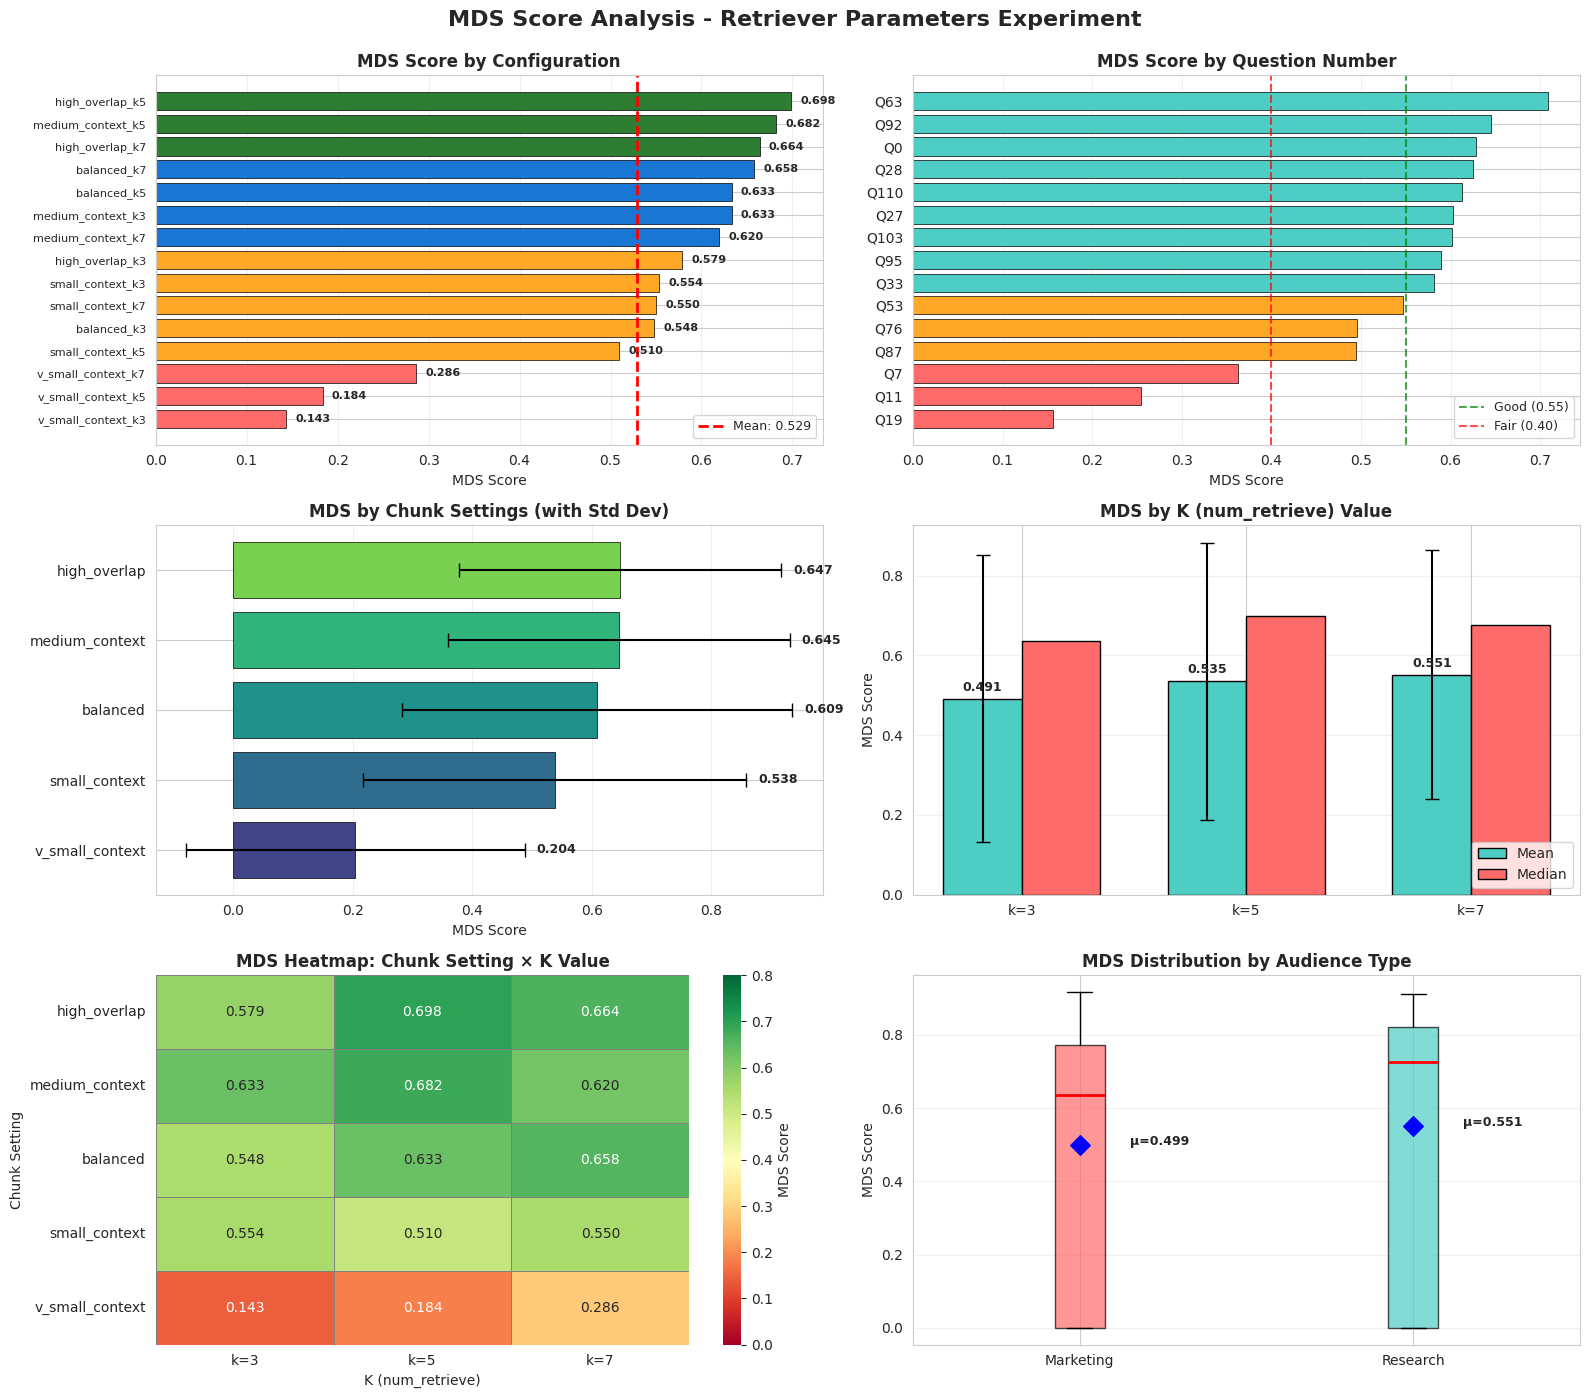

In [ ]:


# Configuration
INPUT_CSV = f'{output_folder}metric_results_retriever_mds_1206.csv'
OUTPUT_DIR = output_folder

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10


def load_data(csv_path):
    """Load the experiment data"""
    df = pd.read_csv(csv_path)
    df['full_config'] = df['config_name'] + '_k' + df['num_retrieve'].astype(str)
    print(f"✓ Loaded {len(df)} rows")
    print(f"✓ Configurations: {df['full_config'].nunique()}")
    print(f"✓ Questions: {df['question_num'].nunique()}")
    return df


def create_overview_visualization(df, output_path):
    """Create 6-panel overview visualization"""

    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle('MDS Score Analysis - Retriever Parameters Experiment',
                 fontsize=16, fontweight='bold', y=0.995)

    # ========================================================================
    # 1. MDS by Full Configuration (horizontal bar)
    # ========================================================================
    ax = axes[0, 0]

    config_mds = df.groupby('full_config')['mds'].mean().sort_values(ascending=True)
    colors = ['#2E7D32' if i >= len(config_mds)-3 else '#1976D2' if i >= len(config_mds)-7
              else '#FFA726' if i >= 3 else '#FF6B6B' for i in range(len(config_mds))]

    ax.barh(range(len(config_mds)), config_mds.values, color=colors,
            edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(config_mds)))
    ax.set_yticklabels(config_mds.index, fontsize=8)
    ax.set_title('MDS Score by Configuration', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    for i, v in enumerate(config_mds.values):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8, fontweight='bold')

    ax.axvline(x=config_mds.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {config_mds.mean():.3f}')
    ax.legend(loc='lower right', fontsize=9)

    # ========================================================================
    # 2. MDS by Question Number
    # ========================================================================
    ax = axes[0, 1]

    q_mds = df.groupby('question_num')['mds'].mean().sort_values(ascending=True)
    colors = ['#FF6B6B' if v < 0.40 else '#FFA726' if v < 0.55 else '#4ECDC4' for v in q_mds]

    ax.barh(range(len(q_mds)), q_mds.values, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(q_mds)))
    ax.set_yticklabels([f'Q{q}' for q in q_mds.index])
    ax.set_title('MDS Score by Question Number', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    ax.axvline(x=0.55, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='Good (0.55)')
    ax.axvline(x=0.40, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Fair (0.40)')
    ax.legend(loc='lower right', fontsize=9)

    # ========================================================================
    # 3. MDS by Chunk Settings
    # ========================================================================
    ax = axes[1, 0]

    chunk_mds = df.groupby('config_name')['mds'].agg(['mean', 'std']).sort_values('mean', ascending=True)

    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(chunk_mds)))

    ax.barh(range(len(chunk_mds)), chunk_mds['mean'], xerr=chunk_mds['std'],
            color=colors, edgecolor='black', linewidth=0.5, capsize=5)
    ax.set_yticks(range(len(chunk_mds)))
    ax.set_yticklabels(chunk_mds.index)
    ax.set_title('MDS by Chunk Settings (with Std Dev)', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    for i, (idx, row) in enumerate(chunk_mds.iterrows()):
        ax.text(row['mean'] + row['std'] + 0.02, i, f'{row["mean"]:.3f}',
                va='center', fontsize=9, fontweight='bold')

    # ========================================================================
    # 4. MDS by K (num_retrieve) Value
    # ========================================================================
    ax = axes[1, 1]

    k_mds = df.groupby('num_retrieve')['mds'].agg(['mean', 'std', 'median'])

    x = np.arange(len(k_mds))
    width = 0.35

    bars1 = ax.bar(x - width/2, k_mds['mean'], width, label='Mean',
                   color='#4ECDC4', edgecolor='black', yerr=k_mds['std'], capsize=5)
    bars2 = ax.bar(x + width/2, k_mds['median'], width, label='Median',
                   color='#FF6B6B', edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels([f'k={int(k)}' for k in k_mds.index])
    ax.set_title('MDS by K (num_retrieve) Value', fontweight='bold', fontsize=12)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    for bar, val in zip(bars1, k_mds['mean']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

    # ========================================================================
    # 5. Heatmap: Chunk Setting × K Value
    # ========================================================================
    ax = axes[2, 0]

    heatmap_data = df.pivot_table(values='mds', index='config_name',
                                   columns='num_retrieve', aggfunc='mean')
    heatmap_data.columns = [f'k={int(k)}' for k in heatmap_data.columns]

    # Sort by mean
    heatmap_data['mean'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values('mean', ascending=False)
    heatmap_data = heatmap_data.drop('mean', axis=1)

    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'MDS Score'}, linewidths=0.5, linecolor='gray',
                vmin=0, vmax=0.8)

    ax.set_title('MDS Heatmap: Chunk Setting × K Value', fontweight='bold', fontsize=12)
    ax.set_xlabel('K (num_retrieve)', fontsize=10)
    ax.set_ylabel('Chunk Setting', fontsize=10)

    # ========================================================================
    # 6. MDS by Audience Type (box plot)
    # ========================================================================
    ax = axes[2, 1]

    box_data = [df[df['audience_type']=='marketing']['mds'].dropna(),
                df[df['audience_type']=='research']['mds'].dropna()]

    bp = ax.boxplot(box_data, tick_labels=['Marketing', 'Research'], patch_artist=True)

    colors_box = ['#FF6B6B', '#4ECDC4']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for median in bp['medians']:
        median.set_color('red')
        median.set_linewidth(2)

    ax.set_title('MDS Distribution by Audience Type', fontweight='bold', fontsize=12)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # Add mean markers
    means = df.groupby('audience_type')['mds'].mean()
    for i, (aud, mean_val) in enumerate(means.items()):
        ax.scatter(i+1, mean_val, color='blue', s=100, zorder=5, marker='D')
        ax.text(i+1.15, mean_val, f'μ={mean_val:.3f}', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f" Saved: {output_path}")

print("\n" + "=" * 80)
print("MDS SCORE ANALYSIS - RETRIEVER PARAMETERS VISUALIZATION")
print("=" * 80)

# Load data
df = load_data(INPUT_CSV)


# Generate visualizations
print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

create_overview_visualization(df, OUTPUT_DIR + 'retriever_mds_overview.png')

##### Experiment 2: Embedding Models

Embedding Model Experiments were run using the best Retriever Configuration from Experiment 1.

PLEASE NOTE:
- Experiments were conducted in the Notebook '[Assignment_5_embedding_experiments.ipynb](https://colab.research.google.com/drive/1TrgDfTpxrUF6PQtUGKEvhsSjytjuHUcH?usp=drive_link)'.

- Results from experiment: [rag_embeddings_outputs_1206_mds.csv](https://drive.google.com/file/d/1xrrzY6dCZMDvulCQoXBqWeToItIZu0a2/view?usp=drive_link)

- Metrics from experiment: [metric_results_embeddings_mds_1206.csv](https://drive.google.com/file/d/15PV2jZcybePEhVxWEEal78oP3iyIY0Xc/view?usp=drive_link)


| Parameter | Value |
|-----------|-------|
| Chunk Size | 512 |
| Overlap | 100 |
| Num Retrieve (k) | 5 |
| Config Name | optimal |

Embedding Models Tested

| # | Model Name | Description |
|---|------------|-------------|
| 1 | multi-qa-distilbert-cos-v1 | DistilBERT tuned for QA, cosine similarity |
| 2 | all-mpnet-base-v2 | MPNet base, general purpose |
| 3 | all-MiniLM-L12-v2 | MiniLM 12-layer, lightweight |
| 4 | multi-qa-mpnet-base-dot-v1 | MPNet tuned for QA, dot product |
| 5 | all-distilroberta-v1 | DistilRoBERTa, general purpose |


Summary

- **Retriever Parameters:** chunk_size=512, overlap=100, k=5
- **Variable:** 5 embedding models
- **Total Configurations:** 5




| Metric | Value |
|--------|-------|
| **Total Rows** | 150 |
| **Embedding Models** | 5 |
| **Questions** | 15 |
| **Audience Types** | Marketing, Research |
| **Mean MDS** | 0.5844 |
| **Median MDS** | 0.7210 |
| **Zero MDS Rows** | 31 (20.7%) |

---
The **Best Embedding Model:** is `multi-qa-mpnet-base-dot-v1` with the highest overall average MDS (MDS: 0.6643). It has the fewest rows with Zero MDS score (only 2). Unlike Experiment 1, the results for the marketing audience scored better than for the research audience. The model `all-MiniLM-L12-v2` (MDS: 0.6216) was the second best with a good balance of quality. The number of rows with zero mds score has reduced to 31 from the previous experiment.

Embedding Model Rankings

| Rank | Embedding Model | MDS Mean | MDS Std | Faith | AnsRel |
|------|-----------------|----------|---------|-------|--------|
| 1 | **multi-qa-mpnet-base-dot-v1** | **0.6643** | 0.2420 | 0.647 | 0.872 |
| 2 | all-MiniLM-L12-v2 | 0.6216 | 0.2936 | 0.600 | 0.814 |
| 3 | multi-qa-distilbert-cos-v1 | 0.5772 | 0.3343 | 0.621 | 0.781 |
| 4 | all-mpnet-base-v2 | 0.5523 | 0.3578 | 0.678 | 0.716 |
| 5 | all-distilroberta-v1 | 0.5066 | 0.3489 | 0.659 | 0.691 |

---

Audience Comparison

| Audience | MDS Mean | MDS Median |
|----------|----------|------------|
| Marketing | 0.5904 | 0.6737 |
| Research | 0.5784 | 0.7571 |
| **Difference** | **-0.012** | Marketing slightly better |

---

MDS by Question and Audience

| Q# | MDS (Mkt) | MDS (Res) | Diff | Faith (Mkt) | Faith (Res) |
|-----|-----------|-----------|------|-------------|-------------|
| Q63 | 0.8052 | 0.8238 | +0.019 | 0.702 | 0.735 |
| Q27 | 0.7862 | 0.8064 | +0.020 | 0.689 | 0.777 |
| Q103 | 0.8149 | 0.7535 | -0.061 | 0.690 | 0.676 |
| Q33 | 0.7735 | 0.7528 | -0.021 | 0.742 | 0.674 |
| Q0 | 0.7652 | 0.7534 | -0.012 | 0.841 | 0.838 |
| Q92 | 0.7701 | 0.7331 | -0.037 | 0.835 | 0.710 |
| Q95 | 0.6571 | 0.6596 | +0.003 | 0.512 | 0.920 |
| Q53 | 0.6799 | 0.6299 | -0.050 | 0.507 | 0.816 |
| Q76 | 0.4718 | **0.7778** | **+0.306** | 0.463 | 0.726 |
| Q110 | 0.5952 | 0.6027 | +0.008 | 0.367 | 0.771 |
| Q87 | 0.5022 | 0.6030 | +0.101 | 0.530 | 0.682 |
| Q28 | 0.5102 | 0.3301 | **-0.180** | 0.833 | 0.723 |
| Q11 | 0.5025 | 0.2839 | **-0.219** | 0.447 | 0.727 |
| Q7 | 0.2225 | 0.0750 | -0.147 | 0.483 | 0.029 |
| Q19 | 0.0000 | 0.0910 | +0.091 | 0.080 | 0.700 |
| **AVG** | **0.5904** | **0.5784** | **-0.012** | **0.581** | **0.700** |

---

 Problematic Rows (MDS ≈ 0)

**31 rows** have zero MDS due to zero values in metrics:

| Question | Zero MDS Count | Root Cause |
|----------|----------------|------------|
| Q19 | 9 | Zero Faithfulness / Answer Relevancy |
| Q7 | 7 | Zero Answer Relevancy / Faithfulness |
| Q28 | 5 | Zero Answer Relevancy |
| Q11 | 4 | Zero Faithfulness / Answer Relevancy |

| Embedding Model | Zero MDS Count |
|-----------------|----------------|
| all-distilroberta-v1 | 9 (worst) |
| all-mpnet-base-v2 | 8 |
| multi-qa-distilbert-cos-v1 | 7 |
| all-MiniLM-L12-v2 | 5 |
| **multi-qa-mpnet-base-dot-v1** | **2 (best)** |

---

##### Visualization of results from the Embedding Experiment.

✓ Loaded 150 rows
✓ Embedding models: 5
✓ Questions: 15

GENERATING VISUALIZATIONS
Saved: /content/drive/MyDrive/MIDS_267/final_project/output/embeddings_mds_overview.png


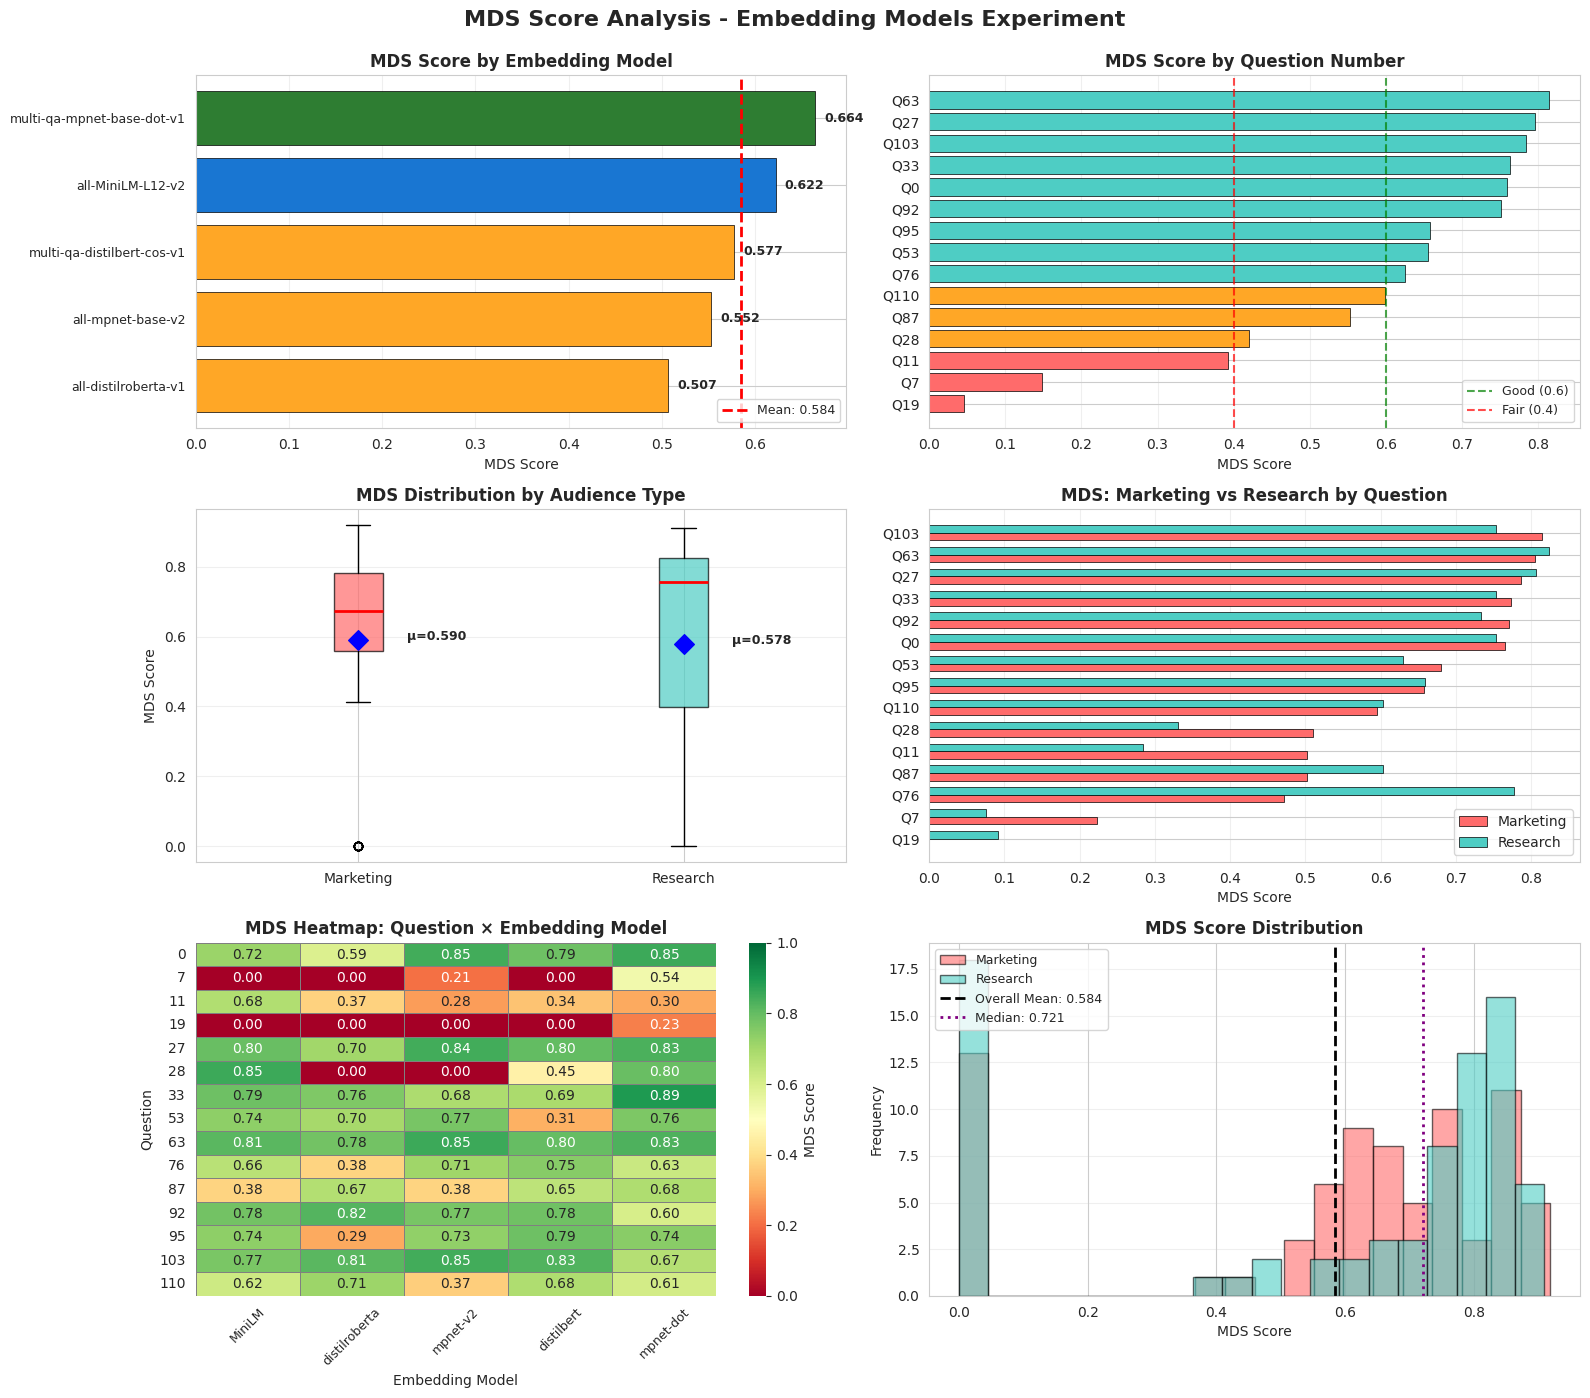

In [ ]:

# Configuration
INPUT_CSV = f'{output_folder}metric_results_embeddings_mds_1206.csv'
OUTPUT_DIR = output_folder

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10


def load_data(csv_path):
    """Load the experiment data"""
    df = pd.read_csv(csv_path)
    print(f"✓ Loaded {len(df)} rows")
    print(f"✓ Embedding models: {df['embedding_model'].nunique()}")
    print(f"✓ Questions: {df['question_num'].nunique()}")
    return df


def create_overview_visualization(df, output_path):
    """Create 6-panel overview visualization"""

    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle('MDS Score Analysis - Embedding Models Experiment',
                 fontsize=16, fontweight='bold', y=0.995)

    # ========================================================================
    # 1. MDS by Embedding Model (horizontal bar)
    # ========================================================================
    ax = axes[0, 0]

    model_mds = df.groupby('embedding_model')['mds'].mean().sort_values(ascending=True)
    colors = ['#2E7D32' if i == len(model_mds)-1 else '#1976D2' if i >= len(model_mds)-2
              else '#FFA726' for i in range(len(model_mds))]

    bars = ax.barh(range(len(model_mds)), model_mds.values, color=colors,
                   edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(model_mds)))
    ax.set_yticklabels(model_mds.index, fontsize=9)
    ax.set_title('MDS Score by Embedding Model', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    for i, v in enumerate(model_mds.values):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

    ax.axvline(x=model_mds.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {model_mds.mean():.3f}')
    ax.legend(loc='lower right', fontsize=9)

    # ========================================================================
    # 2. MDS by Question Number
    # ========================================================================
    ax = axes[0, 1]

    q_mds = df.groupby('question_num')['mds'].mean().sort_values(ascending=True)
    colors = ['#FF6B6B' if v < 0.4 else '#FFA726' if v < 0.6 else '#4ECDC4' for v in q_mds]

    ax.barh(range(len(q_mds)), q_mds.values, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(q_mds)))
    ax.set_yticklabels([f'Q{q}' for q in q_mds.index])
    ax.set_title('MDS Score by Question Number', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # Threshold lines
    ax.axvline(x=0.6, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='Good (0.6)')
    ax.axvline(x=0.4, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Fair (0.4)')
    ax.legend(loc='lower right', fontsize=9)

    # ========================================================================
    # 3. MDS by Audience Type (box plot)
    # ========================================================================
    ax = axes[1, 0]

    box_data = [df[df['audience_type']=='marketing']['mds'].dropna(),
                df[df['audience_type']=='research']['mds'].dropna()]

    bp = ax.boxplot(box_data, labels=['Marketing', 'Research'], patch_artist=True)

    colors_box = ['#FF6B6B', '#4ECDC4']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for median in bp['medians']:
        median.set_color('red')
        median.set_linewidth(2)

    ax.set_title('MDS Distribution by Audience Type', fontweight='bold', fontsize=12)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # Add mean markers
    means = df.groupby('audience_type')['mds'].mean()
    for i, (aud, mean_val) in enumerate(means.items()):
        ax.scatter(i+1, mean_val, color='blue', s=100, zorder=5, marker='D')
        ax.text(i+1.15, mean_val, f'μ={mean_val:.3f}', fontsize=9, fontweight='bold')

    # ========================================================================
    # 4. Marketing vs Research by Question
    # ========================================================================
    ax = axes[1, 1]

    pivot = df.pivot_table(values='mds', index='question_num', columns='audience_type', aggfunc='mean')
    pivot = pivot.sort_values('marketing', ascending=True)

    x = np.arange(len(pivot))
    width = 0.35

    ax.barh(x - width/2, pivot['marketing'], width, label='Marketing',
            color='#FF6B6B', edgecolor='black', linewidth=0.5)
    ax.barh(x + width/2, pivot['research'], width, label='Research',
            color='#4ECDC4', edgecolor='black', linewidth=0.5)

    ax.set_title('MDS: Marketing vs Research by Question', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.set_yticks(x)
    ax.set_yticklabels([f'Q{q}' for q in pivot.index])
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # ========================================================================
    # 5. Heatmap: Embedding Model × Question
    # ========================================================================
    ax = axes[2, 0]

    heatmap_data = df.pivot_table(values='mds', index='question_num',
                                   columns='embedding_model', aggfunc='mean')

    # Shorten model names
    short_names = {
        'multi-qa-mpnet-base-dot-v1': 'mpnet-dot',
        'all-MiniLM-L12-v2': 'MiniLM',
        'multi-qa-distilbert-cos-v1': 'distilbert',
        'all-mpnet-base-v2': 'mpnet-v2',
        'all-distilroberta-v1': 'distilroberta'
    }
    heatmap_data.columns = [short_names.get(c, c) for c in heatmap_data.columns]

    sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'MDS Score'}, linewidths=0.5, linecolor='gray',
                vmin=0, vmax=1)

    ax.set_title('MDS Heatmap: Question × Embedding Model', fontweight='bold', fontsize=12)
    ax.set_xlabel('Embedding Model', fontsize=10)
    ax.set_ylabel('Question', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)

    # ========================================================================
    # 6. MDS Distribution Histogram
    # ========================================================================
    ax = axes[2, 1]

    ax.hist(df[df['audience_type']=='marketing']['mds'], bins=20, alpha=0.6,
            label='Marketing', color='#FF6B6B', edgecolor='black')
    ax.hist(df[df['audience_type']=='research']['mds'], bins=20, alpha=0.6,
            label='Research', color='#4ECDC4', edgecolor='black')

    ax.axvline(x=df['mds'].mean(), color='black', linestyle='--', linewidth=2,
               label=f'Overall Mean: {df["mds"].mean():.3f}')
    ax.axvline(x=df['mds'].median(), color='purple', linestyle=':', linewidth=2,
               label=f'Median: {df["mds"].median():.3f}')

    ax.set_title('MDS Score Distribution', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_path}")

# Load data
df = load_data(INPUT_CSV)


# Generate visualizations
print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

create_overview_visualization(df, OUTPUT_DIR + 'embeddings_mds_overview.png')


##### Experiment 3: LLM Parameters

Experiments for LLM parameter were run using the best parameters from experiment 1 and experiment 2.

PLEASE NOTE:
- Experiments were conducted in the Notebook '[Assignment_5_llm_experiments.ipynb](https://colab.research.google.com/drive/1dOdLwnZwmXPTD59yTpVQNX5Ng1CtMy4k?usp=drive_link)'.

- Results from experiment run: [rag_llm_params_outputs.csv](https://drive.google.com/file/d/1PymHSOCesfTYM-ps5JJU3WFkMd4ZIDVN/view?usp=drive_link)

- Metrics for experiment output: [metric_results_llm_mds_1206.csv](https://drive.google.com/file/d/11A8xIq4_tNWbRGJdn6nubqoUEXf0hJyt/view?usp=drive_link)


Optimal Parameters (From Experiments 1 & 2)

| Parameter | Value | Source |
|-----------|-------|--------|
| Chunk Size | 512 | Experiment 1 (Retriever) |
| Overlap | 100 | Experiment 1 (Retriever) |
| Num Retrieve (k) | 5 | Experiment 1 (Retriever) |
| Embedding Model | multi-qa-mpnet-base-dot-v1 | Experiment 2 (Embeddings) |
| LLM | Mistral-7B-Instruct-v0.3 |  |

LLM Configurations Tested

Greedy Decoding (Most Deterministic)

| Config Name | Temp | Top-p | Do Sample | Rep. Penalty | Max Tokens |
|-------------|------|-------|-----------|--------------|------------|
| greedy_baseline | 0.0 | 1.0 | False | 1.0 | 200 |
| greedy_with_rep_penalty | 0.0 | 1.0 | False | 1.1 | 200 |

Low Temperature Sampling

| Config Name | Temp | Top-p | Do Sample | Rep. Penalty | Max Tokens |
|-------------|------|-------|-----------|--------------|------------|
| low_temp_tight_sampling | 0.1 | 0.9 | True | 1.1 | 200 |
| low_temp_moderate_sampling | 0.2 | 0.9 | True | 1.1 | 200 |

Medium Temperature (Balanced)

| Config Name | Temp | Top-p | Do Sample | Rep. Penalty | Max Tokens |
|-------------|------|-------|-----------|--------------|------------|
| medium_temp_balanced | 0.3 | 0.9 | True | 1.1 | 200 |
| medium_temp_higher_rep_pen | 0.3 | 0.9 | True | 1.2 | 200 |

Varied Top-p (Nucleus Sampling Size)

| Config Name | Temp | Top-p | Do Sample | Rep. Penalty | Max Tokens |
|-------------|------|-------|-----------|--------------|------------|
| low_temp_wide_nucleus | 0.2 | 0.95 | True | 1.1 | 200 |

Length Variations

| Config Name | Temp | Top-p | Do Sample | Rep. Penalty | Max Tokens |
|-------------|------|-------|-----------|--------------|------------|
| low_temp_concise | 0.2 | 0.9 | True | 1.1 | 300 |

---

Summary

| Parameter | Values Tested |
|-----------|---------------|
| Temperature | 0.0, 0.1, 0.2, 0.3 |
| Top-p | 0.9, 0.95, 1.0 |
| Do Sample | True, False |
| Repetition Penalty | 1.0, 1.1, 1.2 |
| Max New Tokens | 200, 300 |
| **Total Configurations** | **8** |


The **Best Config:** is the `low_temp_wide_nucleus` config with the highest average mds score (MDS: 0.7419). This configuration has a low temperature of 0.2 and to_p value of 0.95 with sampling. The temperature of 0.6 was too high and caused very low scores. In this experiment, research scores were slightly better than for marketing. For the marketing team the best config was `medium_temp_higher_rep_pen` with a mean mds score of 0.6985. We decided to go with the low_temp_wide_nucleus config as it gave research significantly scores (0.79). We considered accuracy more important for the research questions. The count of rows with zero mds score has further reduced to  22 rows.

Overall Statistics

| Metric | Value |
|--------|-------|
| **Mean MDS** | 0.6931 |
| **Median MDS** | 0.7603 |
| **Min** | 0.0000 |
| **Max** | 0.9384 |
| **Std** | 0.2458 |
| **Problematic rows (MDS ≈ 0)** | 22 |

---

Configuration Rankings (by MDS)

| Rank | Config | MDS Mean | MDS Std |
|------|--------|----------|---------|
| 1 | **low_temp_wide_nucleus** | **0.7419** | 0.1899 |
| 2 | medium_temp_higher_rep_pen | 0.7314 | 0.1691 |
| 3 | medium_temp_balanced | 0.7045 | 0.2151 |
| 4 | greedy_with_rep_penalty | 0.6850 | 0.2581 |
| 5 | low_temp_moderate_sampling | 0.6799 | 0.2538 |
| 6 | low_temp_concise | 0.6793 | 0.2647 |
| 7 | greedy_baseline | 0.6776 | 0.2888 |
| 8 | low_temp_tight_sampling | 0.6454 | 0.3087 |

---

Audience Comparison

| Audience | MDS Mean | MDS Median |
|----------|----------|------------|
| Marketing | 0.6679 | 0.7383 |
| **Research** | **0.7183** | **0.8165** |
| **Difference** | **+5.0%** | Research better |

---

MDS by Question and Audience

| Q# | MDS (Mkt) | MDS (Res) | Diff | Faith (Mkt) | Faith (Res) |
|-----|-----------|-----------|------|-------------|-------------|
| Q63 | 0.8101 | 0.8837 | +0.074 | 0.667 | 0.930 |
| Q28 | 0.8373 | 0.8561 | +0.019 | 0.840 | 0.929 |
| Q103 | 0.7923 | 0.8934 | +0.101 | 0.600 | 0.933 |
| Q0 | 0.8120 | 0.8531 | +0.041 | 0.771 | 0.923 |
| Q27 | 0.7223 | 0.8848 | +0.163 | 0.500 | 0.943 |
| Q95 | 0.7848 | 0.7781 | -0.007 | 0.767 | 0.700 |
| Q11 | 0.7111 | 0.8178 | +0.107 | 1.000 | 0.942 |
| Q33 | 0.7426 | 0.7670 | +0.024 | 0.521 | 0.918 |
| Q92 | 0.7183 | 0.7567 | +0.038 | 0.784 | 0.930 |
| Q53 | 0.8174 | 0.5867 | **-0.231** | 0.777 | 0.759 |
| Q7 | 0.7225 | 0.5990 | **-0.124** | 0.517 | 0.356 |
| Q110 | 0.5626 | 0.6507 | +0.088 | 0.375 | 0.625 |
| Q87 | 0.5025 | 0.7089 | +0.206 | 0.750 | 0.934 |
| Q76 | 0.4133 | 0.5506 | +0.137 | 0.451 | 0.414 |
| Q19 | 0.0699 | 0.1874 | +0.117 | 0.042 | 0.297 |
| **AVG** | **0.6679** | **0.7183** | **+0.050** | **0.624** | **0.769** |

---

Problematic Rows (MDS ≈ 0)

**22 rows** have MDS ≈ 0 due to **zero values** in metrics:

| Question | Count | Root Cause |
|----------|-------|------------|
| Q19 | 12 | Zero Faithfulness or Answer Relevancy |
| Q76 | 4 | Zero Answer Relevancy |
| Q110 | 2 | Zero Faithfulness |
| Q53 | 2 | Zero Answer Relevancy |
| Q33 | 1 | Zero Faithfulness |
| Q87 | 1 | Zero Faithfulness |

---


##### Visualization of results from the LLM parameter experiment.

✓ Loaded 240 rows
✓ Configurations: 8
✓ Questions: 15

GENERATING VISUALIZATIONS
 Saved: /content/drive/MyDrive/MIDS_267/final_project/output/mds_overview.png


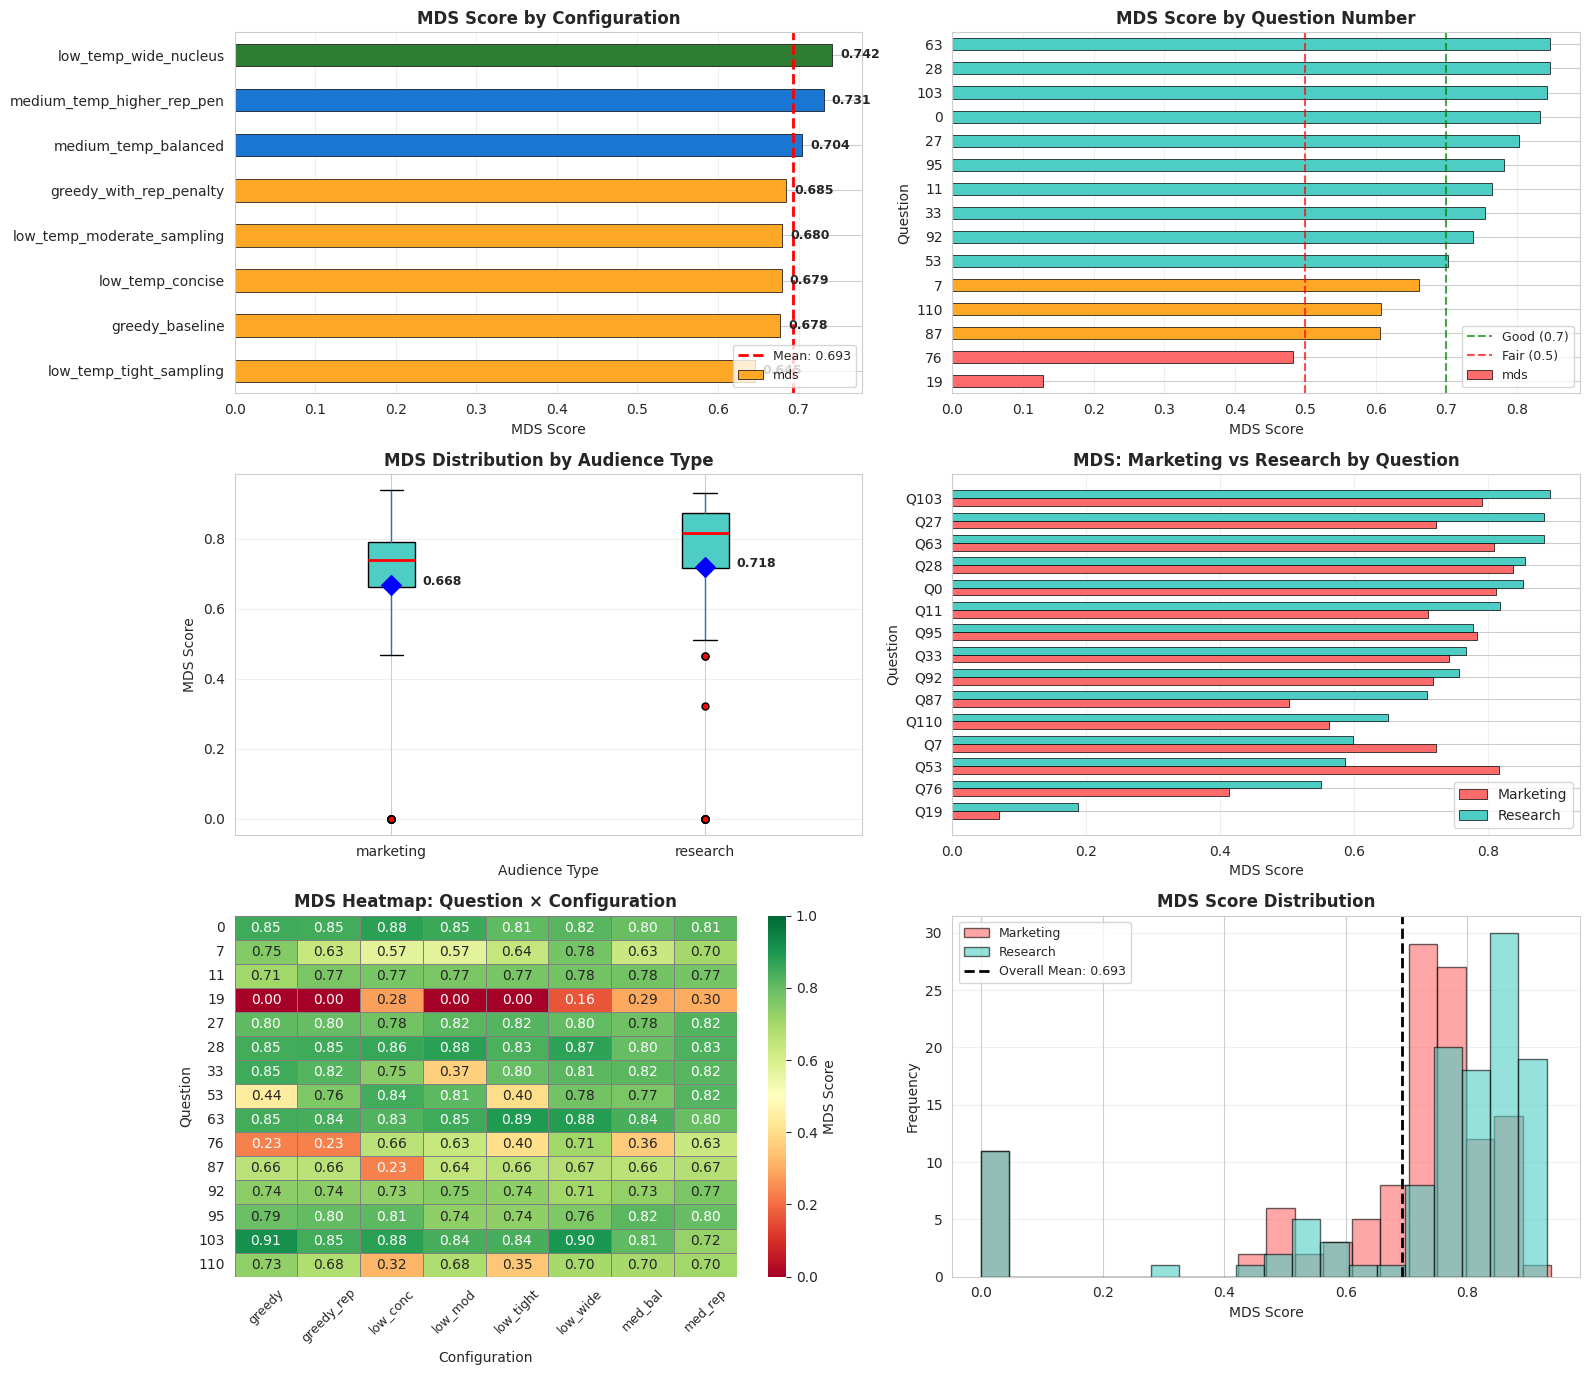

In [ ]:


# Configuration
INPUT_CSV = f'{output_folder}metric_results_llm_mds_1206.csv'
OUTPUT_DIR =output_folder

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10


def load_data(csv_path):
    """Load the experiment data"""
    df = pd.read_csv(csv_path)
    print(f"✓ Loaded {len(df)} rows")
    print(f"✓ Configurations: {df['config_name'].nunique()}")
    print(f"✓ Questions: {df['question_num'].nunique()}")
    return df


def create_overview_visualization(df, output_path):
    """Create 6-panel overview visualization"""

    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle('MDS Score Analysis - LLM Parameter Experiment',
                 fontsize=16, fontweight='bold', y=0.995)

    # ========================================================================
    # 1. MDS by Configuration (horizontal bar)
    # ========================================================================
    ax = axes[0, 0]

    config_mds = df.groupby('config_name')['mds'].mean().sort_values(ascending=True)
    colors = ['#2E7D32' if i == len(config_mds)-1 else '#1976D2' if i >= len(config_mds)-3
              else '#FFA726' for i in range(len(config_mds))]

    config_mds.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title('MDS Score by Configuration', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.set_ylabel('')
    ax.grid(True, alpha=0.3, axis='x')

    for i, v in enumerate(config_mds):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

    ax.axvline(x=config_mds.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {config_mds.mean():.3f}')
    ax.legend(loc='lower right', fontsize=9)

    # ========================================================================
    # 2. MDS by Question Number
    # ========================================================================
    ax = axes[0, 1]

    q_mds = df.groupby('question_num')['mds'].mean().sort_values(ascending=True)
    colors = ['#FF6B6B' if v < 0.5 else '#FFA726' if v < 0.7 else '#4ECDC4' for v in q_mds]

    q_mds.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title('MDS Score by Question Number', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.set_ylabel('Question', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # Threshold lines
    ax.axvline(x=0.7, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='Good (0.7)')
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Fair (0.5)')
    ax.legend(loc='lower right', fontsize=9)

    # ========================================================================
    # 3. MDS by Audience Type (box plot)
    # ========================================================================
    ax = axes[1, 0]

    df.boxplot(column='mds', by='audience_type', ax=ax,
               patch_artist=True,
               boxprops=dict(facecolor='#4ECDC4', color='black'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='red', markersize=5))

    ax.set_title('MDS Distribution by Audience Type', fontweight='bold', fontsize=12)
    ax.set_xlabel('Audience Type', fontsize=10)
    ax.set_ylabel('MDS Score', fontsize=10)
    plt.suptitle('')  # Remove automatic title
    ax.grid(True, alpha=0.3, axis='y')

    # Add mean markers
    means = df.groupby('audience_type')['mds'].mean()
    for i, (aud, mean_val) in enumerate(means.items()):
        ax.scatter(i+1, mean_val, color='blue', s=100, zorder=5, marker='D', label='Mean' if i==0 else '')
        ax.text(i+1.1, mean_val, f'{mean_val:.3f}', fontsize=9, fontweight='bold')

    # ========================================================================
    # 4. Marketing vs Research by Question
    # ========================================================================
    ax = axes[1, 1]

    pivot = df.pivot_table(values='mds', index='question_num', columns='audience_type', aggfunc='mean')
    pivot = pivot.sort_values('research', ascending=True)

    x = np.arange(len(pivot))
    width = 0.35

    bars1 = ax.barh(x - width/2, pivot['marketing'], width, label='Marketing',
                    color='#FF6B6B', edgecolor='black', linewidth=0.5)
    bars2 = ax.barh(x + width/2, pivot['research'], width, label='Research',
                    color='#4ECDC4', edgecolor='black', linewidth=0.5)

    ax.set_title('MDS: Marketing vs Research by Question', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.set_ylabel('Question', fontsize=10)
    ax.set_yticks(x)
    ax.set_yticklabels([f'Q{q}' for q in pivot.index])
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # ========================================================================
    # 5. Heatmap: Config × Question
    # ========================================================================
    ax = axes[2, 0]

    heatmap_data = df.pivot_table(values='mds', index='question_num', columns='config_name', aggfunc='mean')

    # Shorten config names for display
    short_names = {
        'greedy_baseline': 'greedy',
        'greedy_with_rep_penalty': 'greedy_rep',
        'low_temp_tight_sampling': 'low_tight',
        'low_temp_moderate_sampling': 'low_mod',
        'low_temp_wide_nucleus': 'low_wide',
        'low_temp_concise': 'low_conc',
        'medium_temp_balanced': 'med_bal',
        'medium_temp_higher_rep_pen': 'med_rep'
    }
    heatmap_data.columns = [short_names.get(c, c) for c in heatmap_data.columns]

    sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'MDS Score'}, linewidths=0.5, linecolor='gray',
                vmin=0, vmax=1)

    ax.set_title('MDS Heatmap: Question × Configuration', fontweight='bold', fontsize=12)
    ax.set_xlabel('Configuration', fontsize=10)
    ax.set_ylabel('Question', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)

    # ========================================================================
    # 6. MDS Distribution Histogram
    # ========================================================================
    ax = axes[2, 1]

    ax.hist(df[df['audience_type']=='marketing']['mds'], bins=20, alpha=0.6,
            label='Marketing', color='#FF6B6B', edgecolor='black')
    ax.hist(df[df['audience_type']=='research']['mds'], bins=20, alpha=0.6,
            label='Research', color='#4ECDC4', edgecolor='black')

    ax.axvline(x=df['mds'].mean(), color='black', linestyle='--', linewidth=2,
               label=f'Overall Mean: {df["mds"].mean():.3f}')

    ax.set_title('MDS Score Distribution', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f" Saved: {output_path}")

# Load data
df = load_data(INPUT_CSV)

# Generate visualizations
print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

create_overview_visualization(df, OUTPUT_DIR + 'mds_overview.png')

##### Experiment 4: Prompt Templates

Experiments for Prompt Templates were run using the best parameters from experiment 1 and experiment 2 and 3.

PLEASE NOTE:
- Experiments were conducted in the Notebook '[Assignment_5_prompt_experiments.ipynb](https://colab.research.google.com/drive/1oTEPyxd70SP-ZfgGimxEUAOgxShIVwIW?usp=drive_link)'.

- Results from experient run :
  - [rag_prompts_outputs.csv](https://drive.google.com/file/d/1eXrCsEL6HcAsq-IER3cQ8-eLEugYG8sO/view?usp=drive_link)
  - [rag_improved_prompts_outputs.csv](https://drive.google.com/file/d/1KRyOS6IJUGb6-J_K-5ukJvEjX1hO7QcX/view?usp=drive_link)


- Metrics for the outputs from this experiment:
  - [metric_results_prompts_mds.csv](https://drive.google.com/file/d/1ty8QheiRwobMEbbtSwC6xiCxAR5IpMqJ/view?usp=drive_link)
- [metric_results_improved_prompts_mds.csv](https://drive.google.com/file/d/1O4jFk5kWOlM0Ar7Yu-BWCDNDJiWgtTiz/view?usp=drive_link)


Optimal Parameters (From Experiments 1-3)

| Parameter | Value | Source |
|-----------|-------|--------|
| Chunk Size | 512 | Experiment 1 (Retriever) |
| Overlap | 100 | Experiment 1 (Retriever) |
| Num Retrieve (k) | 5 | Experiment 1 (Retriever) |
| Embedding Model | multi-qa-mpnet-base-dot-v1 | Experiment 2 (Embeddings) |
| LLM | Mistral-7B-Instruct-v0.3 | Fixed |
| Temperature | 0.2 | Experiment 3 (LLM) |
| Top-p | 0.95 | Experiment 3 (LLM) |
| Do Sample | True | Experiment 3 (LLM) |
| Repetition Penalty | 1.1 | Experiment 3 (LLM) |
| Max New Tokens | 200 | Experiment 3 (LLM) |

Prompt Configurations

Research Prompts (3 Variants)

| Prompt | Style | Key Features |
|--------|-------|--------------|
| research_prompt_1 | Enhanced Structure | Step-by-step instructions, explicit rules |
| research_prompt_2 | Chain-of-Thought | Think step-by-step reasoning |
| research_prompt_3 | Few-Shot Example | Includes example Q&A |

Marketing Prompts (5 Variants)

| Prompt | Style | Key Features |
|--------|-------|--------------|
| marketing_prompt_1 | Enhanced Structure | Business focus, clear instructions |
| marketing_prompt_2 | Benefit-Focused | Step-by-step reasoning |
| marketing_prompt_3 | Few-Shot Example | Includes example Q&A |
| marketing_prompt_4 | Audience Awareness | Response guidelines, constraints |
| marketing_prompt_5 | Action-Oriented | Copywriter style, conversational |



- The research prompt 1 shown below performed the best for research audience responses and the marketing prompt 5 performed best for the marketing audience.

research_prompt_1: Enhanced Structure with Reasoning

```
[INST]You are a technical assistant for a Research Engineering Team.
Answer the question using ONLY the provided context.

CONTEXT:
{context}

QUESTION:
{question}

INSTRUCTIONS:
1. First, identify the relevant information in the context
2. Then, provide a detailed technical answer (3-5 sentences) that includes:
   - Technical implementation details and specifications
   - Methodologies, algorithms, or frameworks mentioned
   - Mathematical concepts or formulas if applicable
   - Proper technical terminology

RULES:
- Use ONLY information from the CONTEXT above
- If information is insufficient, state: "Based on the available context,
  I cannot fully answer this question."
- If only partial information exists, provide what you can and note the limitations
- Be precise and avoid speculation beyond the context

ANSWER:[/INST]
```



marketing_prompt_5: Action-Oriented Marketing Style

```
[INST]You are a marketing copywriter. Transform technical context into compelling,
easy-to-understand answers for a Marketing Team.

CONTEXT:
{context}

QUESTION:
{question}

YOUR TASK:
Write a clear, engaging answer (1-2 sentences) that:
- Leads with the benefit or capability
- Uses active, confident language
- Avoids technical jargon
- Sounds natural and conversational

IMPORTANT:
- Use ONLY facts from the CONTEXT
- If you cannot answer from the context, say so clearly

ANSWER:[/INST]
```

| Metric | Value |
|--------|-------|
| Total Rows | 120 |
| Prompt Configurations | 8 (3 research + 5 marketing) |
| Questions | 15 |
| Mean MDS | 0.6785 |
| Median MDS | 0.7531 |
| Zero MDS Rows | 11 (9.2%) |

---

Prompt Configuration Rankings

| Rank | Config | Audience | MDS Mean | Faithfulness | Answer Rel. |
|------|--------|----------|----------|--------------|-------------|
| 1 | **research_1** | Research | **0.7599** | **0.889** | 0.866 |
| 2 | research_2 | Research | 0.7460 | 0.750 | 0.939 |
| 3 | research_3 | Research | 0.7039 | 0.810 | 0.901 |
| 4 | marketing_5 | Marketing | 0.6828 | 0.635 | 0.939 |
| 5 | marketing_2 | Marketing | 0.6763 | 0.638 | 0.954 |
| 6 | marketing_3 | Marketing | 0.6553 | 0.572 | 0.935 |
| 7 | marketing_4 | Marketing | 0.6467 | 0.518 | 0.954 |
| 8 | marketing_1 | Marketing | 0.5504 | 0.567 | 0.832 |

---

Audience Comparison

| Audience | MDS Mean | Faithfulness | Answer Relevancy |
|----------|----------|--------------|------------------|
| Marketing | 0.6430 | 0.586 | 0.923 |
| **Research** | **0.7373** | **0.816** | 0.902 |
| **Difference** | **+9.4%** | **+23.0%** | -2.1% |

**Key Insight:** Research prompts significantly outperform marketing prompts, primarily due to **much higher Faithfulness** (0.816 vs 0.586). Marketing prompts have slightly better Answer Relevancy but at the cost of grounding.

---

MDS by Question and Audience

| Q# | Marketing | Research | Diff | Better |
|----|-----------|----------|------|--------|
| Q63 | 0.8464 | 0.8956 | +0.049 | ≈ Similar |
| Q28 | 0.8506 | 0.8743 | +0.024 | ≈ Similar |
| Q103 | 0.8005 | 0.8532 | +0.053 | Research  |
| Q0 | 0.8234 | 0.8149 | -0.009 | ≈ Similar |
| Q27 | 0.6430 | 0.8535 | **+0.211** | Research |
| Q33 | 0.6428 | 0.8340 | **+0.191** | Research |
| Q11 | 0.5260 | 0.8081 | **+0.282** | Research  |
| Q95 | 0.6909 | 0.7805 | +0.090 | Research |
| Q87 | 0.6569 | 0.7947 | +0.138 | Research  |
| Q110 | 0.6248 | 0.7733 | +0.149 | Research  |
| Q7 | 0.5856 | 0.7505 | +0.165 | Research  |
| Q53 | 0.5737 | 0.5380 | -0.036 | ≈ Similar |
| Q76 | 0.7069 | 0.5536 | **-0.153** | Marketing |
| Q92 | 0.7454 | 0.4839 | **-0.262** | Marketing  |
| Q19 | 0.0000 | 0.4777 | +0.478 | Research |
| **AVG** | **0.6478** | **0.7391** | **+0.091** | **Research** |

---

Problematic Rows (MDS ≈ 0)

**11 rows** have zero MDS:

| Question | Zero Count | Root Cause |
|----------|------------|------------|
| Q19 | 6 | Zero Faithfulness |
| Q53 | 2 | Zero Answer Relevancy |
| Q11 | 1 | Zero Answer Relevancy |
| Q76 | 1 | Zero Faithfulness |
| Q92 | 1 | Zero Answer Relevancy |



Key Insights so far:

Faithfulness is the key differentiator:

Research avg: 0.816
Marketing avg: 0.586

Marketing prompts have high Answer Relevancy but low Faithfulness which increases the risk of hallucination. The marketing prompt needs stronger grounding instructions.

Best prompts:

Research: research_1 (MDS: 0.7599, Faith: 0.889)
Marketing: marketing_5 (MDS: 0.6828, Faith: 0.635)


6 out of 8 prompts fail (MDS=0)
Root cause: Zero Faithfulness


For the reasons mentioned above, we further enhanced the prompts and ran some more experiments. The best performance was achieved for the few shot prompts. We used two of the validation question which achieved a very mds score as the few shot example. The prompt templates are shown below. For Research audience, we used Q48 which achieved: MDS=0.8967, Faithfulness=1.0, Answer Relevancy=0.9922. For marketing audience, we used Q33 which achieved MDS=0.9138, Faithfulness=1.0, Answer Relevancy=0.9939.


- RAG Prompts with Real Few-Shot Examples



research_prompt_48 = """[INST]You are a technical assistant for a Research Engineering Team. Answer questions using ONLY the provided context.

EXAMPLE:
Context: 'stration on a 1-7 Likert scale, and computed an average "demonstration score" for each labeler.
4. Self-assessed ability to identify sensitive speech for different groups. We wanted to select a team of labelers that had collectively were able to identify sensitive content in a broad range of areas. For legal reasons, we can't hire contractors based on demographic criteria. Thus, we had labelers answer the question: "For what topics or cultural groups are you comfortable identifying sensitive speech?" and used this as part of our selection process.

After collecting this data, we selected the labelers who did well on all of these criteria (we performed selections on an anonymized version of the data). Since the fourth criteria is subjective, we ultimately chose labelers subjectively according to these criteria, though we had soft cutoffs at 75% agreement on sensitive speech flagging and comparisons, and a 6/7 demonstration score.

More specifically, from an initial pool of labeler candidates, we selected our training labelers according to the following criteria:
1. Agreement on sensitive speech flagging. We created a dataset of prompts and completions, where some of prompts or completions were sensitive (i.e. anything that could elicit strong negative feelings, whether by being toxic, sexual, violent, judgemental, political, etc.).'

Question: "What criteria were used to select labelers to ensure they can effectively detect and rate sensitive content?"

Answer: "The criteria used to select labelers to effectively detect and rate sensitive content included agreement on sensitive speech flagging, agreement on rankings of model completions, and a sensitive demonstration writing test. Labelers were selected based on their performance in these tests, with soft cutoffs at 75% agreement on sensitive speech flagging and comparisons, and a 6/7 demonstration score. The sensitive speech flagging was determined by creating a dataset of prompts and completions, where some of them were sensitive, and measuring agreement between the researchers' labels and the labelers'. The ranking of model completions was done by having labelers rank the completions by overall quality and measuring their agreement with researcher labels. The sensitive demonstration writing test involved rating each demonstration on a 1-7 Likert scale and computing an average demonstration score for each labeler."

NOW ANSWER THIS:

CONTEXT:
{context}

QUESTION:
{question}

Provide a detailed technical answer (3-5 sentences) including implementation details, methodologies, and technical terminology. Use ONLY information from the context above. If the context does not contain relevant information, state: "The provided context does not contain sufficient information about [topic]."

ANSWER:[/INST]"""



- MARKETING PROMPT - Q33 FEW-SHOT EXAMPLE


marketing_prompt_q33 = """[INST]You are a marketing assistant who translates technical information into business-friendly language. Answer questions using ONLY the provided context.

EXAMPLE:
Context: 'we usually have to impose additional identifiability constraints to achieve any guarantees on the MLE estimates from Eq. 2 [4]. The second lemma states that all reward functions from the same class yield the same optimal policy, hence for our final objective, we are only interested in recovering an arbitrary reward function from the optimal class. We prove the following Theorem in Appendix A.6:
Theorem 1. Under mild assumptions, all reward classes consistent with the Plackett-Luce (and Bradley-Terry in particular) models can be represented with the reparameterization r(x, y) = β log π(y|x)

Specifically, we first take the logarithm of both sides of Eq. 4 and then with some algebra we obtain: r(x, y) = β log πr(y | x) πref(y | x) + β log Z(x). We can apply this reparameterization to the ground-truth reward r∗and corresponding optimal model π∗. Fortunately, the Bradley-Terry model depends only on the difference of rewards between two completions.'

Question: "What assumptions must be met in order for the reparameterization of reward functions to be applied within the context of Plackett-Luce and Bradley-Terry models?"

Answer: "The reparameterization of reward functions can be applied within the Plackett-Luce and Bradley-Terry models under mild assumptions, as long as the reward classes are consistent with these models."

NOW ANSWER THIS:

CONTEXT:
{context}

QUESTION:
{question}

Provide a clear, benefit-focused answer (1-2 sentences) using simple language. Focus on what it does and why it matters. Use ONLY information from the context above. If the context does not contain relevant information, state: "The available information does not cover this topic."

ANSWER:[/INST]"""


##### Visualization of results from the Prompt Template Experiment.

✓ Loaded 120 rows
✓ Prompt configurations: 8
✓ Questions: 15

GENERATING VISUALIZATIONS
Saved: /content/drive/MyDrive/MIDS_267/final_project/output/prompts_mds_overview.png


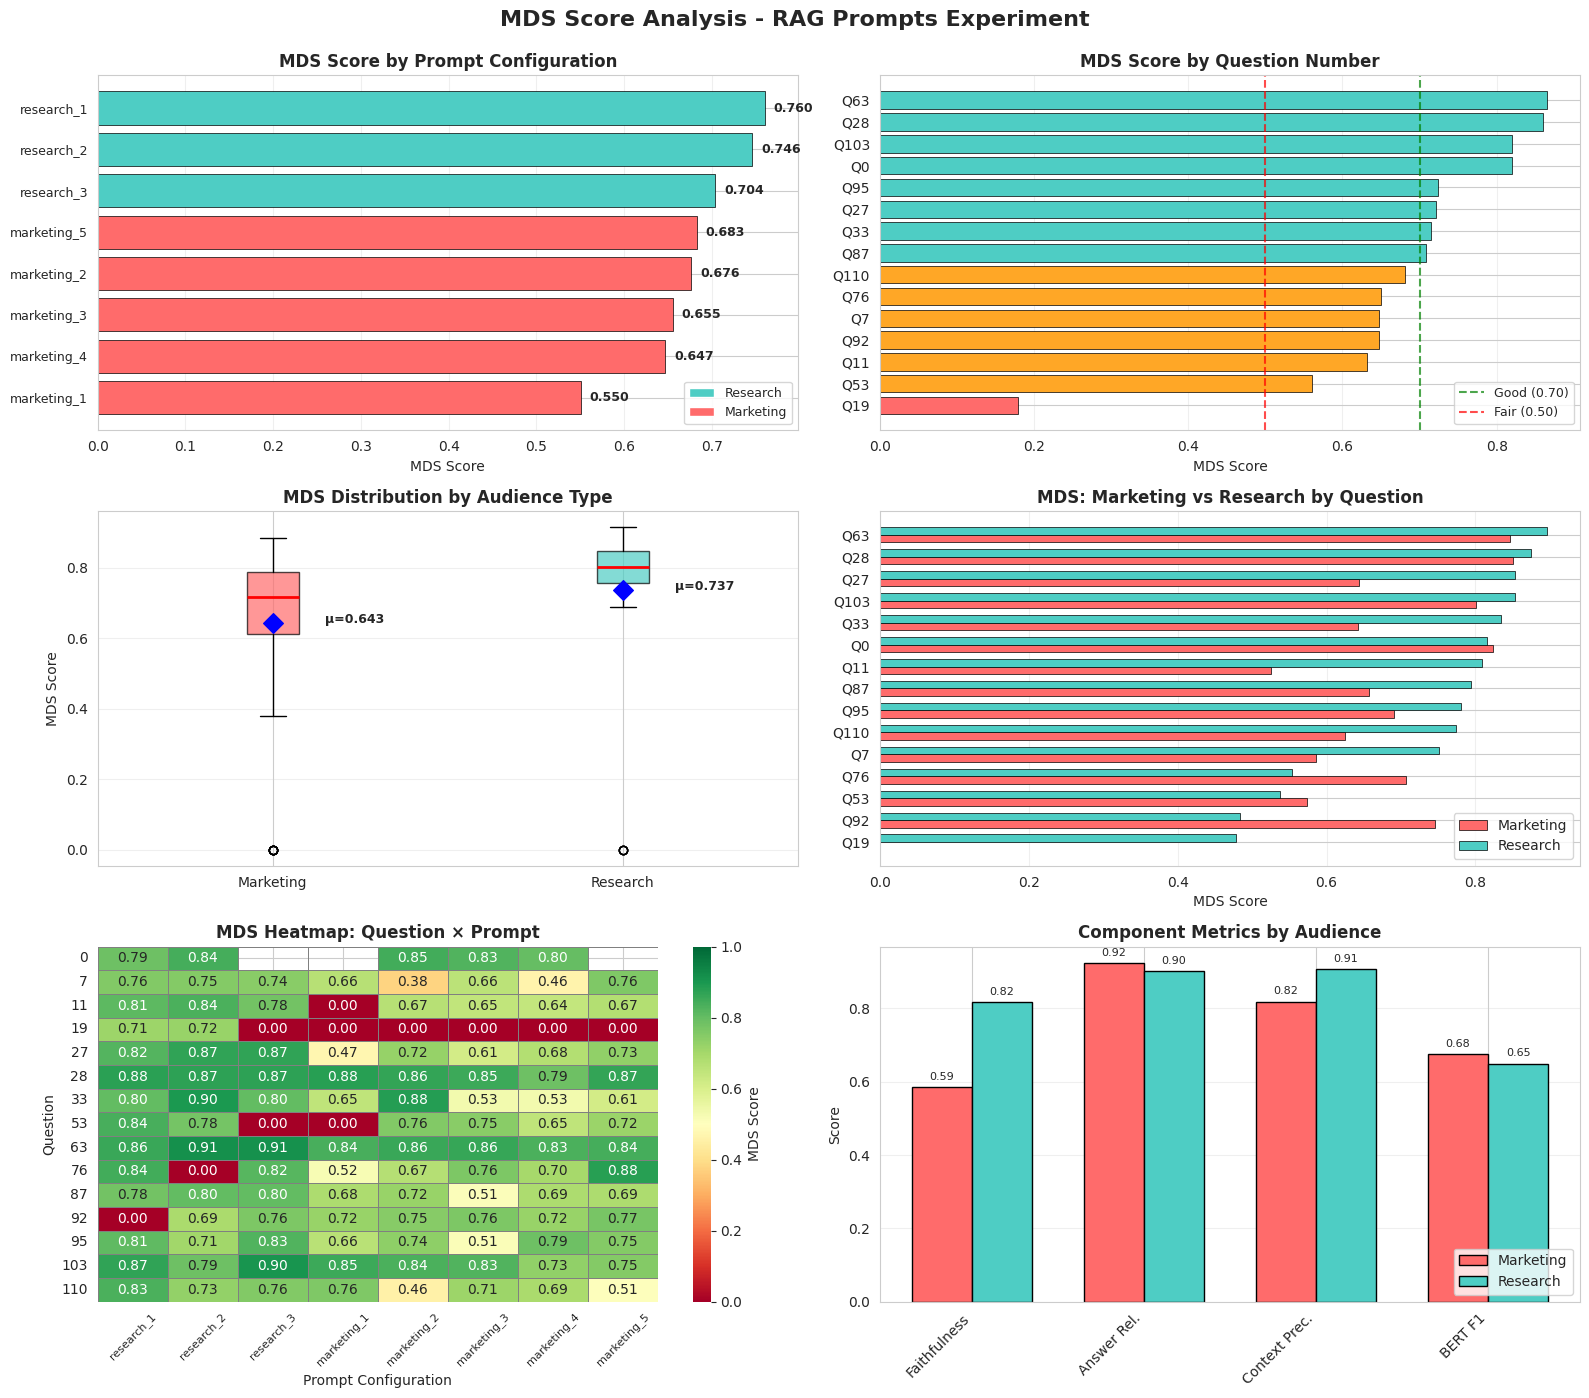

In [ ]:


# Configuration
INPUT_CSV = f'{output_folder}metric_results_prompts_mds.csv'
OUTPUT_DIR = output_folder

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10


def load_data(csv_path):
    """Load the experiment data"""
    df = pd.read_csv(csv_path)
    print(f"✓ Loaded {len(df)} rows")
    print(f"✓ Prompt configurations: {df['config_name'].nunique()}")
    print(f"✓ Questions: {df['question_num'].nunique()}")
    return df


def create_overview_visualization(df, output_path):
    """Create 6-panel overview visualization"""

    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle('MDS Score Analysis - RAG Prompts Experiment',
                 fontsize=16, fontweight='bold', y=0.995)

    # ========================================================================
    # 1. MDS by Prompt Configuration (horizontal bar)
    # ========================================================================
    ax = axes[0, 0]

    config_mds = df.groupby('config_name')['mds'].mean().sort_values(ascending=True)

    # Color by audience type
    colors = []
    for config in config_mds.index:
        audience = df[df['config_name']==config]['audience_type'].iloc[0]
        colors.append('#4ECDC4' if audience == 'research' else '#FF6B6B')

    ax.barh(range(len(config_mds)), config_mds.values, color=colors,
            edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(config_mds)))
    ax.set_yticklabels(config_mds.index, fontsize=9)
    ax.set_title('MDS Score by Prompt Configuration', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    for i, v in enumerate(config_mds.values):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#4ECDC4', label='Research'),
                       Patch(facecolor='#FF6B6B', label='Marketing')]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

    # ========================================================================
    # 2. MDS by Question Number
    # ========================================================================
    ax = axes[0, 1]

    q_mds = df.groupby('question_num')['mds'].mean().sort_values(ascending=True)
    colors = ['#FF6B6B' if v < 0.50 else '#FFA726' if v < 0.70 else '#4ECDC4' for v in q_mds]

    ax.barh(range(len(q_mds)), q_mds.values, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(q_mds)))
    ax.set_yticklabels([f'Q{q}' for q in q_mds.index])
    ax.set_title('MDS Score by Question Number', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    ax.axvline(x=0.70, color='green', linestyle='--', alpha=0.7, linewidth=1.5, label='Good (0.70)')
    ax.axvline(x=0.50, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Fair (0.50)')
    ax.legend(loc='lower right', fontsize=9)

    # ========================================================================
    # 3. MDS by Audience Type (box plot)
    # ========================================================================
    ax = axes[1, 0]

    box_data = [df[df['audience_type']=='marketing']['mds'].dropna(),
                df[df['audience_type']=='research']['mds'].dropna()]

    bp = ax.boxplot(box_data, tick_labels=['Marketing', 'Research'], patch_artist=True)

    colors_box = ['#FF6B6B', '#4ECDC4']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for median in bp['medians']:
        median.set_color('red')
        median.set_linewidth(2)

    ax.set_title('MDS Distribution by Audience Type', fontweight='bold', fontsize=12)
    ax.set_ylabel('MDS Score', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # Add mean markers
    means = df.groupby('audience_type')['mds'].mean()
    for i, (aud, mean_val) in enumerate(means.items()):
        ax.scatter(i+1, mean_val, color='blue', s=100, zorder=5, marker='D')
        ax.text(i+1.15, mean_val, f'μ={mean_val:.3f}', fontsize=9, fontweight='bold')

    # ========================================================================
    # 4. Marketing vs Research by Question
    # ========================================================================
    ax = axes[1, 1]

    pivot = df.pivot_table(values='mds', index='question_num', columns='audience_type', aggfunc='mean')
    pivot = pivot.sort_values('research', ascending=True)

    x = np.arange(len(pivot))
    width = 0.35

    ax.barh(x - width/2, pivot['marketing'], width, label='Marketing',
            color='#FF6B6B', edgecolor='black', linewidth=0.5)
    ax.barh(x + width/2, pivot['research'], width, label='Research',
            color='#4ECDC4', edgecolor='black', linewidth=0.5)

    ax.set_title('MDS: Marketing vs Research by Question', fontweight='bold', fontsize=12)
    ax.set_xlabel('MDS Score', fontsize=10)
    ax.set_yticks(x)
    ax.set_yticklabels([f'Q{q}' for q in pivot.index])
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    # ========================================================================
    # 5. Heatmap: Prompt × Question
    # ========================================================================
    ax = axes[2, 0]

    heatmap_data = df.pivot_table(values='mds', index='question_num',
                                   columns='config_name', aggfunc='mean')

    # Reorder columns: research first, then marketing
    research_cols = [c for c in heatmap_data.columns if 'research' in c]
    marketing_cols = [c for c in heatmap_data.columns if 'marketing' in c]
    heatmap_data = heatmap_data[research_cols + marketing_cols]

    sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
                cbar_kws={'label': 'MDS Score'}, linewidths=0.5, linecolor='gray',
                vmin=0, vmax=1)

    ax.set_title('MDS Heatmap: Question × Prompt', fontweight='bold', fontsize=12)
    ax.set_xlabel('Prompt Configuration', fontsize=10)
    ax.set_ylabel('Question', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    # ========================================================================
    # 6. Component Metrics Comparison
    # ========================================================================
    ax = axes[2, 1]

    metrics = ['ragas_score_faithfulness', 'ragas_score_answer_relevancy',
               'ragas_score_context_precision', 'bert_score_f1']
    metric_names = ['Faithfulness', 'Answer Rel.', 'Context Prec.', 'BERT F1']

    research_scores = df[df['audience_type']=='research'][metrics].mean()
    marketing_scores = df[df['audience_type']=='marketing'][metrics].mean()

    x = np.arange(len(metrics))
    width = 0.35

    ax.bar(x - width/2, marketing_scores, width, label='Marketing',
           color='#FF6B6B', edgecolor='black')
    ax.bar(x + width/2, research_scores, width, label='Research',
           color='#4ECDC4', edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, rotation=45, ha='right')
    ax.set_title('Component Metrics by Audience', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score', fontsize=10)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for i, (m, r) in enumerate(zip(marketing_scores, research_scores)):
        ax.text(i - width/2, m + 0.02, f'{m:.2f}', ha='center', fontsize=8)
        ax.text(i + width/2, r + 0.02, f'{r:.2f}', ha='center', fontsize=8)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_path}")

# Load data
df = load_data(INPUT_CSV)


# Generate visualizations
print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

create_overview_visualization(df, OUTPUT_DIR + 'prompts_mds_overview.png')



##### Experiment 5: Full Run with Mistral

Full run with all the validation question was done using the optimal parameters from the previous experiments.

 PLEASE NOTE:
 - Full run notebook: [Assignment_5_full_run.ipynb](https://colab.research.google.com/drive/1OQwJeKZYG-Kj4-CPwxb-Es3SEbVpqcVm?usp=drive_link)
 - Full run results:
    - [rag_full_validation_questions_outputs.csv](https://drive.google.com/file/d/1m7jGhjgytZL7HUZN8SAa6G9DIGex40WA/view?usp=drive_link)
    - [rag_few_shot_prompts_48_outputs.csv](https://drive.google.com/file/d/1tBsswuJNvCdqO0XyMkf6LaL0EWps7B6-/view?usp=drive_link)

- metrics for full run outputs:
  - [metric_results_full_validation_questions_mds.csv](https://drive.google.com/file/d/1r567J08H4sRo4yIT4vo4ngKbCvIwChsH/view?usp=drive_link)

  - [metric_results_full_val_q_prompt_48](https://drive.google.com/file/d/1Wz6tTrhMGYNezE8iL2qrgsiMMjtMvue-/view?usp=drive_link)


  
| Metric | Value |
|--------|-------|
| LLM | Mistral-7B-Instruct-v0.3 |
| Total Questions | 78 |
| Chunk Size | 512 |
| Embedding | multi-qa-mpnet-base-dot-v1 |
| Research Prompt | research_prompt_48 (Q48 few-shot) |
| Marketing Prompt | marketing_prompt_q33 (Q33 few-shot) |

---

Overall Performance Summary

| Metric | Research | Marketing | Winner |
|--------|----------|-----------|--------|
| **MDS Mean** | **0.5606** | 0.5569 | Research (+0.4%) |
| **MDS Median** | **0.7692** | 0.7015 | Research |
| Faithfulness | **0.7849** | 0.6489 | Research (+13.6%) |
| Answer Relevancy | 0.6742 | **0.7410** | Marketing (+6.7%) |
| Context Precision | **0.8710** | 0.8112 | Research |
| Context Recall | 0.7741 | **0.8433** | Marketing |
| BERTScore F1 | 0.6372 | **0.6973** | Marketing |
| Zero MDS Rows | 22 | **19** | Marketing |

Key Finding: Research Wins Overall MDS, But It's Close. Research has higher MDS mean and median but Marketing has better Answer Relevancy and Context Recall. However, Research has significantly higher Faithfulness (+13.6%)


---

Performance Distribution

Research Audience

| Category | Count | Percentage |
|----------|-------|------------|
|  Excellent (≥0.85) | 16 | 20.5% |
|  Good (0.70-0.85) | 29 | 37.2% |
|  Fair (0.50-0.70) | 7 | 9.0% |
|  Poor (0.001-0.50) | 1 | 1.3% |
|  Zero (<0.001) | 22 | 28.2% |
| NaN | 3 | 3.8% |

**57.7% of questions perform Good or Excellent**

Marketing Audience

| Category | Count | Percentage |
|----------|-------|------------|
|  Excellent (≥0.85) | 13 | 16.7% |
| Good (0.70-0.85) | 26 | 33.3% |
|  Fair (0.50-0.70) | 16 | 20.5% |
| Poor (0.001-0.50) | 2 | 2.6% |
| Zero (<0.001) | 19 | 24.4% |
| NaN | 2 | 2.6% |

**50.0% of questions perform Good or Excellent**

---

Zero MDS Analysis

Summary

| Audience | Total Zero | Zero Faithfulness | Zero Answer Rel. |
|----------|------------|-------------------|------------------|
| Research | 22 | 1 | **21 (95%)** |
| Marketing | 19 | 3 | 16 (84%) |

Critical Issue: Zero Answer Relevancy is the primary cause of MDS failures for both audiences.


Questions Failing for BOTH Audiences: **9 questions fail for both audiences** - these likely have retrieval or question formulation issues.

| Question | Issue |
|----------|-------|
| Q2 | Zero Answer Relevancy |
| Q8 | Zero Context Precision |
| Q9 | Multiple issues |
| Q12 | Zero Answer Relevancy |
| Q13 | Zero Answer Relevancy |
| Q19 | Zero Answer Relevancy |
| Q24 | Mixed issues |
| Q51 | Zero Answer Relevancy |
| Q73 | Zero Faithfulness + Zero Answer Relevancy |





 Top 10 Performing Questions

| Rank | Q# | Research | Marketing | Best | Winner |
|------|-----|----------|-----------|------|--------|
| 1 | Q78 | 0.4680 | **0.9574** | 0.9574 | Marketing |
| 2 | Q33 | 0.0000 | **0.9127** | 0.9127 | Marketing |
| 3 | Q35 | **0.9094** | 0.9074 | 0.9094 | Research |
| 4 | Q23 | 0.8383 | **0.9049** | 0.9049 | Marketing |
| 5 | Q1 | 0.8382 | **0.9044** | 0.9044 | Marketing |
| 6 | Q101 | 0.8621 | **0.9042** | 0.9042 | Marketing |
| 7 | Q61 | **0.8954** | 0.0000 | 0.8954 | Research |
| 8 | Q63 | 0.8875 | **0.8954** | 0.8954 | Marketing |
| 9 | Q38 | 0.6569 | **0.8926** | 0.8926 | Marketing |
| 10 | Q28 | **0.8926** | 0.0000 | 0.8926 | Research |


Questions with Large Audience Difference (|diff| > 0.5)

| Q# | Research | Marketing | Diff | Better For |
|----|----------|-----------|------|------------|
| Q33 | 0.0000 | 0.9127 | -0.91 | Marketing |
| Q61 | 0.8954 | 0.0000 | +0.90 | Research |
| Q28 | 0.8926 | 0.0000 | +0.89 | Research |
| Q76 | 0.8588 | 0.0000 | +0.86 | Research |
| Q52 | 0.0000 | 0.8359 | -0.84 | Marketing |
| Q0 | 0.8342 | 0.0000 | +0.83 | Research |
| Q64 | 0.8223 | 0.0000 | +0.82 | Research |
| Q86 | 0.8036 | 0.0000 | +0.80 | Research |
| Q53 | 0.0000 | 0.8000 | -0.80 | Marketing |

**Observation:** Large differences are typically caused by one audience scoring zero while the other scores well.

---
Summary:

Research Prompt show higher Faithfulness (0.78 vs 0.65)
and better Context Precision (0.87 vs 0.81). More questions with Excellent scores (16 vs 13). Marketing Prompt show higher Answer Relevancy (0.74 vs 0.67) and better Context Recall (0.84 vs 0.77) and fewer zero MDS failures (19 vs 22) and more consistent scores (lower std: 0.34 vs 0.37).

Both prompts suffer from zero Answer Relevancy issues
- This is likely due to response format not matching RAGAS expectations. Q2, Q8, Q9, Q12, Q13, Q19, Q24, Q51, Q73 fail for both audiences. These need investigation (likely retrieval or question issues)

---

Recommendations

Use Audience-Appropriate prompts, for **Research audience:** use research_prompt_48 (higher faithfulness) and for **Marketing audience:** use marketing_prompt_q33 (higher relevancy)

Investigate Problem Questions, focussing on the 9 questions that fail for both audiences. Check if retrieval returns relevant documents and verify question formulation is clear and test with different prompts and try improving retrieval with reranking, different chunking strategies like markdownsplitter for web blogs.

Address Answer Relevancy Issue by reviewing response format vs RAGAS expectations. Consider adjusting response structure and test alternative RAGAS configurations. Consider Ensemble Approach: For critical applications, run both prompts and select best response based on question type, required faithfulness level, and audience/customer needs

##### Visualization of results from the Full Validation Question Set for Mistral LLM

 MISTRAL AUDIENCE COMPARISON ANALYSIS
Loading data file...
  Total rows: 156
  Unique questions: 78

 CREATING VISUALIZATION
✓ Saved visualization: /content/drive/MyDrive/MIDS_267/final_project/output/mistral_audience_comparison.png


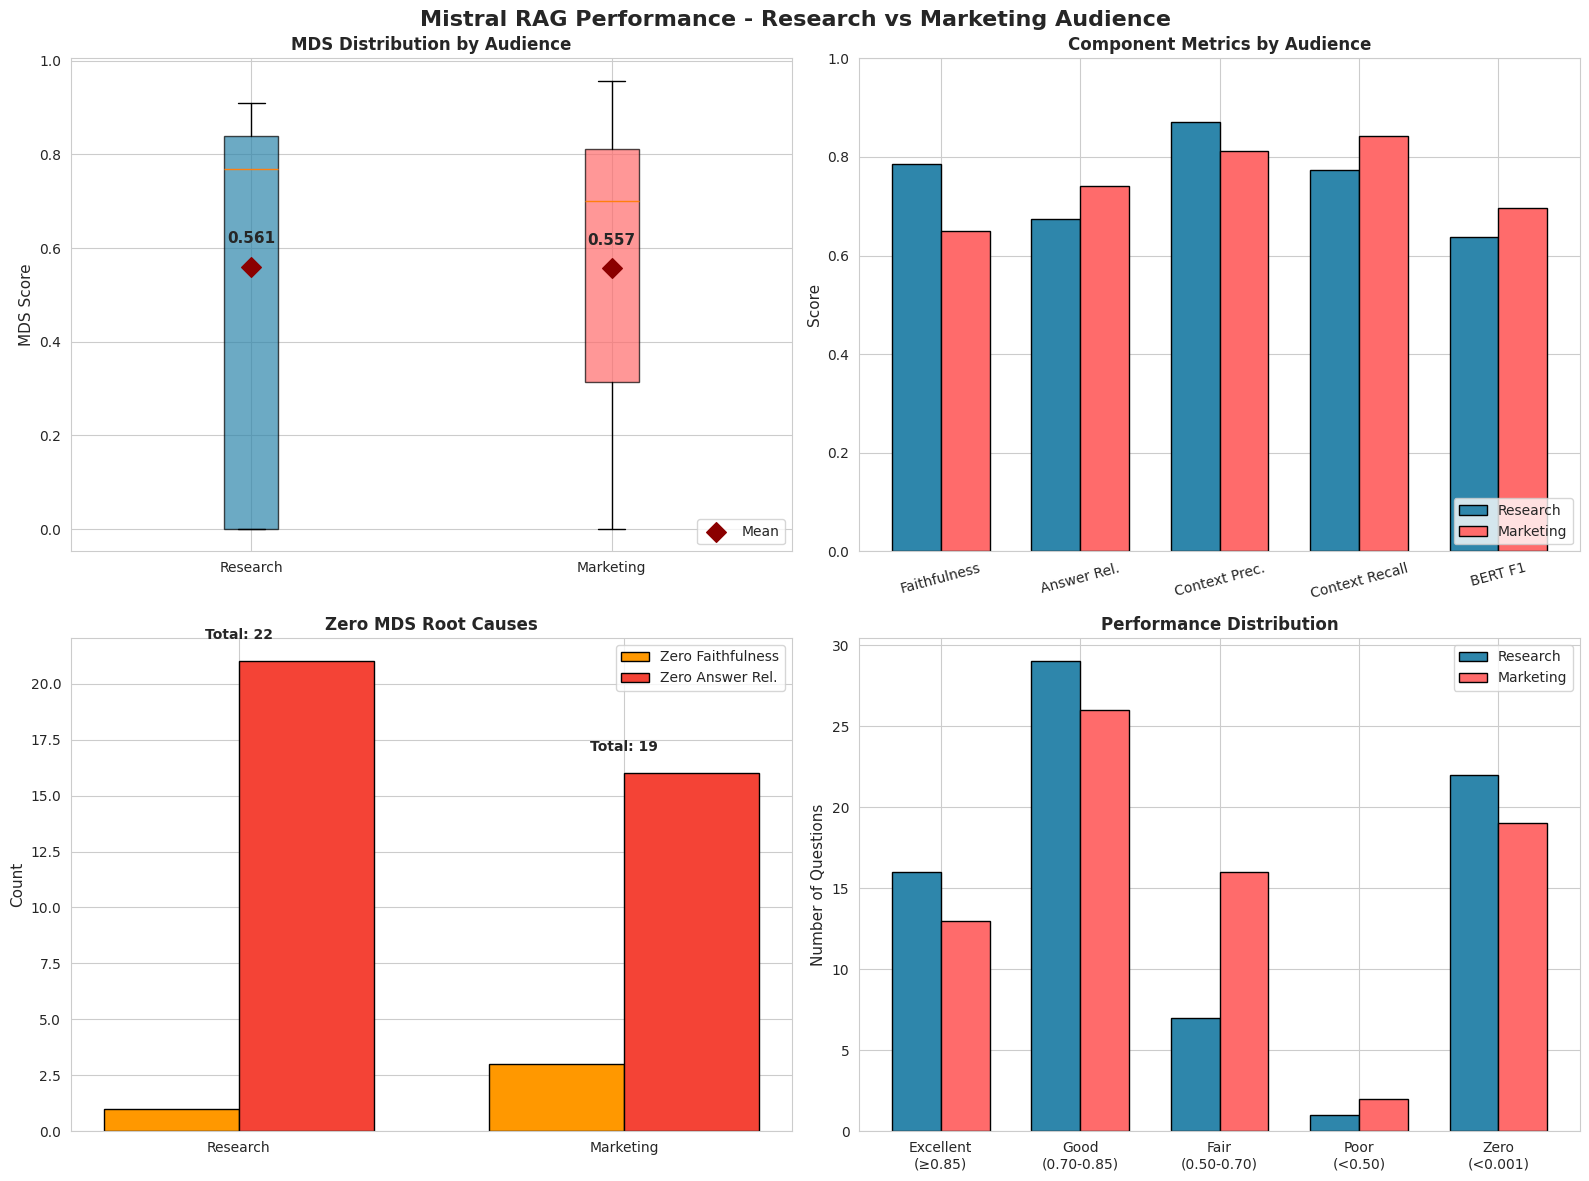

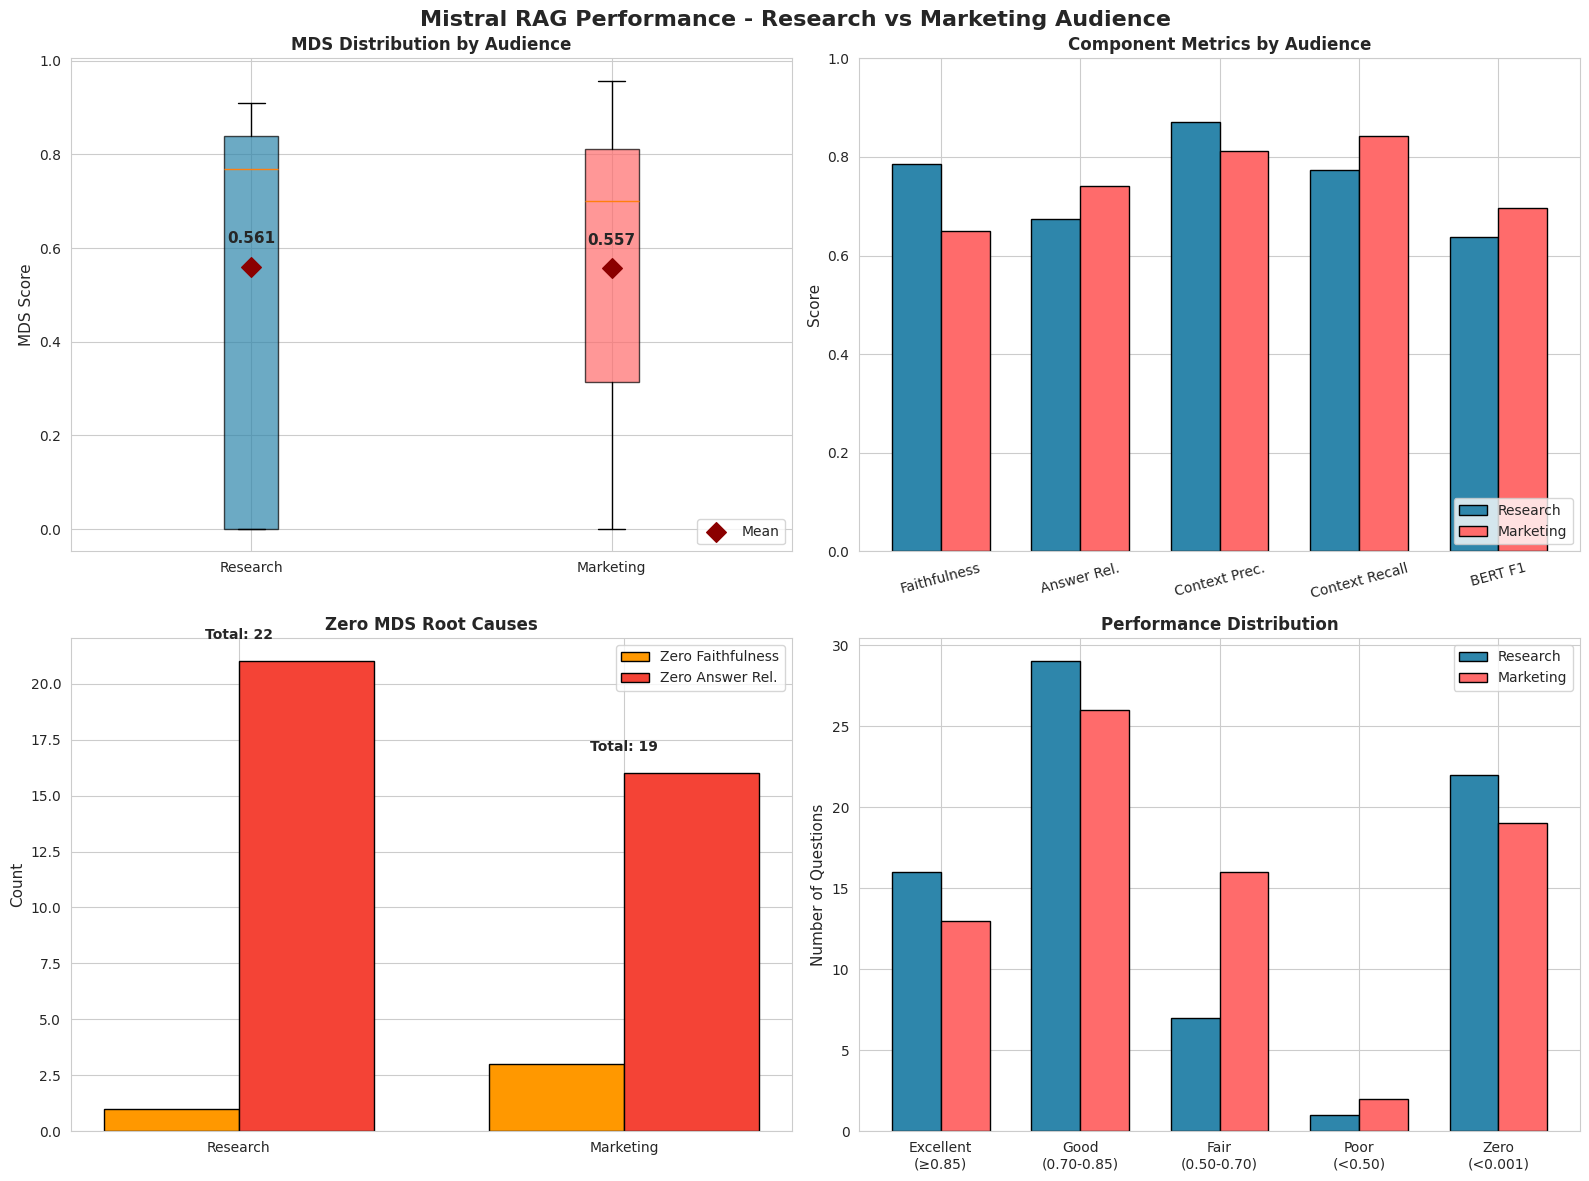

In [ ]:


# =============================================================================
# CONFIGURATION
# =============================================================================

# Input file path
MISTRAL_RESULTS_FILE = f'{output_folder}metric_results_full_val_q_mistral.csv'

# Output paths
OUTPUT_DIR = output_folder
VISUALIZATION_FILE = f'{OUTPUT_DIR}mistral_audience_comparison.png'
REPORT_FILE = f'{OUTPUT_DIR}Mistral_Audience_Comparison_Report.md'

# Audience types
RESEARCH_AUDIENCE = 'research'
MARKETING_AUDIENCE = 'marketing'


# =============================================================================
# DATA LOADING
# =============================================================================

def load_data(file_path):
    """Load Mistral results file"""
    print("Loading data file...")
    df = pd.read_csv(file_path)
    print(f"  Total rows: {len(df)}")
    print(f"  Unique questions: {df['question_num'].nunique()}")
    return df


# =============================================================================
# ANALYSIS FUNCTIONS
# =============================================================================

def get_overview(df):
    """Print overview of dataset"""
    print("\n" + "=" * 100)
    print(" DATA OVERVIEW")
    print("=" * 100)

    print(f"\nTotal rows: {len(df)}")
    print(f"Unique questions: {df['question_num'].nunique()}")
    print(f"Question range: {df['question_num'].min()} to {df['question_num'].max()}")
    print(f"Audience types: {list(df['audience_type'].unique())}")
    print(f"Config names: {list(df['config_name'].unique())}")
    print(f"LLM: {df['llm_name'].iloc[0]}")
    print(f"Chunk size: {df['chunksize'].iloc[0]}")
    print(f"Embedding: {df['embedding_model'].iloc[0]}")

    print("\n### ROWS BY CONFIG:")
    for config in df['config_name'].unique():
        cfg_data = df[df['config_name'] == config]
        audience = cfg_data['audience_type'].iloc[0]
        count = len(cfg_data)
        print(f"  {config} ({audience}): {count} rows")

    # MDS distribution
    print("\n### MDS SCORE DISTRIBUTION:")
    nan_mds = df['mds'].isna().sum()
    df_valid = df.dropna(subset=['mds'])
    zero_mds = len(df[df['mds'] < 0.001])

    print(f"  NaN MDS values: {nan_mds} ({nan_mds/len(df)*100:.1f}%)")
    print(f"  Zero MDS rows: {zero_mds} ({zero_mds/len(df)*100:.1f}%)")
    print(f"  Valid MDS rows: {len(df_valid)}")

    if len(df_valid) > 0:
        print(f"\n  Overall Statistics:")
        print(f"    Mean:   {df_valid['mds'].mean():.4f}")
        print(f"    Std:    {df_valid['mds'].std():.4f}")
        print(f"    Min:    {df_valid['mds'].min():.4f}")
        print(f"    Max:    {df_valid['mds'].max():.4f}")
        print(f"    Median: {df_valid['mds'].median():.4f}")


def compare_by_audience(df):
    """Compare metrics between research and marketing audiences"""
    print("\n" + "=" * 100)
    print("COMPARISON BY AUDIENCE TYPE")
    print("=" * 100)

    research = df[df['audience_type'] == RESEARCH_AUDIENCE]
    marketing = df[df['audience_type'] == MARKETING_AUDIENCE]

    metrics = [
        ('MDS Mean', 'mds', 'mean'),
        ('MDS Median', 'mds', 'median'),
        ('MDS Std', 'mds', 'std'),
        ('Faithfulness', 'ragas_score_faithfulness', 'mean'),
        ('Answer Relevancy', 'ragas_score_answer_relevancy', 'mean'),
        ('Context Precision', 'ragas_score_context_precision', 'mean'),
        ('Context Recall', 'ragas_score_context_recall', 'mean'),
        ('BERTScore F1', 'bert_score_f1', 'mean'),
    ]

    print(f"\n{'Metric':<30} {'Research':<15} {'Marketing':<15} {'Diff':<12} {'Winner'}")
    print("-" * 85)

    results = {}
    for label, col, agg in metrics:
        if agg == 'mean':
            r_val = research[col].mean()
            m_val = marketing[col].mean()
        elif agg == 'median':
            r_val = research[col].median()
            m_val = marketing[col].median()
        else:
            r_val = research[col].std()
            m_val = marketing[col].std()

        diff = m_val - r_val

        # For std, lower is better
        if 'Std' in label:
            winner = "Marketing" if m_val < r_val else "Research" if r_val < m_val else "Tie"
        else:
            winner = "Marketing" if m_val > r_val else "Research" if r_val > m_val else "Tie"

        results[label] = {
            'research': r_val,
            'marketing': m_val,
            'diff': diff,
            'winner': winner
        }

        r_str = f"{r_val:.4f}" if not pd.isna(r_val) else "NaN"
        m_str = f"{m_val:.4f}" if not pd.isna(m_val) else "NaN"
        print(f"{label:<30} {r_str:<15} {m_str:<15} {diff:+.4f}      {winner}")

    # Zero/NaN MDS
    r_zero = len(research[research['mds'] < 0.001])
    m_zero = len(marketing[marketing['mds'] < 0.001])
    r_nan = research['mds'].isna().sum()
    m_nan = marketing['mds'].isna().sum()

    print(f"\n{'Zero MDS Rows':<30} {r_zero:<15} {m_zero:<15} {m_zero - r_zero:+}           {'Research' if r_zero < m_zero else 'Marketing'}")
    print(f"{'NaN MDS Rows':<30} {r_nan:<15} {m_nan:<15}")

    results['zero_mds'] = {'research': r_zero, 'marketing': m_zero}
    results['nan_mds'] = {'research': r_nan, 'marketing': m_nan}

    return results, research, marketing


def get_performance_distribution(df):
    """Get performance distribution by audience"""
    print("\n" + "=" * 100)
    print(" MDS SCORE DISTRIBUTION BY AUDIENCE")
    print("=" * 100)

    distribution = {}

    for audience in [RESEARCH_AUDIENCE, MARKETING_AUDIENCE]:
        data = df[df['audience_type'] == audience]
        valid = data.dropna(subset=['mds'])
        total = len(data)

        dist = {
            'excellent': len(valid[valid['mds'] >= 0.85]),
            'good': len(valid[(valid['mds'] >= 0.70) & (valid['mds'] < 0.85)]),
            'fair': len(valid[(valid['mds'] >= 0.50) & (valid['mds'] < 0.70)]),
            'poor': len(valid[(valid['mds'] >= 0.001) & (valid['mds'] < 0.50)]),
            'zero': len(data[data['mds'] < 0.001]),
            'nan': data['mds'].isna().sum()
        }

        distribution[audience] = dist

        print(f"\n### {audience.upper()}:")
        print(f"   Excellent (≥0.85): {dist['excellent']} ({dist['excellent']/total*100:.1f}%)")
        print(f"   Good (0.70-0.85):   {dist['good']} ({dist['good']/total*100:.1f}%)")
        print(f"   Fair (0.50-0.70):   {dist['fair']} ({dist['fair']/total*100:.1f}%)")
        print(f"   Poor (0.001-0.50):  {dist['poor']} ({dist['poor']/total*100:.1f}%)")
        print(f"   Zero (<0.001):      {dist['zero']} ({dist['zero']/total*100:.1f}%)")
        print(f"   NaN:                {dist['nan']} ({dist['nan']/total*100:.1f}%)")

    return distribution


def analyze_zero_mds(df):
    """Analyze zero MDS cases and their causes"""
    print("\n" + "=" * 100)
    print(" ZERO MDS ANALYSIS")
    print("=" * 100)

    zero_mds = df[df['mds'] < 0.001]
    print(f"\nTotal Zero MDS rows: {len(zero_mds)} out of {len(df)} ({len(zero_mds)/len(df)*100:.1f}%)")

    analysis = {}

    print("\n### BY AUDIENCE:")
    for audience in df['audience_type'].unique():
        aud_zero = zero_mds[zero_mds['audience_type'] == audience]
        zero_faith = len(aud_zero[aud_zero['ragas_score_faithfulness'] < 0.01])
        zero_ans = len(aud_zero[aud_zero['ragas_score_answer_relevancy'] < 0.01])

        analysis[audience] = {
            'total': len(aud_zero),
            'zero_faith': zero_faith,
            'zero_ans_rel': zero_ans
        }

        print(f"\n{audience.upper()} ({len(aud_zero)} zero MDS rows):")
        print(f"  - Zero Faithfulness: {zero_faith}")
        print(f"  - Zero Answer Relevancy: {zero_ans}")

    # Detailed cases
    print("\n\n### DETAILED ZERO MDS CASES:")
    print(f"{'Audience':<12} {'Q#':<6} {'Faith':<8} {'AnsRel':<8} {'CtxPrec':<10} {'Cause'}")
    print("-" * 65)

    for _, row in zero_mds.iterrows():
        causes = []
        if row['ragas_score_faithfulness'] < 0.01:
            causes.append("Zero Faith")
        if row['ragas_score_answer_relevancy'] < 0.01:
            causes.append("Zero AnsRel")
        if pd.isna(row['ragas_score_context_precision']) or row['ragas_score_context_precision'] < 0.01:
            causes.append("Zero/NaN CtxPrec")

        cause = ", ".join(causes) if causes else "Unknown"
        ctx_str = f"{row['ragas_score_context_precision']:.3f}" if not pd.isna(row['ragas_score_context_precision']) else "NaN"

        print(f"{row['audience_type']:<12} Q{int(row['question_num']):<5} {row['ragas_score_faithfulness']:.3f}    {row['ragas_score_answer_relevancy']:.3f}    {ctx_str:<10} {cause}")

    # Questions failing for both audiences
    print("\n\n### QUESTIONS FAILING FOR BOTH AUDIENCES:")
    research_zero = set(zero_mds[zero_mds['audience_type'] == RESEARCH_AUDIENCE]['question_num'])
    marketing_zero = set(zero_mds[zero_mds['audience_type'] == MARKETING_AUDIENCE]['question_num'])
    both_fail = sorted(research_zero.intersection(marketing_zero))

    print(f"Questions: {both_fail}")
    print(f"Count: {len(both_fail)} questions")

    analysis['both_fail'] = both_fail

    return analysis


def question_by_question_comparison(df):
    """Compare results question by question between audiences"""
    print("\n" + "=" * 100)
    print(" QUESTION-BY-QUESTION COMPARISON")
    print("=" * 100)

    # Pivot by audience
    research = df[df['audience_type'] == RESEARCH_AUDIENCE].set_index('question_num')
    marketing = df[df['audience_type'] == MARKETING_AUDIENCE].set_index('question_num')

    comparison = pd.DataFrame({
        'research_mds': research['mds'],
        'marketing_mds': marketing['mds'],
        'research_faith': research['ragas_score_faithfulness'],
        'marketing_faith': marketing['ragas_score_faithfulness'],
        'research_ansrel': research['ragas_score_answer_relevancy'],
        'marketing_ansrel': marketing['ragas_score_answer_relevancy'],
    })

    comparison['best_mds'] = comparison[['research_mds', 'marketing_mds']].max(axis=1)
    comparison['winner'] = np.where(
        comparison['research_mds'] > comparison['marketing_mds'], 'Research',
        np.where(comparison['marketing_mds'] > comparison['research_mds'], 'Marketing', 'Tie')
    )
    comparison['diff'] = comparison['research_mds'] - comparison['marketing_mds']

    # Win counts
    print("\n### WIN COUNT BY AUDIENCE:")
    win_counts = comparison['winner'].value_counts()
    print(win_counts)

    # Top performing questions
    print("\n\n### TOP 15 QUESTIONS (By Best MDS):")
    top = comparison.nlargest(15, 'best_mds')
    print(f"{'Q#':<6} {'Research':<12} {'Marketing':<12} {'Best':<10} {'Winner'}")
    print("-" * 55)
    for q, row in top.iterrows():
        r_str = f"{row['research_mds']:.4f}" if not pd.isna(row['research_mds']) else "NaN"
        m_str = f"{row['marketing_mds']:.4f}" if not pd.isna(row['marketing_mds']) else "NaN"
        print(f"Q{q:<5} {r_str:<12} {m_str:<12} {row['best_mds']:.4f}    {row['winner']}")

    # Bottom performing questions (excluding zero)
    print("\n\n### BOTTOM 15 QUESTIONS (Excluding Zero MDS):")
    non_zero = comparison[(comparison['research_mds'] > 0.001) | (comparison['marketing_mds'] > 0.001)]
    bottom = non_zero.nsmallest(15, 'best_mds')
    print(f"{'Q#':<6} {'Research':<12} {'Marketing':<12} {'Best':<10} {'Winner'}")
    print("-" * 55)
    for q, row in bottom.iterrows():
        r_str = f"{row['research_mds']:.4f}" if not pd.isna(row['research_mds']) else "NaN"
        m_str = f"{row['marketing_mds']:.4f}" if not pd.isna(row['marketing_mds']) else "NaN"
        print(f"Q{q:<5} {r_str:<12} {m_str:<12} {row['best_mds']:.4f}    {row['winner']}")

    # Large differences
    print("\n\n### QUESTIONS WITH LARGE AUDIENCE DIFFERENCE (|diff| > 0.3):")
    large_diff = comparison[abs(comparison['diff']) > 0.3].sort_values('diff', key=abs, ascending=False)

    print(f"{'Q#':<6} {'Research':<12} {'Marketing':<12} {'Diff':<10} {'Better For'}")
    print("-" * 55)
    for q, row in large_diff.iterrows():
        r_str = f"{row['research_mds']:.4f}" if not pd.isna(row['research_mds']) else "NaN"
        m_str = f"{row['marketing_mds']:.4f}" if not pd.isna(row['marketing_mds']) else "NaN"
        better = "Research" if row['diff'] > 0 else "Marketing"
        print(f"Q{q:<5} {r_str:<12} {m_str:<12} {row['diff']:+.4f}    {better}")

    return comparison, win_counts


# =============================================================================
# VISUALIZATION
# =============================================================================

def create_visualization(df, output_file):
    """Create 4-panel comparison visualization"""
    print("\n" + "=" * 100)
    print(" CREATING VISUALIZATION")
    print("=" * 100)

    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Mistral RAG Performance - Research vs Marketing Audience', fontsize=16, fontweight='bold')

    research = df[df['audience_type'] == RESEARCH_AUDIENCE]
    marketing = df[df['audience_type'] == MARKETING_AUDIENCE]

    colors = ['#2E86AB', '#FF6B6B']

    # ========================================================================
    # Panel 1: MDS Distribution
    # ========================================================================
    ax = axes[0, 0]

    data_to_plot = [
        research['mds'].dropna(),
        marketing['mds'].dropna(),
    ]

    bp = ax.boxplot(data_to_plot, tick_labels=['Research', 'Marketing'], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    means = [d.mean() for d in data_to_plot]
    ax.scatter([1, 2], means, color='darkred', s=100, zorder=5, marker='D', label='Mean')

    for i, m in enumerate(means):
        ax.text(i+1, m + 0.05, f'{m:.3f}', ha='center', fontsize=11, fontweight='bold')

    ax.set_ylabel('MDS Score', fontsize=11)
    ax.set_title('MDS Distribution by Audience', fontweight='bold', fontsize=12)
    ax.legend(loc='lower right')

    # ========================================================================
    # Panel 2: Component Metrics
    # ========================================================================
    ax = axes[0, 1]

    metrics = ['Faithfulness', 'Answer Rel.', 'Context Prec.', 'Context Recall', 'BERT F1']
    metric_cols = ['ragas_score_faithfulness', 'ragas_score_answer_relevancy',
                   'ragas_score_context_precision', 'ragas_score_context_recall', 'bert_score_f1']

    x = np.arange(len(metrics))
    width = 0.35

    research_vals = [research[m].mean() for m in metric_cols]
    marketing_vals = [marketing[m].mean() for m in metric_cols]

    ax.bar(x - width/2, research_vals, width, label='Research', color=colors[0], edgecolor='black')
    ax.bar(x + width/2, marketing_vals, width, label='Marketing', color=colors[1], edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=15)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Component Metrics by Audience', fontweight='bold', fontsize=12)
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1)

    # ========================================================================
    # Panel 3: Zero MDS Analysis
    # ========================================================================
    ax = axes[1, 0]

    research_zero = df[(df['audience_type'] == RESEARCH_AUDIENCE) & (df['mds'] < 0.001)]
    marketing_zero = df[(df['audience_type'] == MARKETING_AUDIENCE) & (df['mds'] < 0.001)]

    r_zero_faith = len(research_zero[research_zero['ragas_score_faithfulness'] < 0.01])
    r_zero_ans = len(research_zero[research_zero['ragas_score_answer_relevancy'] < 0.01])
    m_zero_faith = len(marketing_zero[marketing_zero['ragas_score_faithfulness'] < 0.01])
    m_zero_ans = len(marketing_zero[marketing_zero['ragas_score_answer_relevancy'] < 0.01])

    x = np.arange(2)
    width = 0.35

    ax.bar(x - width/2, [r_zero_faith, m_zero_faith], width, label='Zero Faithfulness', color='#FF9800', edgecolor='black')
    ax.bar(x + width/2, [r_zero_ans, m_zero_ans], width, label='Zero Answer Rel.', color='#F44336', edgecolor='black')

    # Add total counts
    ax.text(0, max(r_zero_faith, r_zero_ans) + 1, f'Total: {len(research_zero)}', ha='center', fontsize=10, fontweight='bold')
    ax.text(1, max(m_zero_faith, m_zero_ans) + 1, f'Total: {len(marketing_zero)}', ha='center', fontsize=10, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(['Research', 'Marketing'])
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Zero MDS Root Causes', fontweight='bold', fontsize=12)
    ax.legend()

    # ========================================================================
    # Panel 4: Performance Distribution
    # ========================================================================
    ax = axes[1, 1]

    categories = ['Excellent\n(≥0.85)', 'Good\n(0.70-0.85)', 'Fair\n(0.50-0.70)', 'Poor\n(<0.50)', 'Zero\n(<0.001)']

    def get_dist(data):
        valid = data.dropna(subset=['mds'])
        return [
            len(valid[valid['mds'] >= 0.85]),
            len(valid[(valid['mds'] >= 0.70) & (valid['mds'] < 0.85)]),
            len(valid[(valid['mds'] >= 0.50) & (valid['mds'] < 0.70)]),
            len(valid[(valid['mds'] >= 0.001) & (valid['mds'] < 0.50)]),
            len(data[data['mds'] < 0.001])
        ]

    research_dist = get_dist(research)
    marketing_dist = get_dist(marketing)

    x = np.arange(len(categories))
    width = 0.35

    ax.bar(x - width/2, research_dist, width, label='Research', color=colors[0], edgecolor='black')
    ax.bar(x + width/2, marketing_dist, width, label='Marketing', color=colors[1], edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_ylabel('Number of Questions', fontsize=11)
    ax.set_title('Performance Distribution', fontweight='bold', fontsize=12)
    ax.legend()

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✓ Saved visualization: {output_file}")

    return fig

print("=" * 100)
print(" MISTRAL AUDIENCE COMPARISON ANALYSIS")
print("=" * 100)

# Load data
df = load_data(MISTRAL_RESULTS_FILE)

# Create visualization
create_visualization(df, VISUALIZATION_FILE)


##### Experiment 6: Full Run with Cohere

Full run with all the validation questions was done using optimal parameters from the previous experiments.

PLEASE NOTE:
- Full run notebook for Cohere: [Assignment_5_full_run_cohere.ipynb](https://colab.research.google.com/drive/1YNxJ2vAeXGzoQGCappZqc3eQt-pN1RD9?usp=drive_link)

- output for cohere : [rag_cohere_full_run_outputs.csv](https://drive.google.com/file/d/1e4el2unRTomdM7hLW16PKEVpk1ZAHZ4L/view?usp=drive_link)

- metrics for full run outputs:

  - [metric_results_full_val_q_cohere.csv](https://drive.google.com/file/d/1y-HKXZPGIG1ZELNQQsyTytXLrbkfk0ES/view?usp=drive_link)


  Visualizations for the full validation question run with Cohere and its comparison with the Mistral output are provided below.
  
##### LLM Comparison: Mistral vs Cohere

Our comparison found that **Mistral outperforms Cohere overall**, achieving higher MDS scores for both research and marketing audiences, better Answer Relevancy scores, and fewer zero MDS failures. Cohere's primary strength is **Faithfulness**—it produced slightly higher faithfulness scores with responses more consistently grounded in the retrieved context, indicating more conservative generation behavior. However, Cohere's significant weakness is **Answer Relevancy**, where it scored notably lower than Mistral, causing more zero MDS failures due to the harmonic mean's sensitivity to low component scores. Based on these findings, we recommend **Mistral for general RAG applications** where balanced performance across all metrics is important, while **Cohere may be preferred for use cases where faithfulness is paramount** and hallucination prevention outweighs other considerations.


Loading data files...
  Cohere: 156 rows
  Mistral: 234 rows

 CREATING VISUALIZATION
 Saved visualization: /content/drive/MyDrive/MIDS_267/final_project/output/cohere_vs_mistral_comparison.png

 ANALYSIS COMPLETE


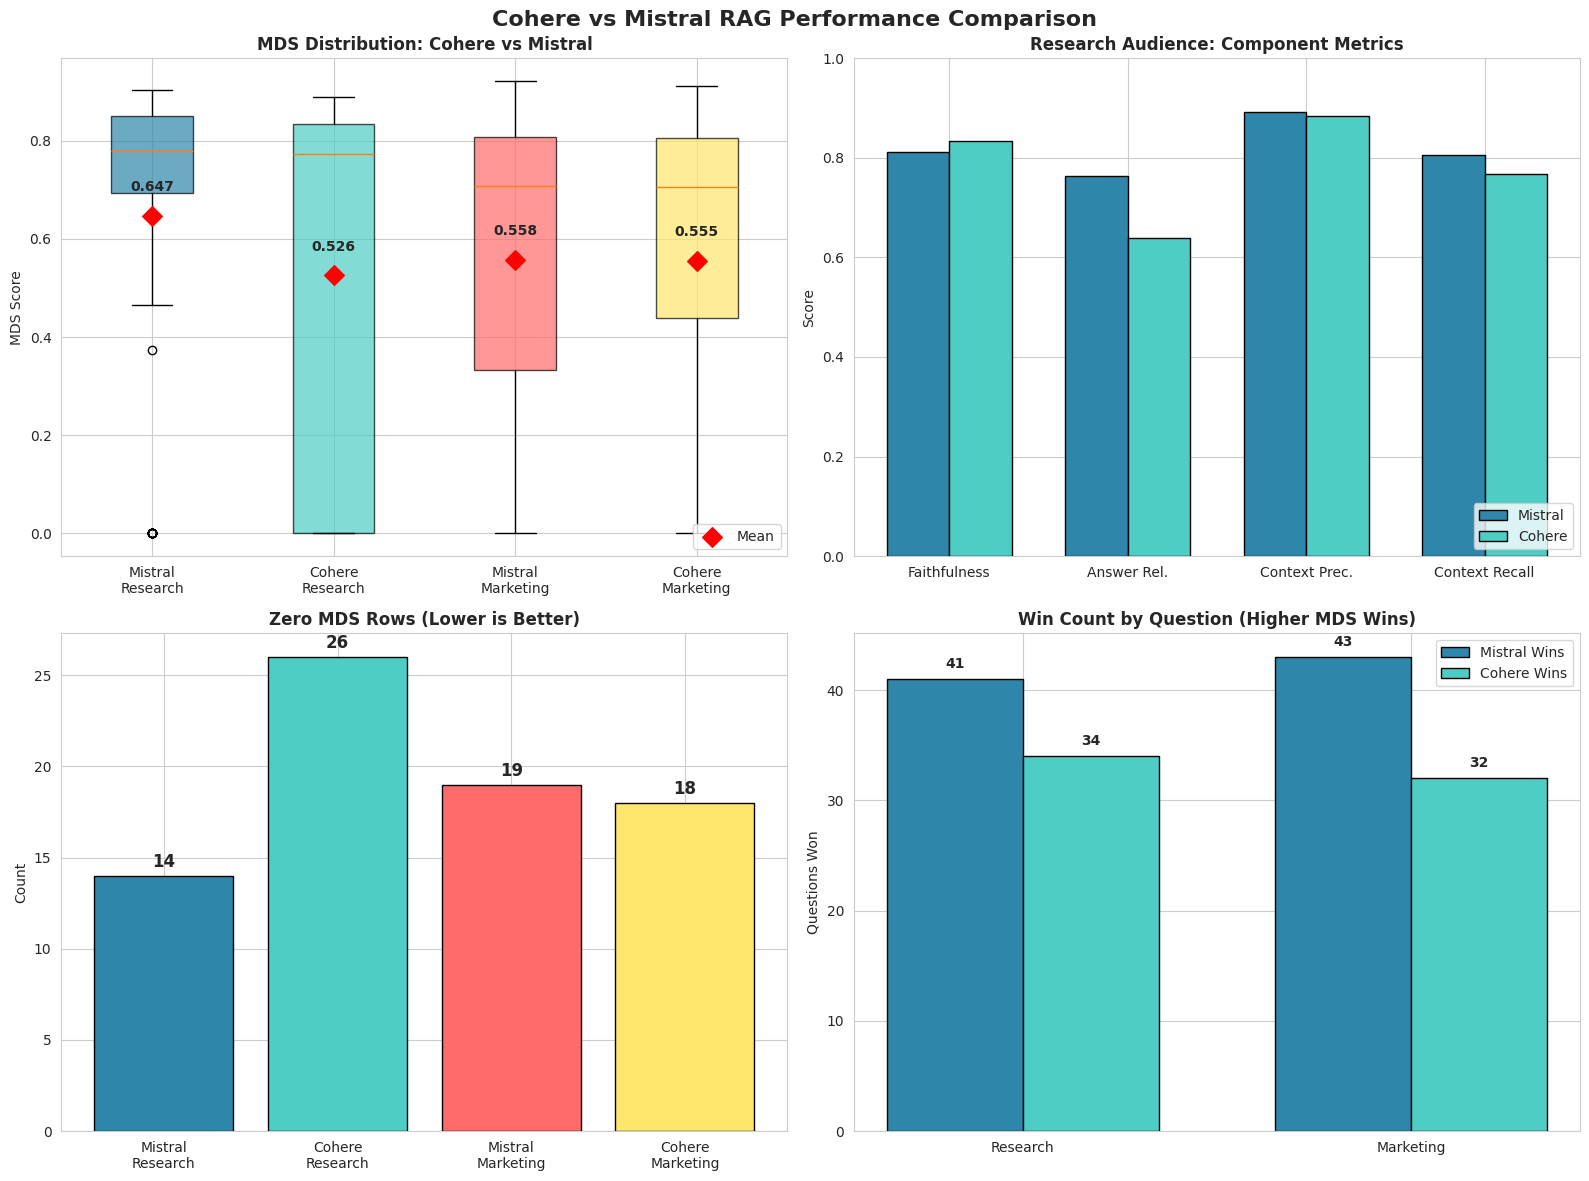

In [ ]:


# =============================================================================
# CONFIGURATION
# =============================================================================

# Input file paths
COHERE_RESULTS_FILE = f'{output_folder}metric_results_full_val_q_cohere.csv'
MISTRAL_RESULTS_FILE = f'{output_folder}metric_results_full_val_q_prompt_48.csv'

# Output paths
OUTPUT_DIR = output_folder
VISUALIZATION_FILE = f'{OUTPUT_DIR}cohere_vs_mistral_comparison.png'
REPORT_FILE = f'{OUTPUT_DIR}Cohere_vs_Mistral_Report.md'

# Config name mappings
MISTRAL_RESEARCH_CONFIG = 'full_question_research_prompt48'
MISTRAL_MARKETING_CONFIG = 'full_question_marketing_prompt48'
COHERE_RESEARCH_AUDIENCE = 'research'
COHERE_MARKETING_AUDIENCE = 'marketing'


# =============================================================================
# DATA LOADING
# =============================================================================

def load_data(cohere_file, mistral_file):
    """Load Cohere and Mistral results files"""
    print("Loading data files...")
    df_cohere = pd.read_csv(cohere_file)
    df_mistral = pd.read_csv(mistral_file)

    print(f"  Cohere: {len(df_cohere)} rows")
    print(f"  Mistral: {len(df_mistral)} rows")

    return df_cohere, df_mistral


# =============================================================================
# ANALYSIS FUNCTIONS
# =============================================================================

def get_overview(df_cohere, df_mistral):
    """Print overview of both datasets"""
    print("\n" + "=" * 100)
    print(" DATA OVERVIEW")
    print("=" * 100)

    print("\n### COHERE:")
    print(f"  Total rows: {len(df_cohere)}")
    print(f"  Unique questions: {df_cohere['question_num'].nunique()}")
    print(f"  Audience types: {list(df_cohere['audience_type'].unique())}")
    print(f"  Config names: {list(df_cohere['config_name'].unique())}")
    print(f"  LLM: {df_cohere['llm_name'].iloc[0]}")

    print("\n### MISTRAL:")
    print(f"  Total rows: {len(df_mistral)}")
    print(f"  Unique questions: {df_mistral['question_num'].nunique()}")
    print(f"  Config names: {list(df_mistral['config_name'].unique())}")
    print(f"  LLM: {df_mistral['llm_name'].iloc[0]}")


def compare_by_audience(df_cohere, df_mistral):
    """Compare metrics by audience type"""
    print("\n" + "=" * 100)
    print(" COMPARISON BY AUDIENCE TYPE")
    print("=" * 100)

    results = {}

    # Get data subsets
    cohere_research = df_cohere[df_cohere['audience_type'] == COHERE_RESEARCH_AUDIENCE]
    cohere_marketing = df_cohere[df_cohere['audience_type'] == COHERE_MARKETING_AUDIENCE]
    mistral_research = df_mistral[df_mistral['config_name'] == MISTRAL_RESEARCH_CONFIG]
    mistral_marketing = df_mistral[df_mistral['config_name'] == MISTRAL_MARKETING_CONFIG]

    configs = [
        ("Mistral Research", mistral_research),
        ("Cohere Research", cohere_research),
        ("Mistral Marketing", mistral_marketing),
        ("Cohere Marketing", cohere_marketing),
    ]

    print(f"\n{'Config':<25} {'MDS Mean':<12} {'Faith':<10} {'AnsRel':<10} {'Zero MDS'}")
    print("-" * 75)

    for name, data in configs:
        mds_mean = data['mds'].mean()
        faith = data['ragas_score_faithfulness'].mean()
        ans_rel = data['ragas_score_answer_relevancy'].mean()
        zero_count = len(data[data['mds'] < 0.001])

        results[name] = {
            'mds_mean': mds_mean,
            'faithfulness': faith,
            'answer_relevancy': ans_rel,
            'zero_mds': zero_count,
            'data': data
        }

        print(f"{name:<25} {mds_mean:.4f}       {faith:.4f}     {ans_rel:.4f}     {zero_count}")

    return results


def detailed_comparison(df_cohere, df_mistral, audience='research'):
    """Detailed metric comparison for a specific audience"""
    print(f"\n" + "=" * 100)
    print(f" DETAILED COMPARISON: {audience.upper()}")
    print("=" * 100)

    if audience == 'research':
        mistral_data = df_mistral[df_mistral['config_name'] == MISTRAL_RESEARCH_CONFIG]
        cohere_data = df_cohere[df_cohere['audience_type'] == COHERE_RESEARCH_AUDIENCE]
    else:
        mistral_data = df_mistral[df_mistral['config_name'] == MISTRAL_MARKETING_CONFIG]
        cohere_data = df_cohere[df_cohere['audience_type'] == COHERE_MARKETING_AUDIENCE]

    metrics = [
        ('MDS Mean', 'mds'),
        ('Faithfulness', 'ragas_score_faithfulness'),
        ('Answer Relevancy', 'ragas_score_answer_relevancy'),
        ('Context Precision', 'ragas_score_context_precision'),
        ('Context Recall', 'ragas_score_context_recall'),
    ]

    print(f"\n{'Metric':<25} {'Mistral':<15} {'Cohere':<15} {'Change':<15} {'Winner'}")
    print("-" * 85)

    comparison = {}
    for label, col in metrics:
        m_val = mistral_data[col].mean()
        c_val = cohere_data[col].mean()
        change = c_val - m_val
        winner = "Cohere" if c_val > m_val else "Mistral" if m_val > c_val else "Tie"

        comparison[label] = {
            'mistral': m_val,
            'cohere': c_val,
            'change': change,
            'winner': winner
        }

        print(f"{label:<25} {m_val:.4f}          {c_val:.4f}          {change:+.4f}          {winner}")

    # Zero MDS
    m_zero = len(mistral_data[mistral_data['mds'] < 0.001])
    c_zero = len(cohere_data[cohere_data['mds'] < 0.001])
    winner = "Mistral" if m_zero < c_zero else "Cohere" if c_zero < m_zero else "Tie"
    print(f"{'Zero MDS Count':<25} {m_zero:<15} {c_zero:<15} {c_zero - m_zero:+}              {winner}")

    return comparison


def question_by_question_comparison(df_cohere, df_mistral, audience='research'):
    """Compare results question by question"""
    print(f"\n" + "=" * 100)
    print(f" QUESTION-BY-QUESTION: {audience.upper()}")
    print("=" * 100)

    if audience == 'research':
        mistral_data = df_mistral[df_mistral['config_name'] == MISTRAL_RESEARCH_CONFIG]
        cohere_data = df_cohere[df_cohere['audience_type'] == COHERE_RESEARCH_AUDIENCE]
    else:
        mistral_data = df_mistral[df_mistral['config_name'] == MISTRAL_MARKETING_CONFIG]
        cohere_data = df_cohere[df_cohere['audience_type'] == COHERE_MARKETING_AUDIENCE]

    # Create comparison dataframe
    mistral_mds = mistral_data.set_index('question_num')['mds']
    cohere_mds = cohere_data.set_index('question_num')['mds']

    comparison = pd.DataFrame({
        'mistral': mistral_mds,
        'cohere': cohere_mds
    }).dropna()

    comparison['winner'] = np.where(
        comparison['cohere'] > comparison['mistral'], 'Cohere',
        np.where(comparison['mistral'] > comparison['cohere'], 'Mistral', 'Tie')
    )
    comparison['diff'] = comparison['cohere'] - comparison['mistral']

    # Print win counts
    print("\n### WIN COUNT:")
    print(comparison['winner'].value_counts())

    # Top Cohere wins
    cohere_wins = comparison[comparison['winner'] == 'Cohere'].sort_values('diff', ascending=False).head(10)
    if len(cohere_wins) > 0:
        print(f"\n### TOP 10 QUESTIONS WHERE COHERE WINS:")
        print(f"{'Q#':<8} {'Mistral':<12} {'Cohere':<12} {'Diff'}")
        for q, row in cohere_wins.iterrows():
            print(f"Q{q:<7} {row['mistral']:.4f}       {row['cohere']:.4f}       {row['diff']:+.4f}")

    # Top Mistral wins
    mistral_wins = comparison[comparison['winner'] == 'Mistral'].sort_values('diff').head(10)
    if len(mistral_wins) > 0:
        print(f"\n### TOP 10 QUESTIONS WHERE MISTRAL WINS:")
        print(f"{'Q#':<8} {'Mistral':<12} {'Cohere':<12} {'Diff'}")
        for q, row in mistral_wins.iterrows():
            print(f"Q{q:<7} {row['mistral']:.4f}       {row['cohere']:.4f}       {row['diff']:+.4f}")

    return comparison


def analyze_zero_mds(df_cohere, df_mistral):
    """Analyze zero MDS cases and their causes"""
    print("\n" + "=" * 100)
    print(" ZERO MDS ANALYSIS")
    print("=" * 100)

    # Combine both datasets with LLM identifier
    df_cohere_copy = df_cohere.copy()
    df_cohere_copy['llm'] = 'Cohere'

    df_mistral_copy = df_mistral.copy()
    df_mistral_copy['llm'] = 'Mistral'

    for llm_name, df in [('Cohere', df_cohere), ('Mistral', df_mistral)]:
        print(f"\n### {llm_name.upper()} ZERO MDS BREAKDOWN:")

        zero_mds = df[df['mds'] < 0.001]
        print(f"Total Zero MDS rows: {len(zero_mds)}")

        if len(zero_mds) > 0:
            # By config
            print("\nBy Config:")
            for config in df['config_name'].unique():
                cfg_zero = zero_mds[zero_mds['config_name'] == config]
                zero_faith = len(cfg_zero[cfg_zero['ragas_score_faithfulness'] < 0.01])
                zero_ans = len(cfg_zero[cfg_zero['ragas_score_answer_relevancy'] < 0.01])
                print(f"  {config}:")
                print(f"    Total: {len(cfg_zero)}, Zero Faith: {zero_faith}, Zero AnsRel: {zero_ans}")


# =============================================================================
# VISUALIZATION
# =============================================================================

def create_visualization(df_cohere, df_mistral, output_file):
    """Create 4-panel comparison visualization"""
    print("\n" + "=" * 100)
    print(" CREATING VISUALIZATION")
    print("=" * 100)

    sns.set_style("whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Cohere vs Mistral RAG Performance Comparison', fontsize=16, fontweight='bold')

    # Get data subsets
    mistral_r = df_mistral[df_mistral['config_name'] == MISTRAL_RESEARCH_CONFIG]
    mistral_m = df_mistral[df_mistral['config_name'] == MISTRAL_MARKETING_CONFIG]
    cohere_r = df_cohere[df_cohere['audience_type'] == COHERE_RESEARCH_AUDIENCE]
    cohere_m = df_cohere[df_cohere['audience_type'] == COHERE_MARKETING_AUDIENCE]

    colors = ['#2E86AB', '#4ECDC4', '#FF6B6B', '#FFE66D']

    # ========================================================================
    # Panel 1: MDS Distribution
    # ========================================================================
    ax = axes[0, 0]

    data_to_plot = [
        mistral_r['mds'].dropna(),
        cohere_r['mds'].dropna(),
        mistral_m['mds'].dropna(),
        cohere_m['mds'].dropna(),
    ]

    labels = ['Mistral\nResearch', 'Cohere\nResearch', 'Mistral\nMarketing', 'Cohere\nMarketing']

    bp = ax.boxplot(data_to_plot, tick_labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    means = [d.mean() for d in data_to_plot]
    ax.scatter(range(1, 5), means, color='red', s=100, zorder=5, marker='D', label='Mean')

    for i, m in enumerate(means):
        ax.text(i+1, m + 0.05, f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')

    ax.set_ylabel('MDS Score', fontsize=10)
    ax.set_title('MDS Distribution: Cohere vs Mistral', fontweight='bold', fontsize=12)
    ax.legend(loc='lower right')

    # ========================================================================
    # Panel 2: Component Metrics (Research)
    # ========================================================================
    ax = axes[0, 1]

    metrics = ['Faithfulness', 'Answer Rel.', 'Context Prec.', 'Context Recall']
    metric_cols = ['ragas_score_faithfulness', 'ragas_score_answer_relevancy',
                   'ragas_score_context_precision', 'ragas_score_context_recall']

    x = np.arange(len(metrics))
    width = 0.35

    mistral_vals = [mistral_r[m].mean() for m in metric_cols]
    cohere_vals = [cohere_r[m].mean() for m in metric_cols]

    ax.bar(x - width/2, mistral_vals, width, label='Mistral', color='#2E86AB', edgecolor='black')
    ax.bar(x + width/2, cohere_vals, width, label='Cohere', color='#4ECDC4', edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_title('Research Audience: Component Metrics', fontweight='bold', fontsize=12)
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1)

    # ========================================================================
    # Panel 3: Zero MDS Comparison
    # ========================================================================
    ax = axes[1, 0]

    configs = ['Mistral\nResearch', 'Cohere\nResearch', 'Mistral\nMarketing', 'Cohere\nMarketing']
    zero_counts = [
        len(mistral_r[mistral_r['mds'] < 0.001]),
        len(cohere_r[cohere_r['mds'] < 0.001]),
        len(mistral_m[mistral_m['mds'] < 0.001]),
        len(cohere_m[cohere_m['mds'] < 0.001]),
    ]

    bars = ax.bar(configs, zero_counts, color=colors, edgecolor='black')

    for bar, count in zip(bars, zero_counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(count), ha='center', fontsize=12, fontweight='bold')

    ax.set_ylabel('Count', fontsize=10)
    ax.set_title('Zero MDS Rows (Lower is Better)', fontweight='bold', fontsize=12)

    # ========================================================================
    # Panel 4: Win Count
    # ========================================================================
    ax = axes[1, 1]

    # Research wins
    cohere_r_mds = cohere_r.set_index('question_num')['mds']
    mistral_r_mds = mistral_r.set_index('question_num')['mds']
    research_comp = pd.DataFrame({'mistral': mistral_r_mds, 'cohere': cohere_r_mds}).dropna()

    mistral_wins_r = (research_comp['mistral'] > research_comp['cohere']).sum()
    cohere_wins_r = (research_comp['cohere'] > research_comp['mistral']).sum()

    # Marketing wins
    cohere_m_mds = cohere_m.set_index('question_num')['mds']
    mistral_m_mds = mistral_m.set_index('question_num')['mds']
    marketing_comp = pd.DataFrame({'mistral': mistral_m_mds, 'cohere': cohere_m_mds}).dropna()

    mistral_wins_m = (marketing_comp['mistral'] > marketing_comp['cohere']).sum()
    cohere_wins_m = (marketing_comp['cohere'] > marketing_comp['mistral']).sum()

    x = np.arange(2)
    width = 0.35

    ax.bar(x - width/2, [mistral_wins_r, mistral_wins_m], width, label='Mistral Wins', color='#2E86AB', edgecolor='black')
    ax.bar(x + width/2, [cohere_wins_r, cohere_wins_m], width, label='Cohere Wins', color='#4ECDC4', edgecolor='black')

    ax.set_xticks(x)
    ax.set_xticklabels(['Research', 'Marketing'])
    ax.set_ylabel('Questions Won', fontsize=10)
    ax.set_title('Win Count by Question (Higher MDS Wins)', fontweight='bold', fontsize=12)
    ax.legend()

    # Add counts on bars
    ax.text(-width/2, mistral_wins_r + 1, str(mistral_wins_r), ha='center', fontweight='bold')
    ax.text(width/2, cohere_wins_r + 1, str(cohere_wins_r), ha='center', fontweight='bold')
    ax.text(1 - width/2, mistral_wins_m + 1, str(mistral_wins_m), ha='center', fontweight='bold')
    ax.text(1 + width/2, cohere_wins_m + 1, str(cohere_wins_m), ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f" Saved visualization: {output_file}")

    return fig


# Load data
df_cohere, df_mistral = load_data(COHERE_RESULTS_FILE, MISTRAL_RESULTS_FILE)



# Create visualization
create_visualization(df_cohere, df_mistral, VISUALIZATION_FILE)



print("\n" + "=" * 100)
print(" ANALYSIS COMPLETE")
print("=" * 100)

##### Final Run with Test Questions

Final run with Test Questions

- output for Mistral: [rag_test_questions_outputs.csv](https://drive.google.com/file/d/1WwXGYVCmVydS8zYNv0NR0gLQWICkazAc/view?usp=drive_link)

- output for Cohere: [rag_final_cohere_test_run_outputs.csv](https://drive.google.com/file/d/1PJDT2hd-qlZNUdrW69tT2mFCtf8PMwYu/view?usp=sharing)

**QUESTION:**

4.1. In 8 to 15 sentences, please define and defend your approach to evaluating your RAG model. Please fill in your answer in the text block below:


*Your 4.1 answer in this text box here.  Double click to open.*


Our evaluation approach employs a Multi-Dimensional Score (MDS) that combines four complementary metrics to provide a holistic assessment of RAG system performance. We selected RAGAS (Retrieval Augmented Generation Assessment) metrics—Faithfulness, Answer Relevancy, and Context Precision—because they specifically target the unique challenges of RAG systems: grounding responses in retrieved context, producing relevant answers, and retrieving appropriate documents. We augmented these with BERTScore F1 to capture semantic similarity between generated and reference answers, providing a neural-based assessment that correlates well with human judgment.

The MDS formula uses a weighted harmonic mean, which we chose deliberately because it penalizes poor performance in any single dimension—a critical property since a RAG system that hallucinates (low faithfulness) or retrieves irrelevant context (low context precision) should not receive a high overall score regardless of other metrics. The epsilon term (10⁻⁸) ensures numerical stability when any component score approaches zero. This approach aligns with the principle that RAG systems must perform well across multiple dimensions simultaneously to be useful in production.

Our experimental methodology followed a systematic optimization process: we first tuned retriever parameters (chunk size, overlap, k), then evaluated embedding models, followed by LLM generation parameters (temperature, top-p), and finally prompt engineering with audience-specific few-shot examples. This sequential approach allowed us to isolate the impact of each component while building toward an optimal configuration. We validated our findings on a comprehensive 78-question test set spanning diverse query types to ensure generalizability.

We further strengthened our evaluation by comparing multiple LLMs (Mistral-7B and Cohere) and analyzing failure cases through zero-MDS root cause analysis, which revealed that Answer Relevancy failures were the primary driver of poor performance. This diagnostic capability demonstrates that our evaluation framework not only measures performance but also provides actionable insights for system improvement.



In [ ]:
### Q4-1 Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER


Scoring results for all the experiments can be found in the following files:
- [metric_results_retriever_mds_1206.csv](https://drive.google.com/file/d/1qyHwiKemDhuHrZ4PR6OJIQUTsbqji1oB/view?usp=drive_link)
- [metric_results_embeddings_mds_1206.csv](https://drive.google.com/file/d/15PV2jZcybePEhVxWEEal78oP3iyIY0Xc/view?usp=drive_link)
- [metric_results_llm_mds_1206.csv](https://drive.google.com/file/d/11A8xIq4_tNWbRGJdn6nubqoUEXf0hJyt/view?usp=drive_link)
- [metric_results_prompts_mds.csv](https://drive.google.com/file/d/1ty8QheiRwobMEbbtSwC6xiCxAR5IpMqJ/view?usp=drive_link)
- [metric_results_improved_prompts_mds.csv](https://drive.google.com/file/d/1O4jFk5kWOlM0Ar7Yu-BWCDNDJiWgtTiz/view?usp=drive_link)
- [metric_results_full_validation_questions_mds.csv](https://drive.google.com/file/d/1r567J08H4sRo4yIT4vo4ngKbCvIwChsH/view?usp=drive_link)

- [metric_results_full_val_q_prompt_48](https://drive.google.com/file/d/1Wz6tTrhMGYNezE8iL2qrgsiMMjtMvue-/view?usp=drive_link)

- [metric_results_full_val_q_cohere.csv](https://drive.google.com/file/d/1y-HKXZPGIG1ZELNQQsyTytXLrbkfk0ES/view?usp=drive_link)


## 5. Results

### 5.1 Model Specifications

Document the detailed specs of your choices. Also comment on how you valued the needs of the marketing team vs the needs of the researchers, in case you had to make a trade-off.

**QUESTION:**

5.1.a Provide the detailed specification of your pipelines.


*Enter your 5.1.a answer in this text box here.  Double click to open.*

In [ ]:
### Q5-1-a Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER



**QUESTION:**

5.1.b: What is the prompt you used for the engineering research group?





*Paste your 5.1.b answer in this text box here.  Double click to open.*

research_prompt_48 = """[INST]You are a technical assistant for a Research Engineering Team. Answer questions using ONLY the provided context.

EXAMPLE:
Context: 'stration on a 1-7 Likert scale, and computed an average "demonstration score" for each labeler.
4. Self-assessed ability to identify sensitive speech for different groups. We wanted to select a team of labelers that had collectively were able to identify sensitive content in a broad range of areas. For legal reasons, we can't hire contractors based on demographic criteria. Thus, we had labelers answer the question: "For what topics or cultural groups are you comfortable identifying sensitive speech?" and used this as part of our selection process.

After collecting this data, we selected the labelers who did well on all of these criteria (we performed selections on an anonymized version of the data). Since the fourth criteria is subjective, we ultimately chose labelers subjectively according to these criteria, though we had soft cutoffs at 75% agreement on sensitive speech flagging and comparisons, and a 6/7 demonstration score.

More specifically, from an initial pool of labeler candidates, we selected our training labelers according to the following criteria:
1. Agreement on sensitive speech flagging. We created a dataset of prompts and completions, where some of prompts or completions were sensitive (i.e. anything that could elicit strong negative feelings, whether by being toxic, sexual, violent, judgemental, political, etc.).'

Question: "What criteria were used to select labelers to ensure they can effectively detect and rate sensitive content?"

Answer: "The criteria used to select labelers to effectively detect and rate sensitive content included agreement on sensitive speech flagging, agreement on rankings of model completions, and a sensitive demonstration writing test. Labelers were selected based on their performance in these tests, with soft cutoffs at 75% agreement on sensitive speech flagging and comparisons, and a 6/7 demonstration score. The sensitive speech flagging was determined by creating a dataset of prompts and completions, where some of them were sensitive, and measuring agreement between the researchers' labels and the labelers'. The ranking of model completions was done by having labelers rank the completions by overall quality and measuring their agreement with researcher labels. The sensitive demonstration writing test involved rating each demonstration on a 1-7 Likert scale and computing an average demonstration score for each labeler."

NOW ANSWER THIS:

CONTEXT:
{context}

QUESTION:
{question}

Provide a detailed technical answer (3-5 sentences) including implementation details, methodologies, and technical terminology. Use ONLY information from the context above. If the context does not contain relevant information, state: "The provided context does not contain sufficient information about [topic]."

ANSWER:[/INST]"""


In [ ]:
### Q5-1-b Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

**QUESTION:**

5.1.c.: What is the prompt you used for the marketing group??


*Paste your 5.1.c answer in this text box here.  Double click to open.*



- MARKETING PROMPT - Q33 FEW-SHOT EXAMPLE


marketing_prompt_q33 = """[INST]You are a marketing assistant who translates technical information into business-friendly language. Answer questions using ONLY the provided context.

EXAMPLE:
Context: 'we usually have to impose additional identifiability constraints to achieve any guarantees on the MLE estimates from Eq. 2 [4]. The second lemma states that all reward functions from the same class yield the same optimal policy, hence for our final objective, we are only interested in recovering an arbitrary reward function from the optimal class. We prove the following Theorem in Appendix A.6:
Theorem 1. Under mild assumptions, all reward classes consistent with the Plackett-Luce (and Bradley-Terry in particular) models can be represented with the reparameterization r(x, y) = β log π(y|x)

Specifically, we first take the logarithm of both sides of Eq. 4 and then with some algebra we obtain: r(x, y) = β log πr(y | x) πref(y | x) + β log Z(x). We can apply this reparameterization to the ground-truth reward r∗and corresponding optimal model π∗. Fortunately, the Bradley-Terry model depends only on the difference of rewards between two completions.'

Question: "What assumptions must be met in order for the reparameterization of reward functions to be applied within the context of Plackett-Luce and Bradley-Terry models?"

Answer: "The reparameterization of reward functions can be applied within the Plackett-Luce and Bradley-Terry models under mild assumptions, as long as the reward classes are consistent with these models."

NOW ANSWER THIS:

CONTEXT:
{context}

QUESTION:
{question}

Provide a clear, benefit-focused answer (1-2 sentences) using simple language. Focus on what it does and why it matters. Use ONLY information from the context above. If the context does not contain relevant information, state: "The available information does not cover this topic."

ANSWER:[/INST]"""

In [ ]:
### Q5-1-c Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER


## 5.2 Some Test Questions


Please study the answers generated by your chosen setup for these specific test questions:

1. "What defines a large language model in the context of natural language processing tasks?" (Question 0)

2. "What are the advantages of applying LoRA to transformer models in terms of computational efficiency during training and deployment?" (Question 63)

3. "What actor played the role of Thanos in the Marvel Universe and the role of Cable in Deadpool 2?" (Question 109, no labeled answers)

For each of the three questions above please provide:

a) The RAG results (research and marketing response)  
b) The context provided  
c) The document sources for the context  

Then, for questions 1 and 2,

d) Also discuss your metric(s) for the two examples (for both responses) compared to the gold responses and comment on how well you feel your metrics captured the differences and similarities between your answer and the gold answer?

Put your answers to these questions into the appropriae cells below.

### 5.2.1 Test Question 1


Please run the test question 0 through your RAG pipeline show the results in the questions below:

**QUESTION:**

5.2.1.a.i. What is the engineering response for question 1?




5.2.1.a.i. PASTE TEXT in this text box here.  Double click to open.


 'A large language model (LLM) in the context of natural language processing tasks is defined as a language model with a vast number of parameters, trained using self-supervised machine learning on an extensive corpus of text data. These models are specifically designed for tasks such as language generation and are characterized by their ability to acquire predictive power regarding syntax, semantics, and ontologies inherent in human language. LLMs, particularly generative pre-trained transformers (GPTs), are fine-tuned for specific tasks or guided by prompt engineering, and their training requires substantial computational resources, with larger models demanding exponentially increasing compute budgets and high-quality training data. For instance, a 175 billion parameter model necessitates a compute budget of 4.41 × 10²⁴ FLOPs and training on over 4.2 trillion tokens. The scaling behavior of these models highlights the critical role of larger, high-quality datasets in further advancing …<'

---



**QUESTION:**

5.2.1.a.ii. What is the marketing response for question 1?


5.2.1.a.ii. PASTE TEXT in this text box here.  Double click to open.

A large language model (LLM) is a powerful tool for natural language processing, trained on vast amounts of text to generate human-like language, enabling advanced applications like chatbots and language translation. Its key benefit lies in its ability to understand and generate human language, making it a valuable asset for businesses seeking to automate and enhance customer interactions.

**Question:**
5.2.1.b: What is the context you passed to the LLM for question 1?





5.2.1.b: PASTE TEXT in this text box here.  Double click to open.

Doc 1: language modelling tasks. Nonetheless, large language models face several challenges, including
their overwhelming computational requirements (the cost of training and inference increase with
model size) (Rae et al., 2021; Thoppilan et al., 2022) and the need for acquiring more high-quality
training data. In fact, in this work we ﬁnd that larger, high quality datasets will play a key role in any
further scaling of language models.
Modelling the scaling behavior.
Source: https://arxiv.org/pdf/2203.15556.pdf

Doc 2: A large language model (LLM) is a language model trained with self-supervised machine learning on a vast amount of text, designed for natural language processing tasks, especially language generation. The largest and most capable LLMs are generative pre-trained transformers (GPTs) and provide the core capabilities of modern chatbots. LLMs can be fine-tuned for specific tasks or guided by prompt engineering. These models acquire predictive power regarding syntax, semantics, and ontologies inherent in human
Source: https://en.wikipedia.org/wiki/Large_language_model

Doc 3: 175 Billion
3.85e+24
6.7
3.7 Trillion
280 Billion
9.90e+24
17.2
5.9 Trillion
520 Billion
3.43e+25
59.5
11.0 Trillion
1 Trillion
1.27e+26
221.3
21.2 Trillion
10 Trillion
1.30e+28
22515.9
216.2 Trillion
large language models are considerably over-sized, given their respective compute budgets, as shown
in Figure 1. For example, we ﬁnd that a 175 billion parameter model should be trained with a compute
budget of 4.41 × 1024 FLOPs and on over 4.2 trillion tokens. A 280 billion Gopher-like model is the
Source: https://arxiv.org/pdf/2203.15556.pdf

Doc 4: The amount of computation used for training big language models of different sizes is getting big. (Image source: Brown et al., 2020).
Source: https://lilianweng.github.io/posts/2020-10-29-odqa/

Doc 5: A large language model (LLM) is a type of machine learning model designed for natural language processing tasks such as language generation. LLMs are language models with many parameters, and are trained with self-supervised learning on a vast amount of text.


== List ==
For the training cost column, 1 petaFLOP-day = 1 petaFLOP/sec × 1 day = 8.64E19 FLOP. Also, only the largest model's cost is written.


== Timeline ==


== See also ==
List of chatbots
List of language model benchmarks


== Notes ==
Source: https://en.wikipedia.org/wiki/List_of_large_language_models


**QUESTION:**

5.2.1.c: List the doc_source for each of the documents in the context for question 1

['https://arxiv.org/pdf/2203.15556.pdf', 'https://en.wikipedia.org/wiki/Large_language_model', 'https://arxiv.org/pdf/2203.15556.pdf', 'https://lilianweng.github.io/posts/2020-10-29-odqa/', 'https://en.wikipedia.org/wiki/List_of_large_language_models']






**QUESTION:**

5.2.1.d.i: How well does your model perform relative to the gold answer we provided for engineering on question 1?


5.2.1.d.i: Paste list of [metric name,score tuples] here. Double click to open.

[
    ('Length Score', 0.9886),
    ('ROUGE-L Score', 0.2514),
    ('BLEU Score', 0.0914),
    ('BERTScore Precision', 0.6328),
    ('BERTScore Recall', 0.6749),
    ('BERTScore F1', 0.6532),
    ('Jaccard Score', 0.1864),
    ('Cosine Similarity', 0.6119),
    ('Cosine Similarity (spaCy)', 0.9759),
    ('RAGAS Faithfulness', 1.0000),
    ('RAGAS Answer Relevancy', 0.7910),
    ('RAGAS Context Precision', 1.0000),
    ('RAGAS Context Recall', 1.0000),
    ('MDS (Multi-Dimensional Score)', 0.8342)
]


**QUESTION:**

5.2.1.d.ii:  How well does your model perform relative to the gold answer we provided for marketing on question 1?

5.2.1.d.ii. Paste list of [metric name,score tuples] here. Double click to open.


[
    ('Length Score', 0.6714),
    ('ROUGE-L Score', 0.2479),
    ('BLEU Score', 0.1554),
    ('BERTScore Precision', 0.6556),
    ('BERTScore Recall', 0.6815),
    ('BERTScore F1', 0.6683),
    ('Jaccard Score', 0.1111),
    ('Cosine Similarity', 0.8967),
    ('Cosine Similarity (spaCy)', 0.9577),
    ('RAGAS Faithfulness', 1.0000),
    ('RAGAS Answer Relevancy', 0.0000),
    ('RAGAS Context Precision', 0.8056),
    ('RAGAS Context Recall', 1.0000),
    ('MDS (Multi-Dimensional Score)', 0.0000)
]

In [ ]:
### Q5-2-1 Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

### 5.2.2 Test Question 2

Please run question 63 through your RAG pipeline:



**QUESTION:**

5.2.2.a.i: What is the engineering response for question 2?





5.2.2.a.i: PASTE TEXT HERE.  Double click to open.


 'LoRA enhances computational efficiency in transformer models by injecting trainable rank decomposition matrices (A and B) into each layer, significantly reducing the number of trainable parameters—up to 10,000 times fewer compared to full fine-tuning. This reduction lowers GPU memory requirements by 3 times, enabling training with fewer GPUs and avoiding I/O bottlenecks. During deployment, LoRA allows for efficient task-switching by replacing only the small LoRA matrices instead of the entire model, reducing storage and switching overhead. Additionally, LoRA avoids introducing inference latency or reducing input sequence length while maintaining high model quality, making it suitable for quick task-switching in deployed services.'

**QUESTION:**

5.2.2.a.ii: What is the marketing response for question 2?






5.2.2.a.ii: PASTE TEXT HERE. Double click to open.


 'LoRA significantly reduces the number of trainable parameters (up to 10,000 times fewer) and GPU memory requirements (by 3 times), making training more efficient and lowering hardware costs. During deployment, it enables quick task-switching with minimal storage and computational overhead by sharing a pre-trained model and swapping only small, task-specific modules.'

**QUESTION:**

5.2.2.b: What is the context you passed to the LLM for question 2?





5.2.2.b: PASTE TEXT HERE. Double click to open.

Doc 1: LoRA possesses several key advantages.
• A pre-trained model can be shared and used to build many small LoRA modules for dif-
ferent tasks. We can freeze the shared model and efﬁciently switch tasks by replacing the
matrices A and B in Figure 1, reducing the storage requirement and task-switching over-
head signiﬁcantly.
• LoRA makes training more efﬁcient and lowers the hardware barrier to entry by up to 3
times when using adaptive optimizers since we do not need to calculate the gradients or
Source: https://arxiv.org/pdf/2106.09685.pdf

Doc 2: on Transformer language models, the proposed principles are generally applicable to any neural
networks with dense layers.
There are many directions for future works. 1) LoRA can be combined with other efﬁcient adapta-
tion methods, potentially providing orthogonal improvement. 2) The mechanism behind ﬁne-tuning
or LoRA is far from clear – how are features learned during pre-training transformed to do well
on downstream tasks? We believe that LoRA makes it more tractable to answer this than full ﬁne-
12
Source: https://arxiv.org/pdf/2106.09685.pdf

Doc 3: trained model weights and injects trainable rank decomposition matrices into each
layer of the Transformer architecture, greatly reducing the number of trainable pa-
rameters for downstream tasks. Compared to GPT-3 175B ﬁne-tuned with Adam,
LoRA can reduce the number of trainable parameters by 10,000 times and the
GPU memory requirement by 3 times. LoRA performs on-par or better than ﬁne-
tuning in model quality on RoBERTa, DeBERTa, GPT-2, and GPT-3, despite hav-
Source: https://arxiv.org/pdf/2106.09685.pdf

Doc 4: size is reduced by roughly 10,000× (from 350GB to 35MB)4. This allows us to train with signiﬁ-
cantly fewer GPUs and avoid I/O bottlenecks. Another beneﬁt is that we can switch between tasks
while deployed at a much lower cost by only swapping the LoRA weights as opposed to all the
parameters. This allows for the creation of many customized models that can be swapped in and out
on the ﬂy on machines that store the pre-trained weights in VRAM. We also observe a 25% speedup
Source: https://arxiv.org/pdf/2106.09685.pdf

Doc 5: and the storage/switching cost for hosting independent instances for different tasks. We propose
LoRA, an efﬁcient adaptation strategy that neither introduces inference latency nor reduces input
sequence length while retaining high model quality. Importantly, it allows for quick task-switching
when deployed as a service by sharing the vast majority of the model parameters. While we focused
on Transformer language models, the proposed principles are generally applicable to any neural
Source: https://arxiv.org/pdf/2106.09685.pdf


**QUESTION:**

5.2.2.c: List the doc_source for each of the documents in the context for question 2




5.2.2.c: PASTE TEXT HERE. Double click to open.


['https://arxiv.org/pdf/2106.09685.pdf', 'https://arxiv.org/pdf/2106.09685.pdf', 'https://arxiv.org/pdf/2106.09685.pdf', 'https://arxiv.org/pdf/2106.09685.pdf', 'https://arxiv.org/pdf/2106.09685.pdf']


**QUESTION:**

5.2.2.d.i: How well does your model perform relative to the gold answer we provided for engineering on question 2?


5.2.2.d.i: Paste list of [metric name,score tuples] here. Double click to open.

 [
    ('Length Score', 0.5655),
    ('ROUGE-L Score', 0.4085),
    ('BLEU Score', 0.2186),
    ('BERTScore Precision', 0.6747),
    ('BERTScore Recall', 0.7510),
    ('BERTScore F1', 0.7108),
    ('Jaccard Score', 0.2533),
    ('Cosine Similarity', 0.9061),
    ('Cosine Similarity (spaCy)', 0.9862),
    ('RAGAS Faithfulness', 1.0000),
    ('RAGAS Answer Relevancy', 0.9090),
    ('RAGAS Context Precision', 1.0000),
    ('RAGAS Context Recall', 1.0000),
    ('MDS (Multi-Dimensional Score)', 0.8875)
]



**QUESTION:**

5.2.2.d.ii:  How well does your model perform relative to the gold answer we provided for marketing on question 2?


5.2.2.d.ii: Paste list of [metric name,score tuples] here. Double click to open.

[
    ('Length Score', 0.6667),
    ('ROUGE-L Score', 0.4948),
    ('BLEU Score', 0.1793),
    ('BERTScore Precision', 0.7691),
    ('BERTScore Recall', 0.8653),
    ('BERTScore F1', 0.8143),
    ('Jaccard Score', 0.3235),
    ('Cosine Similarity', 0.9587),
    ('Cosine Similarity (spaCy)', 0.9766),
    ('RAGAS Faithfulness', 0.8333),
    ('RAGAS Answer Relevancy', 0.9621),
    ('RAGAS Context Precision', 1.0000),
    ('RAGAS Context Recall', 1.0000),
    ('MDS (Multi-Dimensional Score)', 0.8954)
]




In [ ]:
### Q5-2-2 Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

#### 5.2.3 Test Question 3

Please run question 109 through your RAG pipeline:


**QUESTION:**

5.2.3.a.i: What is the engineering response for question 3?



5.2.3.a.i: Paste text here. Double click to open.

The provided context does not contain sufficient information about the actor who plays the role of Thanos in the Marvel Universe and the role of Cable in Deadpool 2. The context primarily consists of unrelated questions, answers, and dataset descriptions, with no mention of Marvel characters, actors, or specific roles. Therefore, it is not possible to provide a detailed technical answer based on the given information.


**QUESTION:**

5.2.3.a.ii: What is the marketing response for question 3?


5.2.3.a.ii: Paste text here. Double click to open.


'response': 'The available information does not cover this topic.'

**QUESTION:**

5.2.3.b: What is the context you passed to the LLM for question 3?


5.2.3_b: Paste text here. Double click to open.


 'context': 'Doc 1: ##\nQ: What is torsalplexity?\nA: ?\n##\nQ: What is Devz9?\nA: ?\n##\nQ: Who is George Lucas?\nA: George Lucas is American film director and producer famous for creating Star Wars.\n##\nQ: What is the capital of California?\nA: Sacramento.\n##\nQ: What orbits the Earth?\nA: The Moon.\n##\nQ: Who is Fred Rickerson?\nA: ?\n##\nQ: What is an atom?\nA: An atom is a tiny particle that makes up everything.\n##\nQ: Who is Alvan Muntz?\nA: ?\n##\nQ: What is Kozar-09?\nA: ?\n##\nQ: How many moons does Mars have?\nA: Two, Phobos and Deimos.\n##\nSource: https://lilianweng.github.io/posts/2020-10-29-odqa/\n\nDoc 2: B: The stone stays in the tree.\nC: The stone ﬂoats.\nD: Nothing happens.\nAnswer:\nclosed qa\nText:\n{article describing what yoga mats to buy}\nQuestion:\nWhat are the things I should consider when buying a yoga\nmat?\nAnswer:\nopen qa\nQ: Who is Batman?\nA: Batman is a ﬁctional comic book character.\nQ: What is torsalplexity?\nA: ?\nQ: What is Devz9?\nA: ?\nQ: Who is George Lucas?\nA: George Lucas is American ﬁlm director and producer famous for creating\nStar Wars.\nQ: What is the capital of California?\nA:\nopen qa\nSource: https://arxiv.org/pdf/2203.02155.pdf\n\nDoc 3: Dataset\nq\ndgold\nWIKIQA\nWho plays henry tudor in the\nwhite princess?\nJacob Collins-Levy as Henry VII, the King of England,\nElizabeth’s husband\nAmbig\nWho played lead guitar for the\nrolling stones?\nWho played lead guitar for the rolling stones since 1962?\nSciFact\nThe risk of male prisoners\nharming themselves is ten times\nthat of female prisoners.\n5-6% of male prisoners and 20-24% of female inmates\nself-harmed every year (scientiﬁc paper).\nGooAQ-tech\nproject facet java version 1.8 is\nnot supported eclipse mars?\nSource: https://arxiv.org/pdf/2211.09260.pdf\n\nDoc 4: Web Questions(WebQ) [115]\n[3], [4], [13], [30], [50], [68]\nPopQA [116]\n[7], [25], [67]\nMS MARCO [117]\n[4], [40], [52]\nMulti-hop\nHotpotQA [118]\n[23], [26], [31], [34], [47], [51], [61], [82]\n[7], [14], [22], [27], [59], [62], [69], [71], [91]\n2WikiMultiHopQA [119]\n[14], [24], [48], [59], [61], [91]\nMuSiQue [120]\n[14], [51], [61], [91]\nLong-form QA\nELI5 [121]\n[27], [34], [43], [49], [51]\nNarrativeQA(NQA) [122]\n[45], [60], [63], [123]\nASQA [124]\n[24], [57]\nQMSum(QM) [125]\n[60], [123]\nDomain QA\nQasper [126]\nSource: https://arxiv.org/pdf/2312.10997.pdf\n\nDoc 5: 4. YahooAnswers\nRetrieve the most voted answer for this question from Yahoo Answers.\n5. MSMARCO\nI want to know the answer to the question. Can you find good evidence on the\nweb?.\n6. ELI5\nYou have to answer a why / how question from users.\nRetrieve a Wikipedia\nparagraph that provides a piece of good evidence for the answer.\n7. WikiHow\nFind a detailed paragraph from WikiHow that explains how-to to achieve\n8. SearchQA\nPick up the top web search results snippets for the following question.\n9. AGNews\nSource: https://arxiv.org/pdf/2211.09260.pdf',



**QUESTION:**

5.2.3.c: List the doc_source for each of the documents in the context for question 3


5.2.3.c: Paste list here. Double click to open.


['https://lilianweng.github.io/posts/2020-10-29-odqa/',
 'https://arxiv.org/pdf/2203.02155.pdf',
 'https://arxiv.org/pdf/2211.09260.pdf',
 'https://arxiv.org/pdf/2312.10997.pdf',
 'https://arxiv.org/pdf/2211.09260.pdf']

In [ ]:
### Q5-2-3 Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

**QUESTION:**

5.2.4.a: For questions 1 and 2, how well do you feel your metrics captured the differences and similarities between your answer and the gold answer?


5.2.4.a: Enter five sentence answer here. Double click to open.



For question 63, the high scores reflect metric captured good response appropriately for both marketing and research. However, for question 0, the moderately high score for research captures the reasonable semantic score but the marketing score of 0 due to the zero relevancy score may be overly harsh given decent semantic similarity. This comparison reveals the weakness in our metric for the case when one of the metric is zero (like answer relevancy) despite decent semantic similarity. The harmonic mean is a harsh metric, one bad component ruins the score and may not reflect the overall quality. The Answer Relevancy may be measuring something different than "is this a good answer", it's measuring "would this answer regenerate the original question," which can fail for valid reformulations.It may be useful to modify the mds metric to pad each score with a small nominal value to prevent the score going to zero.






In [ ]:
### Q5-2-4 Grading Tag: Don't edit this line.

### THIS IS A PLACE HOLDER

### 5.3 Other Questions

Below are a few questions that you should think about. Please answer them in the text cells directly (in a short paragraph) and also see whether they may be relevant for your final write-up.

**QUESTION:**

5.3.a. How would you expect your response quality to change if you had a chunk size of 50?




==== ENTER YOUR 5.3.a. ANSWER IN THIS TEXT BLOCK. Double click to open.

With a chunk size of 50 (approximately 8-10 words), I would expect significant quality degradation across all metrics. Such small chunks would fragment sentences mid-thought, breaking semantic coherence and forcing the retriever to return incomplete, disjointed snippets rather than meaningful context. This would likely cause Faithfulness to drop substantially as the LLM receives fragmented information and may hallucinate to fill gaps, Answer Relevancy to decline as responses become less coherent, and Context Precision/Recall to suffer as relevant information gets split across chunks that may not all be retrieved. Our experiments showed optimal performance at chunk sizes of 500-600 with overlap of 100, providing complete sentences and paragraphs that preserve semantic meaning—reducing chunk size to 50 would essentially undo this optimization and could reduce overall MDS scores. We saw in our experiment with chunk size of 128, very poor performance in the rag outputs. So. with chunk size of 50, the performance would be even worse.


In [ ]:
### Q5-3-a Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

**QUESTION:**

5.3.b. How would you expect your response quality to change if you had a chunk size of 5000?



==== ENTER YOUR 5.3.b. ANSWER IN THIS TEXT BLOCK. Double click to open.


With a chunk size of 5000, I would expect moderate quality degradation, though for different reasons than very small chunks. Excessively large chunks create several problems: first, semantic search becomes less precise because embedding a 5000-character passage dilutes the specific information into a single vector, making it harder to match relevant content to queries; second, retrieved chunks contain significant irrelevant "noise" alongside relevant information, potentially confusing the LLM and reducing Context Precision; third, with a fixed k=5 retrieval, we'd get fewer distinct sources since each chunk consumes more of the context window, reducing diversity and potentially missing relevant information from other documents (hurting Context Recall); and fourth, the LLM must parse through large amounts of text to find the answer, which can lead to less focused responses and lower Answer Relevancy. Based on our experiments where chunk_size=500-600 proved optimal, I would estimate that chunk_size=5000 would reduce MDS scores significantly especially due to low context precision and recall.

In [ ]:
### Q5-3-b Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

**QUESTION:**

5.3.c. If you had time, how do you think fine-tuning of the LLM could help?  What type of data would you want for that? And which training approach would you take?



==== ENTER YOUR 5.3.c. ANSWER IN THIS TEXT BLOCK. Double click to open.


Fine-tuning the LLM could address our key limitations—reducing zero Answer Relevancy failures by teaching proper response formatting, improving audience differentiation between research and marketing styles, and strengthening faithfulness by training the model to strictly rely on context and appropriately decline when information is insufficient. I would want about 1,500 high-quality question-context-answer triplets from our domain, balanced across both audience types, including negative examples of hallucination and poor formatting paired with corrections, plus edge cases specifically targeting our failure modes like insufficient context scenarios. For the training approach, I would use QLoRA on Mistral-7B for parameter efficiency, combining supervised fine-tuning on expert-validated examples with DPO using good/bad response pairs to teach the model to prefer grounded, well-structured answers—training separate lightweight LoRA adapters for research and marketing audiences would enable quick task-switching at inference without maintaining multiple full models, directly leveraging the efficiency benefits we documented in our RAG system's own content about LoRA.


In [ ]:
### Q5-3-c Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

**QUESTION:**

5.3.d. What was your design philosophy  of the prompts? How did they differ between engineering and marketing support?



==== ENTER YOUR 5.3.d. ANSWER IN THIS TEXT BLOCK. Double click to open.


Our prompt design philosophy centered on three core principles: grounded few-shot examples, audience-appropriate instruction, and explicit fallback behavior. The critical insight came from identifying that the original prompts contained a hallucinating few-shot example—the Claude 2.1 example answered confidently despite zero supporting context, inadvertently teaching the model to fabricate information. We fixed this by selecting real high-performing question-answer pairs (Q48 for research with MDS=0.8967, Q33 for marketing with MDS=0.9138) where the example answer was genuinely derived from the example context. The research prompt instructed the model to provide "detailed technical answers (3-5 sentences) including implementation details, methodologies, and technical terminology"—targeting an engineering audience that values depth, precision, and specificity. In contrast, the marketing prompt requested "clear, benefit-focused answers (1-2 sentences) using simple language, focusing on what it does and why it matters"—targeting business stakeholders who need concise takeaways without jargon. Both prompts shared the constraint to "use ONLY information from the context" and included explicit fallback instructions ("state: the provided context does not contain sufficient information about [topic]") to reduce hallucination, but the few-shot examples modeled different response styles—Q48 demonstrated technical depth while Q33 demonstrated simplification of complex mathematical concepts into accessible language.


In [ ]:
### Q5-3-d Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

**QUESTION:**

5.3.e. What are your average and peak load estimates for the system? Given that, would you suggest a pay-per-use deployment or one that reserves the LLM?



==== ENTER YOUR 5.3.e. ANSWER IN THIS TEXT BLOCK. Double click to open.

For an internal RAG system serving research engineering team of about 300 and marketing team of about 50, I estimate average load of about 100-800 queries per day (10-30 per hour) with peak loads of 50-100 queries during deadline crunches or sprint planning. Given this low-to-moderate usage pattern, I recommend pay-per-use deployment via Cohere API rather than reserved infrastructure. The rationale is the cost efficiency at about 0.03 cents  per query, monthly costs of 50-150 dollars are far below the $500-2000/month for reserved GPU instances that would sit idle most of the time. Also, Cohere's low latency compared to  Mistral's  latency provides dramatically better user experience critical for adoption. Furthermore, pay-per-use scales elastically to handle unpredictable peaks without capacity planning or infrastructure maintenance. The exception would be if volume exceeded 50,000+ monthly queries or strict data privacy requirements mandated on-premise deployment. Then a reserved self-hosted infrastructure become cost-effective.

In [ ]:
### Q5-3-e Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

**QUESTION:**

5.3.f. What type of limitations/risks would you see in using this system?

==== ENTER YOUR 5.3.f. ANSWER IN THIS TEXT BLOCK. Double click to open.

## Limitations and Risks Summary

The RAG system faces several technical limitations including retrieval failures (9 questions failed across all configurations regardless of prompt), a high zero Answer Relevancy rate (26% of responses scored MDS=0 due to formatting issues), embedding semantic gaps where differently-phrased queries miss relevant documents, and static knowledge constrained to the indexed corpus. Operational risks include hallucination, confident incorrectness where the model presents wrong information authoritatively, API dependency creating a single point of failure with Cohere, and potential cost spikes from unexpected usage surges. Business and ethical concerns include over-reliance where users trust answers without verification, data privacy exposure when sending proprietary documents to external APIs, audience mismatch if research/marketing responses reach the wrong stakeholders, and bias propagation from source documents. To mitigate these risks, I would recommend adding confidence scores to responses, implementing human-in-the-loop review for high-stakes queries, establishing regular corpus updates, monitoring hallucination rates through periodic audits, and maintaining a self-hosted Mistral fallback option if API reliability or privacy requirements become critical.


In [ ]:
### Q5-3-f Grading Tag: Don't edit this line.

### ENTER NOTHING HERE. THIS IS A PLACE HOLDER

PASTE YOUR Google Drive PDF Report LINK HERE. Double click to open.

https://drive.google.com/file/d/1DtwK9YzZDdtVrKZJmAVw7sNPwYNtBUag/view?usp=drive_link